# Temporal Heterogeneous Graph Neural Network for One Year Ahead Academic Collaboration Forecasting

This notebook implements a Temporal Heterogeneous GNN framework to predict future collaboration
links and joint publication intensity among Unesa lecturers one year ahead. The graph models three
node types: Author, Paper, and Topic, connected through coauthorship, authorship, and topic
assignment meta-relations. Dynamic node representations are learned via a DySAT architecture
combining Spatial Graph Attention and Temporal Self-Attention across sliding 3-year windows.

## Configuration

In [ ]:
import torch

pyt_v = torch.__version__.split('+')[0]
cuda_v = torch.version.cuda
cuda_s = 'cpu' if cuda_v is None else f"cu{cuda_v.replace('.', '')}"
wheel_url = f"https://data.pyg.org/whl/torch-{pyt_v}+{cuda_s}.html"

!pip install -q torch-scatter torch-sparse -f {wheel_url}
!pip install -q --no-deps sentence-transformers umap-learn hdbscan torch-geometric torch-geometric-temporal networkx plotly node2vec pynndescent

In [ ]:
import os, json, math, random, zipfile, itertools, warnings, re, gc, ctypes
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, RGCNConv, SAGEConv
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
import plotly.express as px
import plotly.graph_objects as go
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
random.seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

try:
    _LIBC = ctypes.CDLL("libc.so.6")
except OSError:
    _LIBC = None

def free_memory():
    plt.close("all")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    if _LIBC is not None:
        try:
            _LIBC.malloc_trim(0)
        except Exception:
            pass

TRAIN_CUTOFF_YEAR = 2024
OUTPUT_ROOT = "output"
OUTPUT_VIZ = os.path.join(OUTPUT_ROOT, "viz")
OUTPUT_MODELS = os.path.join(OUTPUT_ROOT, "models")
os.makedirs(OUTPUT_VIZ, exist_ok=True)
os.makedirs(OUTPUT_MODELS, exist_ok=True)
ARTIFACT_MANIFEST = []

def register_artifact(path, description):
    ARTIFACT_MANIFEST.append({"path": path, "description": description})

plt.rcParams.update({
    "font.size": 13, "axes.titlesize": 15, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.dpi": 120, "savefig.dpi": 300,
})

device: cuda


## Dataset Ingestion and Preprocessing

The raw dataset merges Google Scholar and Scopus records for Unesa lecturer publications, keyed by internal author identifiers. The pipe separator is used throughout. Author lists and publication years are parsed for downstream graph construction.

In [ ]:
RAW_CSV_PATH = "merged-clean-fixed_2905.csv"
raw_df = pd.read_csv(RAW_CSV_PATH, sep="|")
print("raw shape:", raw_df.shape)

raw_df["Keywords"] = raw_df["Keywords"].fillna("")
raw_df["Title"] = raw_df["Title"].fillna("")
raw_df["Year"] = pd.to_numeric(raw_df["Year"], errors="coerce")
raw_df = raw_df.dropna(subset=["Year"]).copy()
raw_df["Year"] = raw_df["Year"].astype(int)

FORECAST_HORIZON_YEAR = 2025
n_before = len(raw_df)
raw_df = raw_df[raw_df["Year"] <= FORECAST_HORIZON_YEAR].copy()
print(f"dropped {n_before - len(raw_df)} rows with year > {FORECAST_HORIZON_YEAR}")

raw_df["clean_text"] = (raw_df["Title"] + " " + raw_df["Keywords"]).str.strip()
raw_df["author_id_list"] = raw_df["Unesa Authors"].apply(
    lambda x: [a.strip() for a in str(x).split(";") if a.strip()] if pd.notnull(x) else []
)
print("year range:", raw_df["Year"].min(), "to", raw_df["Year"].max())
print("total papers:", len(raw_df))
print("unique authors:", len(set(a for ids in raw_df["author_id_list"] for a in ids)))

raw shape: (6160, 10)
dropped 187 rows with year > 2025
year range: 1990 to 2025
total papers: 5973
unique authors: 126


In [ ]:
dtype_summary = raw_df.dtypes.astype(str).rename("dtype").reset_index()
dtype_summary.columns = ["column", "dtype"]
null_count = raw_df.isnull().sum().rename("null_count").reset_index()
null_count.columns = ["column", "null_count"]
data_profile_df = dtype_summary.merge(null_count, on="column")
data_profile_df["null_pct"] = (data_profile_df["null_count"] / len(raw_df) * 100).round(2)
print(data_profile_df.to_string(index=False))

        column  dtype  null_count  null_pct
         Title object           0       0.0
          Year  int64           0       0.0
       Journal object           0       0.0
      Keywords object           0       0.0
 Document Type object           0       0.0
           DOI object        4922      82.4
 Unesa Authors object           0       0.0
 IEEE-Keywords object           0       0.0
       _source object           0       0.0
   Unesa Names object           0       0.0
    clean_text object           0       0.0
author_id_list object           0       0.0


## Data Cleaning

Author names are standardized by stripping academic titles and normalizing spacing. Document types are mapped to a controlled vocabulary.

In [ ]:
ACADEMIC_TITLE_PATTERN = re.compile(
    r"\b(Prof|Dr|Ir|Drs|Dra|M\.?Pd|M\.?T|M\.?Kom|M\.?Si|M\.?Eng|M\.?Sc|"
    r"M\.?Hum|S\.?Pd|S\.?T|S\.?Kom|S\.?Si|Ph\.?D|SST|SKM|SKep|Apt|SH|SIP)\.?",
    re.IGNORECASE,
)
def normalize_author_name(raw_name):
    name = ACADEMIC_TITLE_PATTERN.sub("", str(raw_name))
    name = re.sub(r"\s+", " ", name).strip().title()
    return name

DOCUMENT_TYPE_MAP = {
    "journal article": "journal article", "article": "journal article",
    "conference paper": "conference paper", "conference proceedings": "conference paper",
    "book chapter": "book chapter", "review": "review",
}
clean_df = raw_df.copy()
clean_df["document_type_clean"] = (
    clean_df["Document Type"].str.lower().str.strip().map(DOCUMENT_TYPE_MAP).fillna("other")
)
id_name_rows = []
for _, row in clean_df.iterrows():
    raw_names = str(row["Unesa Names"]).split(";")
    ids = row["author_id_list"]
    for i, author_id in enumerate(ids):
        display = normalize_author_name(raw_names[i]) if i < len(raw_names) else author_id
        id_name_rows.append({"author_id": author_id, "display_name": display})
id_name_lookup_df = (
    pd.DataFrame(id_name_rows).drop_duplicates(subset=["author_id"]).reset_index(drop=True)
)
print("id-name lookup entries:", len(id_name_lookup_df))
clean_papers_df = clean_df.copy()
clean_papers_df["paper_id"] = [f"paper_{i:05d}" for i in range(len(clean_papers_df))]
clean_papers_df = clean_papers_df.rename(columns={"Year": "year"})
print("clean papers shape:", clean_papers_df.shape)

id-name lookup entries: 126
clean papers shape: (5973, 14)


## Exploratory Data Analysis

### Publication Volume and Document Type Distribution

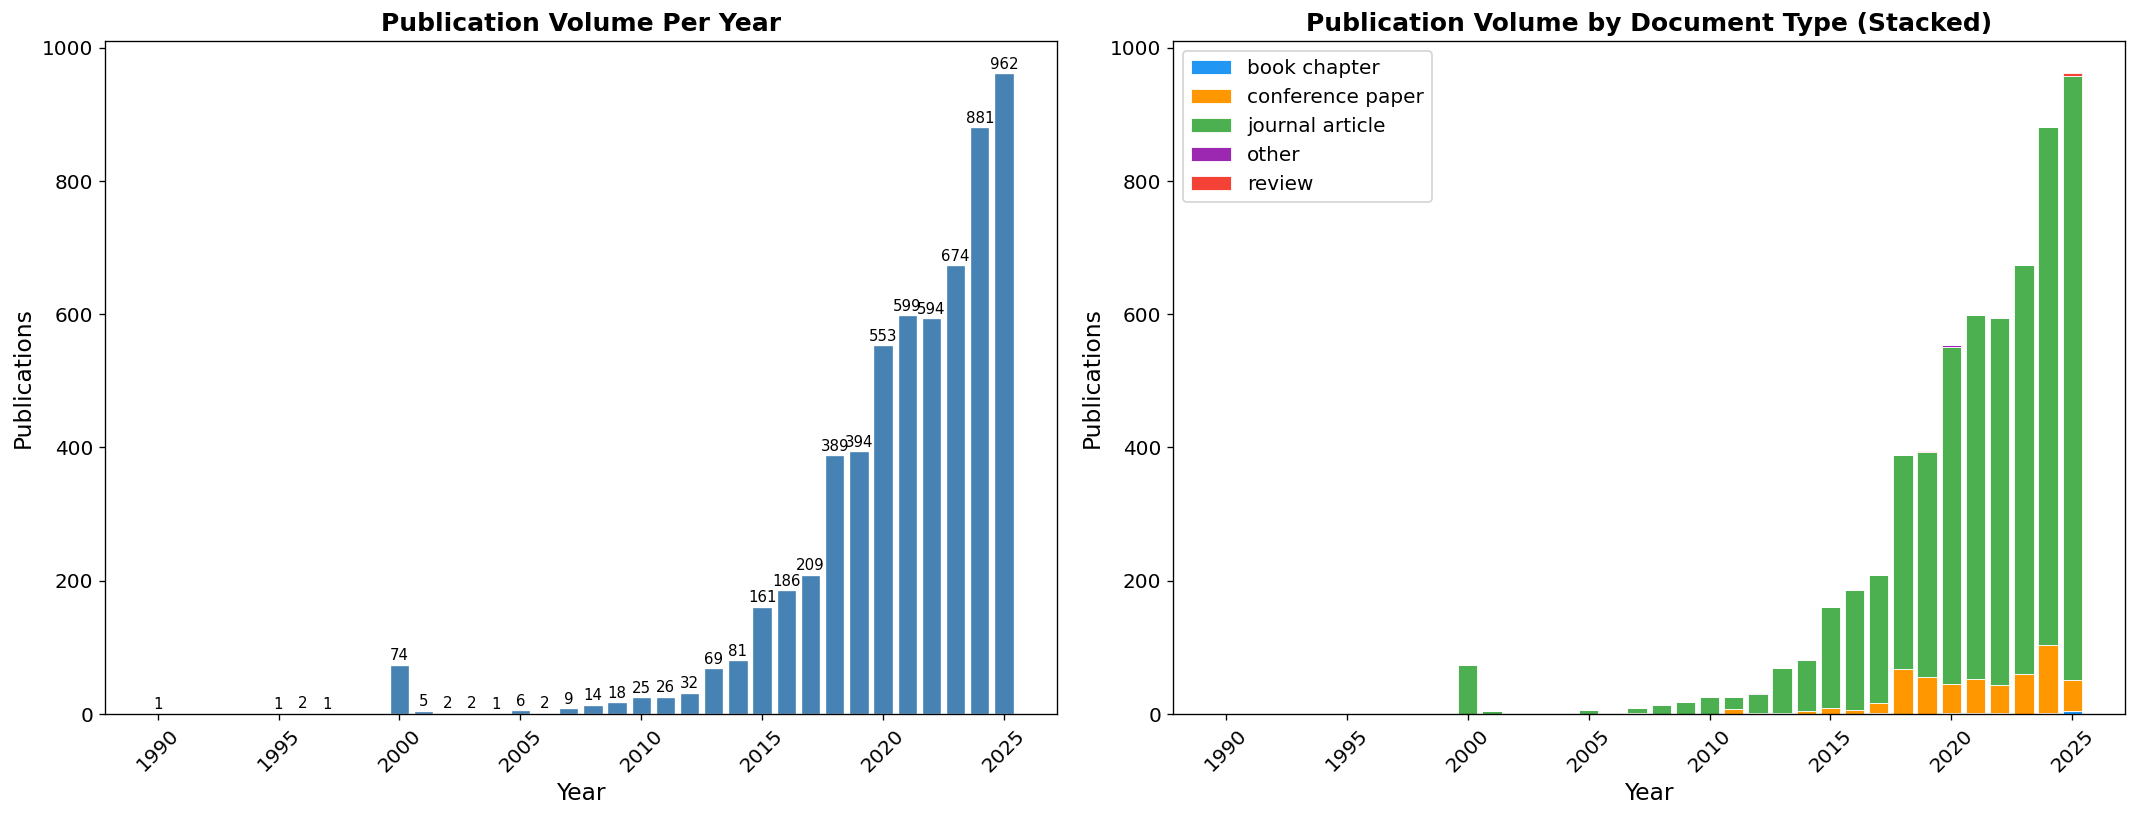

In [ ]:
paper_author_long = clean_papers_df.explode("author_id_list").rename(columns={"author_id_list": "author_id"})
paper_author_long = paper_author_long.dropna(subset=["author_id"])
year_counts = clean_papers_df["year"].value_counts().sort_index()
doc_type_year = clean_papers_df.groupby(["year", "document_type_clean"]).size().reset_index(name="count")
doc_type_pivot = doc_type_year.pivot(index="year", columns="document_type_clean", values="count").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
bars = axes[0].bar(year_counts.index, year_counts.values, color="steelblue", edgecolor="white", linewidth=0.8)
axes[0].set_title("Publication Volume Per Year", fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Publications")
axes[0].tick_params(axis="x", rotation=45)
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 2, str(int(h)), ha="center", va="bottom", fontsize=9)

palette = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0", "#F44336"]
bottom_vals = np.zeros(len(doc_type_pivot))
for idx, col in enumerate(doc_type_pivot.columns):
    axes[1].bar(doc_type_pivot.index, doc_type_pivot[col].values, bottom=bottom_vals, label=col,
                color=palette[idx % len(palette)], edgecolor="white", linewidth=0.5)
    bottom_vals += doc_type_pivot[col].values
axes[1].set_title("Publication Volume by Document Type (Stacked)", fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Publications")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(loc="upper left", framealpha=0.85)
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "eda_publication_volume.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "publication volume per year and document type stacked bar")
plt.show()

### Top Authors by Publication Count

top 10 authors by publication count:
   author_id                    display_name  publication_count
zDgqPOsAAAAJ                         Mustaji                237
z7RWDi0AAAAJ                     Tri Rijanto                231
LsydBAMAAAAJ         Puput Wanarti Rusimamto                216
ZhJ08JkAAAAJ         Bachtiar Syaiful Bachri                214
6RBIukkAAAAJ                   Yatim Riyanto                204
6MXDzBQAAAAJ                    Lilik Anifah                197
p1pK7E4AAAAJ             Subuh Isnur Haryudo                195
MZCJPuIAAAAJ                   Fajar Arianto                191
yObeL8gAAAAJ I Gusti Putu Asto Buditjahjanto                183
j8HRV1wAAAAJ               Bambang Suprianto                178


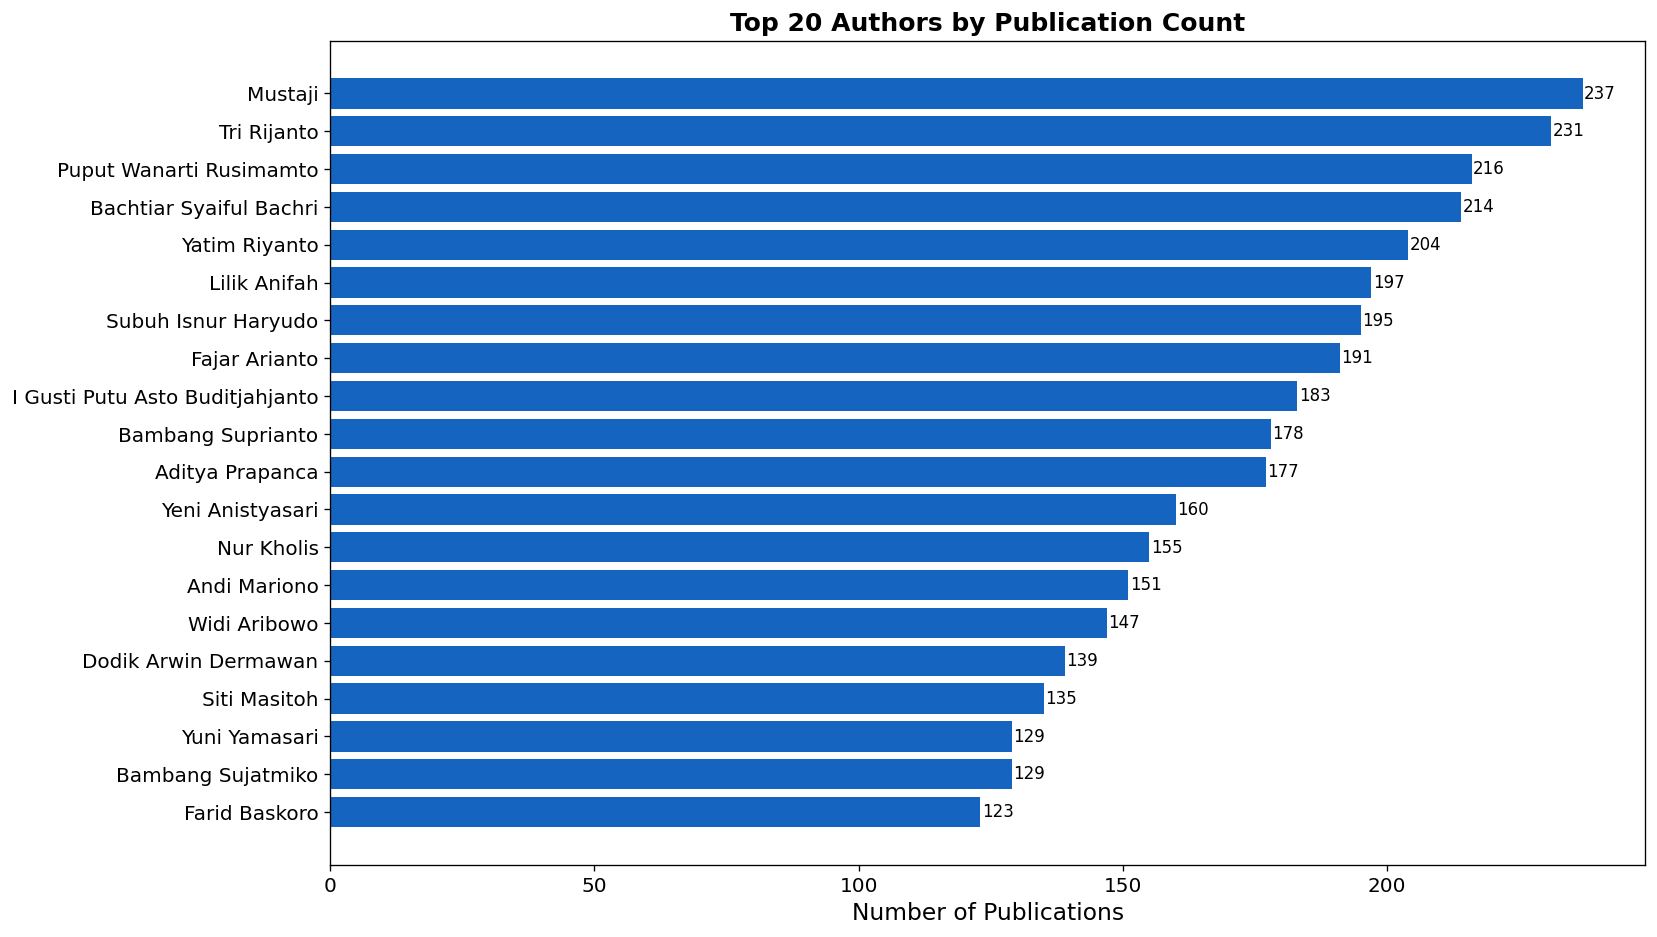

In [ ]:
author_pub_counts = (
    paper_author_long.groupby("author_id").size().rename("publication_count").reset_index()
    .merge(id_name_lookup_df, on="author_id", how="left")
    .sort_values("publication_count", ascending=False).reset_index(drop=True)
)
print("top 10 authors by publication count:")
print(author_pub_counts.head(10)[["author_id", "display_name", "publication_count"]].to_string(index=False))

top20 = author_pub_counts.head(20)
fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top20["display_name"].fillna(top20["author_id"]), top20["publication_count"], color="#1565C0")
ax.invert_yaxis()
ax.set_title("Top 20 Authors by Publication Count", fontweight="bold")
ax.set_xlabel("Number of Publications")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2, str(int(w)), va="center", fontsize=10)
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "eda_top20_authors.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "top 20 most prolific authors by total publication count")
plt.show()

### Missing Value Patterns and Keyword Cardinality

In [ ]:
missing_pattern = pd.DataFrame({
    "field": ["DOI", "Keywords", "Document Type", "Unesa Authors"],
    "missing_count": [
        clean_papers_df["DOI"].isnull().sum() if "DOI" in clean_papers_df.columns else 0,
        (clean_papers_df["Keywords"] == "").sum(),
        clean_papers_df["document_type_clean"].isnull().sum(),
        clean_papers_df["author_id_list"].apply(lambda x: len(x) == 0).sum(),
    ],
})
missing_pattern["missing_pct"] = (missing_pattern["missing_count"] / len(clean_papers_df) * 100).round(2)
print(missing_pattern.to_string(index=False))

has_keywords = clean_papers_df[clean_papers_df["Keywords"].str.strip() != ""]
keyword_cardinality = has_keywords["Keywords"].str.split(";").apply(len)
print(f"median keyword count per paper (among those with keywords): {keyword_cardinality.median()}")
print(f"single-author papers: {clean_papers_df['author_id_list'].apply(lambda x: len(x) == 1).sum()} ({100*clean_papers_df['author_id_list'].apply(lambda x: len(x) == 1).mean():.1f}%)")

        field  missing_count  missing_pct
          DOI           4922        82.40
     Keywords            182         3.05
Document Type              0         0.00
Unesa Authors              0         0.00
median keyword count per paper (among those with keywords): 5.0
single-author papers: 4361 (73.0%)


### Coauthorship Edge Volume Over Time

 year  n_edges  cumulative_edges  cumulative_ratio
 2000       30                30          0.009320
 2007        1                31          0.009630
 2009        1                32          0.009941
 2010        1                33          0.010252
 2011        1                34          0.010562
 2012        1                35          0.010873
 2013        4                39          0.012116
 2014        2                41          0.012737
 2015       34                75          0.023299
 2016       33               108          0.033551
 2017       52               160          0.049705
 2018      157               317          0.098478
 2019       75               392          0.121777
 2020      248               640          0.198820
 2021      405              1045          0.324635
 2022      402              1447          0.449518
 2023      399              1846          0.573470
 2024      567              2413          0.749612
 2025      806              321

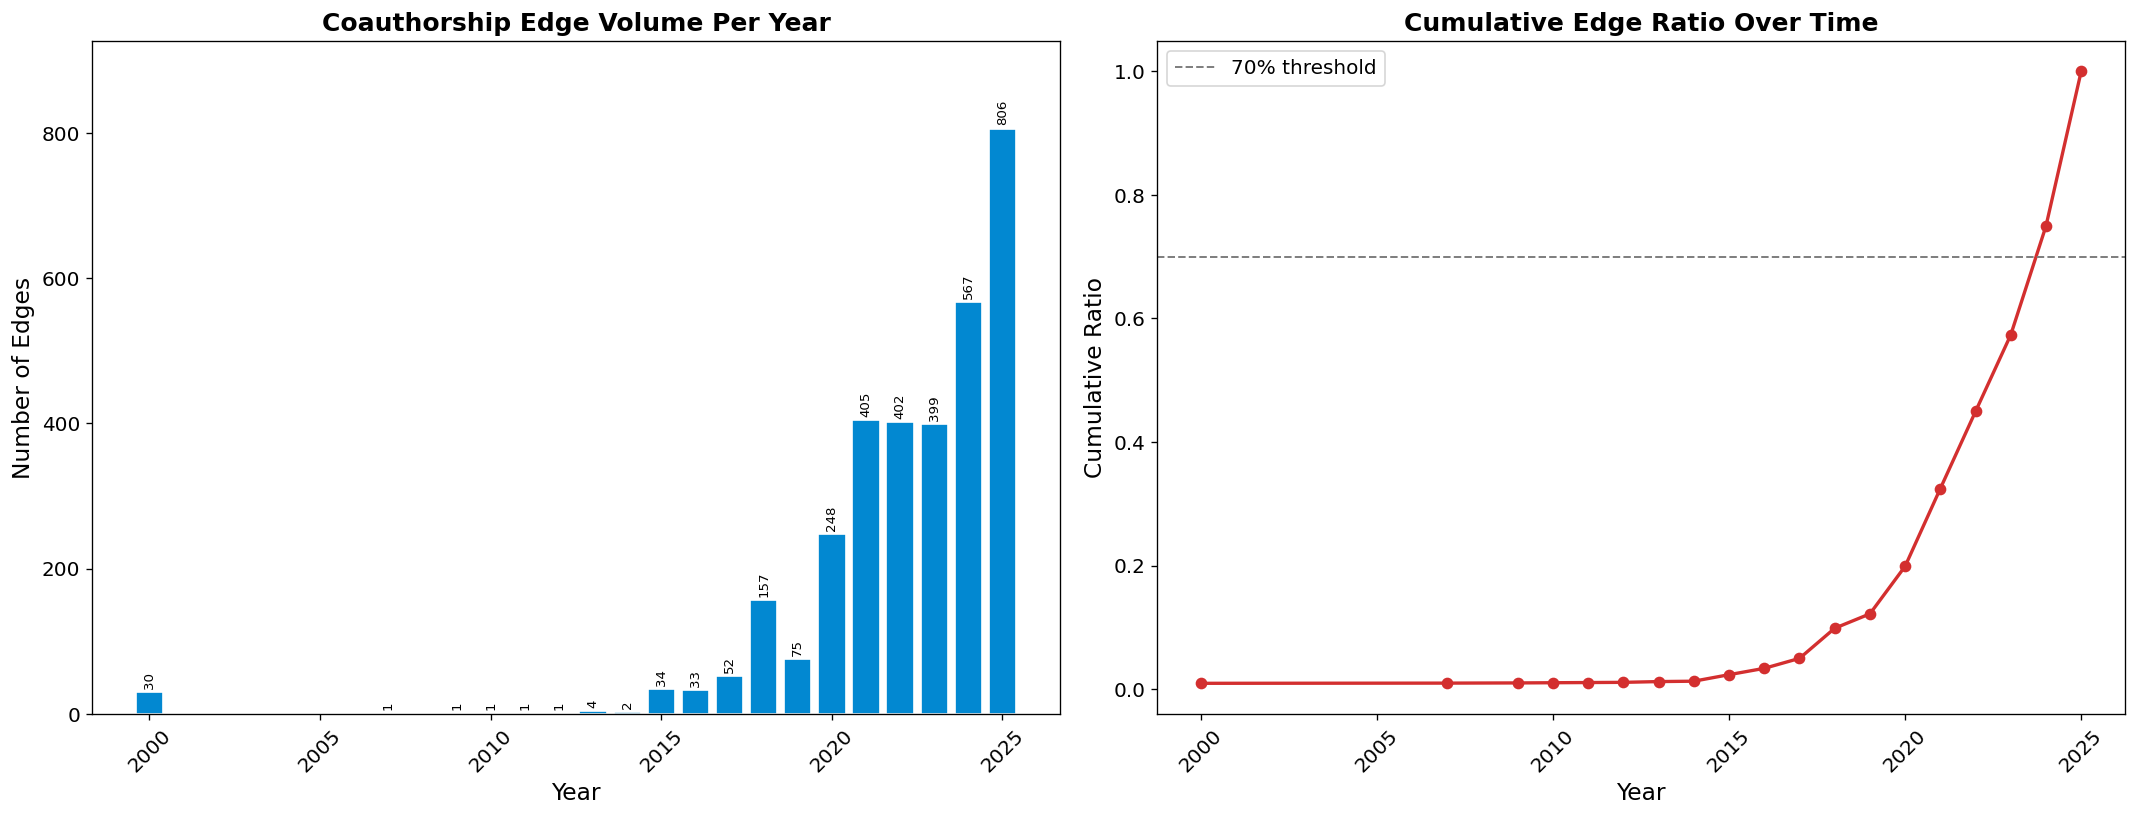

In [ ]:
temporal_edge_rows = []
for _, row in clean_papers_df.iterrows():
    ids = sorted(set(row["author_id_list"]))
    year = row["year"]
    for a, b in itertools.combinations(ids, 2):
        temporal_edge_rows.append({"author_a": a, "author_b": b, "year": year,
                                   "relation": row["document_type_clean"]})
all_coauthor_edges_df = pd.DataFrame(temporal_edge_rows)
edge_volume_table = all_coauthor_edges_df.groupby("year").size().rename("n_edges").reset_index()
edge_volume_table["cumulative_edges"] = edge_volume_table["n_edges"].cumsum()
edge_volume_table["cumulative_ratio"] = edge_volume_table["cumulative_edges"] / edge_volume_table["cumulative_edges"].iloc[-1]
print(edge_volume_table.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
bars_edge = axes[0].bar(edge_volume_table["year"], edge_volume_table["n_edges"], color="#0288D1", edgecolor="white")
axes[0].bar_label(bars_edge, padding=2, fontsize=8, rotation=90)
axes[0].set_title("Coauthorship Edge Volume Per Year", fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Edges")
axes[0].tick_params(axis="x", rotation=45)
axes[0].margins(y=0.15)

axes[1].plot(edge_volume_table["year"], edge_volume_table["cumulative_ratio"], marker="o", color="#D32F2F", linewidth=2)
axes[1].axhline(0.7, color="gray", linestyle="--", linewidth=1.2, label="70% threshold")
axes[1].set_title("Cumulative Edge Ratio Over Time", fontweight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Cumulative Ratio")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "eda_edge_volume_temporal.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "coauthorship edge volume per year and cumulative edge ratio")
plt.show()

### Coauthorship Graph Topology

nodes: 126, edges: 1125
giant component: 122, density: 0.142857, isolated: 4
author feature table shape: (126, 10)


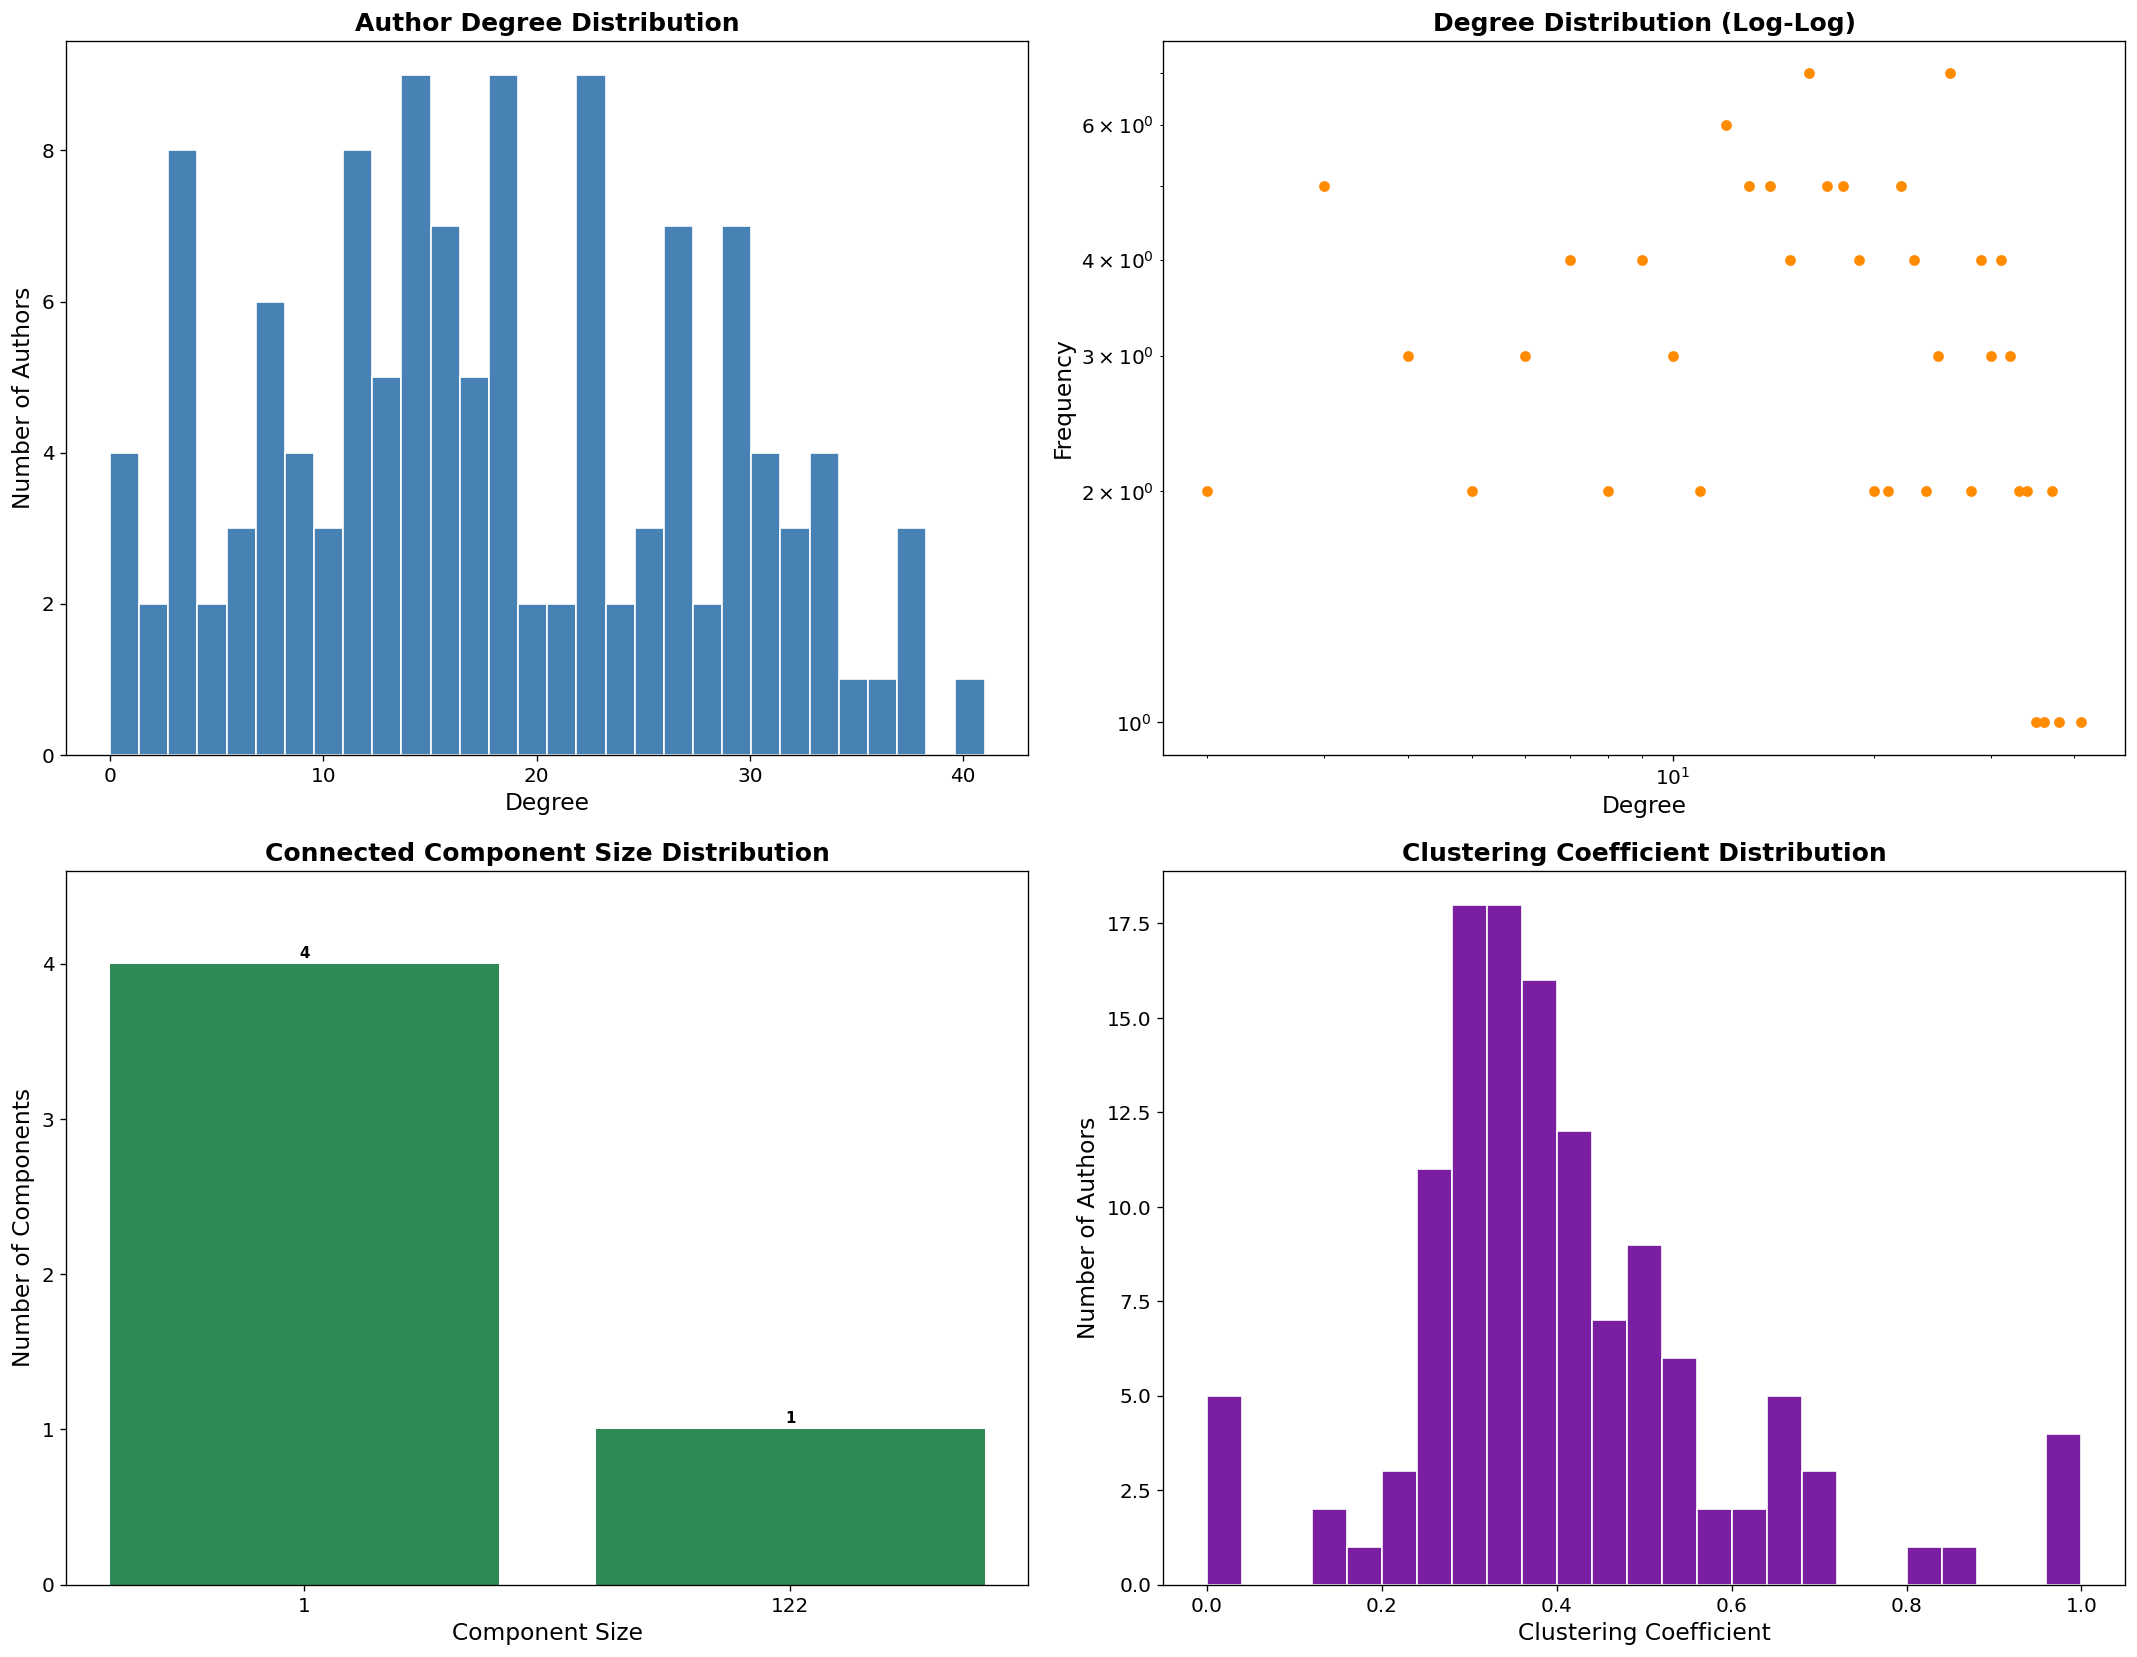

In [ ]:
coauthor_projection_graph = nx.Graph()
all_author_ids_all = sorted(set(a for ids in clean_papers_df["author_id_list"] for a in ids))
coauthor_projection_graph.add_nodes_from(all_author_ids_all)
for _, paper_row in clean_papers_df.iterrows():
    unique_authors = sorted(set(paper_row["author_id_list"]))
    if len(unique_authors) >= 2:
        for author_a, author_b in itertools.combinations(unique_authors, 2):
            if coauthor_projection_graph.has_edge(author_a, author_b):
                coauthor_projection_graph[author_a][author_b]["weight"] += 1
            else:
                coauthor_projection_graph.add_edge(author_a, author_b, weight=1)

degree_dict = dict(coauthor_projection_graph.degree())
clustering_dict = nx.clustering(coauthor_projection_graph)
core_number_dict = nx.core_number(coauthor_projection_graph)
connected_components_sizes = sorted(
    (len(c) for c in nx.connected_components(coauthor_projection_graph)), reverse=True
)
giant_component_size = connected_components_sizes[0]
graph_density = nx.density(coauthor_projection_graph)
isolated_node_count = sum(1 for s in connected_components_sizes if s == 1)
print(f"nodes: {coauthor_projection_graph.number_of_nodes()}, edges: {coauthor_projection_graph.number_of_edges()}")
print(f"giant component: {giant_component_size}, density: {graph_density:.6f}, isolated: {isolated_node_count}")

structural_feature_df = pd.DataFrame({
    "author_id": list(degree_dict.keys()),
    "degree": list(degree_dict.values()),
    "clustering_coefficient": [clustering_dict[a] for a in degree_dict],
    "core_number": [core_number_dict[a] for a in degree_dict],
})
author_activity_rows = []
for author_id, group in paper_author_long.groupby("author_id"):
    doc_type_counts = group["document_type_clean"].value_counts().to_dict()
    author_activity_rows.append({
        "author_id": author_id,
        "total_publications": group.shape[0],
        "n_journal_article": doc_type_counts.get("journal article", 0),
        "n_conference_paper": doc_type_counts.get("conference paper", 0),
        "first_active_year": int(group["year"].min()),
        "last_active_year": int(group["year"].max()),
    })
author_activity_df = pd.DataFrame(author_activity_rows)
author_feature_table = (
    author_activity_df.merge(structural_feature_df, on="author_id", how="left")
    .merge(id_name_lookup_df, on="author_id", how="left")
)
print("author feature table shape:", author_feature_table.shape)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
degree_values = np.array(list(degree_dict.values()))
axes[0, 0].hist(degree_values, bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Author Degree Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Degree")
axes[0, 0].set_ylabel("Number of Authors")
nonzero = degree_values[degree_values > 0]
dcounts = pd.Series(nonzero).value_counts().sort_index()
axes[0, 1].scatter(dcounts.index, dcounts.values, color="darkorange", s=30)
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Degree Distribution (Log-Log)", fontweight="bold")
axes[0, 1].set_xlabel("Degree")
axes[0, 1].set_ylabel("Frequency")
comp_size_counts = pd.Series(connected_components_sizes).value_counts().sort_index()
bars_comp = axes[1, 0].bar(comp_size_counts.index.astype(str), comp_size_counts.values, color="seagreen")
axes[1, 0].bar_label(bars_comp, padding=2, fontsize=9, fontweight="bold")
axes[1, 0].set_title("Connected Component Size Distribution", fontweight="bold")
axes[1, 0].set_xlabel("Component Size")
axes[1, 0].set_ylabel("Number of Components")
axes[1, 0].margins(y=0.15)
cc_vals = [clustering_dict[a] for a in degree_dict]
axes[1, 1].hist(cc_vals, bins=25, color="#7B1FA2", edgecolor="white")
axes[1, 1].set_title("Clustering Coefficient Distribution", fontweight="bold")
axes[1, 1].set_xlabel("Clustering Coefficient")
axes[1, 1].set_ylabel("Number of Authors")
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "eda_graph_topology.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "coauthorship graph topology: degree distribution, component sizes, clustering")
plt.show()

## Semantic Embedding and Latent Topic Discovery

Publications are encoded into dense vector representations using SentenceTransformers (all-MiniLM-L6-v2). Dimensionality reduction via UMAP and clustering via HDBSCAN with automatic parameter selection via DBCV validity index discover latent research topics, followed by class-based TF-IDF (c-TF-IDF) topic labeling.

In [ ]:
st_model = SentenceTransformer("all-MiniLM-L6-v2")
st_model.to(DEVICE)
print("encoding", len(clean_papers_df), "papers...")
paper_embeddings = st_model.encode(
    clean_papers_df["clean_text"].tolist(),
    show_progress_bar=True, batch_size=128,
    device=str(DEVICE), normalize_embeddings=True,
)
paper_embeddings = np.array(paper_embeddings, dtype=np.float32)
paper_idx_lookup = {pid: i for i, pid in enumerate(clean_papers_df["paper_id"])}
print("paper embedding matrix shape:", paper_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

encoding 5973 papers...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

paper embedding matrix shape: (5973, 384)


### Dimensionality Reduction with UMAP

Two UMAP projections are computed: a 5D version for HDBSCAN clustering (preserving density structure) and a 2D version for visualization. Both use cosine distance as the metric.

In [ ]:
historical_mask = (clean_papers_df["year"] <= TRAIN_CUTOFF_YEAR).values

umap_reducer_5d = umap.UMAP(n_components=5, n_neighbors=15, min_dist=0.0,
                             metric="cosine", random_state=RANDOM_SEED)
umap_reducer_5d.fit(paper_embeddings[historical_mask])
paper_embeddings_5d = umap_reducer_5d.transform(paper_embeddings)
print("5D UMAP shape:", paper_embeddings_5d.shape,
      f"(fitted on {historical_mask.sum()} historical papers <= {TRAIN_CUTOFF_YEAR})")

umap_reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                             metric="cosine", random_state=RANDOM_SEED)
paper_embeddings_2d = umap_reducer_2d.fit_transform(paper_embeddings)
print("2D UMAP shape:", paper_embeddings_2d.shape, "(descriptive/EDA only, full corpus)")

5D UMAP shape: (5973, 5) (fitted on 5011 historical papers <= 2024)
2D UMAP shape: (5973, 2) (descriptive/EDA only, full corpus)


### HDBSCAN Parameter Grid Search

Candidate combinations of min_cluster_size and min_samples are evaluated using the DBCV relative validity index as the objective criterion for parameter selection, ensuring data-driven rather than arbitrary choices.

mcs=35 ms= 5 -> clusters=46 noise=0.273 dbcv=0.2449
mcs=35 ms=10 -> clusters=41 noise=0.303 dbcv=0.2013
mcs=45 ms= 5 -> clusters=34 noise=0.319 dbcv=0.2368
mcs=45 ms=10 -> clusters=32 noise=0.302 dbcv=0.2489
mcs=55 ms= 5 -> clusters=30 noise=0.260 dbcv=0.2308
mcs=55 ms=10 -> clusters=27 noise=0.259 dbcv=0.3932
mcs=65 ms= 5 -> clusters=24 noise=0.301 dbcv=0.2671
mcs=65 ms=10 -> clusters=22 noise=0.288 dbcv=0.3414
mcs=75 ms= 5 -> clusters=18 noise=0.309 dbcv=0.1502
mcs=75 ms=10 -> clusters=17 noise=0.301 dbcv=0.2327
data-driven selected (fit on historical data only): mcs=55, ms=10, n_clusters=27.0, dbcv=0.3932


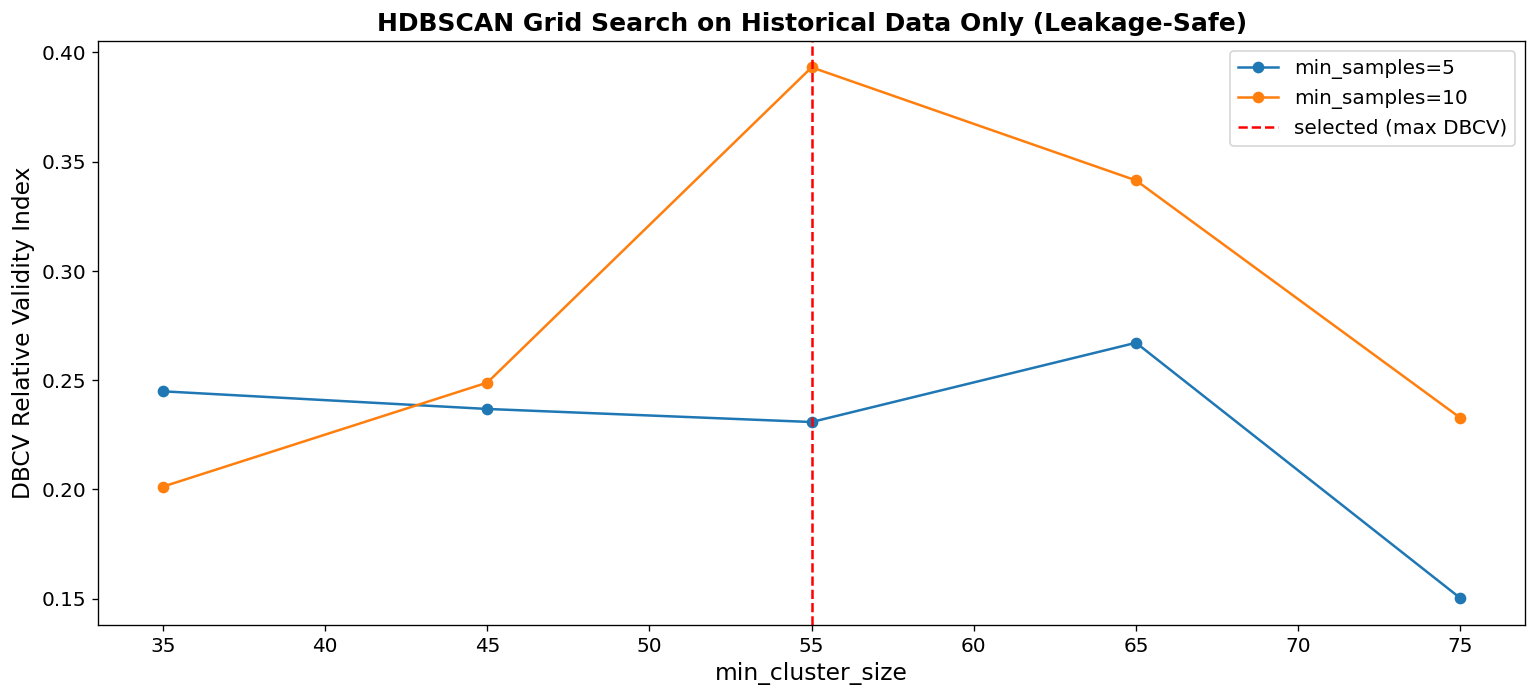

In [ ]:
min_cluster_size_candidates = [35, 45, 55, 65, 75]
min_samples_candidates = [5, 10]
grid_search_rows = []

fit_embeddings_5d = paper_embeddings_5d[historical_mask]

for min_cluster_size in min_cluster_size_candidates:
    for min_samples in min_samples_candidates:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples,
                                     gen_min_span_tree=True)
        candidate_labels = clusterer.fit_predict(fit_embeddings_5d)
        n_clusters = len(set(candidate_labels)) - (1 if -1 in candidate_labels else 0)
        noise_ratio = float(np.mean(candidate_labels == -1))
        validity_index = float(clusterer.relative_validity_) if n_clusters >= 2 else float("-inf")
        grid_search_rows.append({
            "min_cluster_size": min_cluster_size, "min_samples": min_samples,
            "n_clusters": n_clusters, "noise_ratio": noise_ratio,
            "dbcv_validity_index": validity_index
        })
        print(f"mcs={min_cluster_size:2d} ms={min_samples:2d} -> clusters={n_clusters:2d} "
              f"noise={noise_ratio:.3f} dbcv={validity_index:.4f}")
        del clusterer, candidate_labels

hdbscan_grid_df = pd.DataFrame(grid_search_rows)
candidate_pool = hdbscan_grid_df[(hdbscan_grid_df["n_clusters"] >= 15) & (hdbscan_grid_df["n_clusters"] <= 35)]
if candidate_pool.empty:
    candidate_pool = hdbscan_grid_df[hdbscan_grid_df["n_clusters"] >= 10]

selected_params = candidate_pool.sort_values("dbcv_validity_index", ascending=False).iloc[0]
selected_min_cluster_size = int(selected_params["min_cluster_size"])
selected_min_samples = int(selected_params["min_samples"])
print(f"data-driven selected (fit on historical data only): mcs={selected_min_cluster_size}, "
      f"ms={selected_min_samples}, n_clusters={selected_params['n_clusters']}, "
      f"dbcv={selected_params['dbcv_validity_index']:.4f}")

fig, ax = plt.subplots(figsize=(13, 6))
for ms in min_samples_candidates:
    subset = hdbscan_grid_df[hdbscan_grid_df["min_samples"] == ms]
    ax.plot(subset["min_cluster_size"], subset["dbcv_validity_index"], marker="o", label=f"min_samples={ms}")
ax.axvline(selected_min_cluster_size, color="red", linestyle="--", linewidth=1.5, label="selected (max DBCV)")
ax.set_title("HDBSCAN Grid Search on Historical Data Only (Leakage-Safe)", fontweight="bold")
ax.set_xlabel("min_cluster_size")
ax.set_ylabel("DBCV Relative Validity Index")
ax.legend()
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "hdbscan_grid_search.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "hdbscan grid search dbcv validity index curves (historical-only fit)")
plt.show()
plt.close(fig)
free_memory()

In [ ]:
final_clusterer = hdbscan.HDBSCAN(min_cluster_size=selected_min_cluster_size,
                                   min_samples=selected_min_samples,
                                   prediction_data=True)
fit_topic_labels = final_clusterer.fit_predict(fit_embeddings_5d)

topic_labels = np.full(len(clean_papers_df), -1, dtype=int)
topic_labels[historical_mask] = fit_topic_labels
if (~historical_mask).sum() > 0:
    future_labels, _ = hdbscan.approximate_predict(
        final_clusterer, paper_embeddings_5d[~historical_mask]
    )
    topic_labels[~historical_mask] = future_labels

noise_mask = topic_labels == -1
non_noise_topic_ids = sorted(set(topic_labels[topic_labels != -1]))
cluster_centroids = np.stack([paper_embeddings_5d[topic_labels == t].mean(axis=0) for t in non_noise_topic_ids])
noise_indices = np.where(noise_mask)[0]

if len(noise_indices) > 0:
    dist_to_centroids = np.linalg.norm(
        paper_embeddings_5d[noise_indices][:, None, :] - cluster_centroids[None, :, :], axis=2)
    nearest = dist_to_centroids.argmin(axis=1)
    reassigned_labels = topic_labels.copy()
    for pos, nidx in enumerate(noise_indices):
        reassigned_labels[nidx] = non_noise_topic_ids[nearest[pos]]
else:
    reassigned_labels = topic_labels.copy()

clean_papers_df["topic_id"] = reassigned_labels
n_topics = len(set(reassigned_labels))
print(f"final refined topics count: {n_topics}")
print(f"noise papers reassigned: {int(noise_mask.sum())} "
      f"({100*noise_mask.mean():.1f}% of {len(clean_papers_df)} papers)")
print(clean_papers_df["topic_id"].value_counts().sort_index())

final refined topics count: 27
noise papers reassigned: 1565 (26.2% of 5973 papers)
topic_id
0     117
1      89
2      94
3     122
4     166
5     118
6      92
7      73
8     279
9     406
10    100
11    141
12    140
13    435
14    190
15    380
16     98
17    330
18    328
19    579
20    294
21    218
22    373
23    119
24    277
25    218
26    197
Name: count, dtype: int64


### Automatic Topic Labeling with c-TF-IDF

Topic labels are generated automatically from the highest-scoring c-TF-IDF terms per cluster, without any manual naming, ensuring reproducibility and objectivity.

In [ ]:
def build_topic_document(rows):
    return " ".join(str(row["Title"]) + " " + str(row["Keywords"]) for _, row in rows.iterrows())

topic_ids_ordered = sorted(clean_papers_df["topic_id"].unique())
topic_documents = [build_topic_document(clean_papers_df[clean_papers_df["topic_id"] == t]) for t in topic_ids_ordered]
ctfidf_vectorizer = TfidfVectorizer(max_features=4000, stop_words="english", ngram_range=(1, 2), sublinear_tf=True)
ctfidf_matrix = ctfidf_vectorizer.fit_transform(topic_documents).toarray()
ctfidf_terms = np.array(ctfidf_vectorizer.get_feature_names_out())

topic_label_rows = []
for i, topic_id in enumerate(topic_ids_ordered):
    top_indices = ctfidf_matrix[i].argsort()[::-1][:10]
    candidate_terms = [ctfidf_terms[idx] for idx in top_indices]

    clean_terms = []
    for term in candidate_terms:
        if not any(term in existing or existing in term for existing in clean_terms):
            clean_terms.append(term)
        if len(clean_terms) >= 3:
            break

    topic_label_rows.append({
        "topic_id": topic_id,
        "topic_label": " / ".join(clean_terms),
        "n_papers": int((clean_papers_df["topic_id"] == topic_id).sum()),
    })

topic_label_df = pd.DataFrame(topic_label_rows).sort_values("n_papers", ascending=False)
print(topic_label_df.to_string(index=False))
p = os.path.join(OUTPUT_ROOT, "topic_labels.csv")
topic_label_df.to_csv(p, index=False)
register_artifact(p, "auto-generated topic labels via c-TF-IDF with paper counts")

 topic_id                                                                 topic_label  n_papers
       19                     ethnography / analysis thematic / sustainable practices       579
       13                                      things iot / wireless sensor / iot iot       435
        9                            metaheuristic / swarm optimization / logic logic       406
       15                                              vector / naive / random forest       380
       22                    computer assisted / model project / assisted instruction       373
       17               metacognitive / cooperative learning / collaborative learning       330
       18                                    user centered / ux / usability usability       328
       20               leadership teacher / education teacher / teacher competencies       294
        8                understanding video / augmented reality / video pembelajaran       279
       24                educational lea

In [ ]:
paper_topic_long = clean_papers_df[["paper_id", "author_id_list", "topic_id"]].explode("author_id_list")
paper_topic_long = paper_topic_long.rename(columns={"author_id_list": "author_id"}).dropna(subset=["author_id"])
topic_profile_rows = []
for author_id, group in paper_topic_long.groupby("author_id"):
    topic_counts = group["topic_id"].value_counts().to_dict()
    row = {"author_id": author_id}
    for t in topic_ids_ordered:
        row[f"topic_{t}_count"] = topic_counts.get(t, 0)
    topic_profile_rows.append(row)
topic_profile_matrix = pd.DataFrame(topic_profile_rows)
print("topic profile matrix shape:", topic_profile_matrix.shape)

topic profile matrix shape: (126, 28)


### Research Topic Space Visualization

The 2D UMAP scatter plot reveals the latent cluster structure of the research landscape. Each point is a paper; color encodes topic cluster membership. Static and interactive versions are both provided.

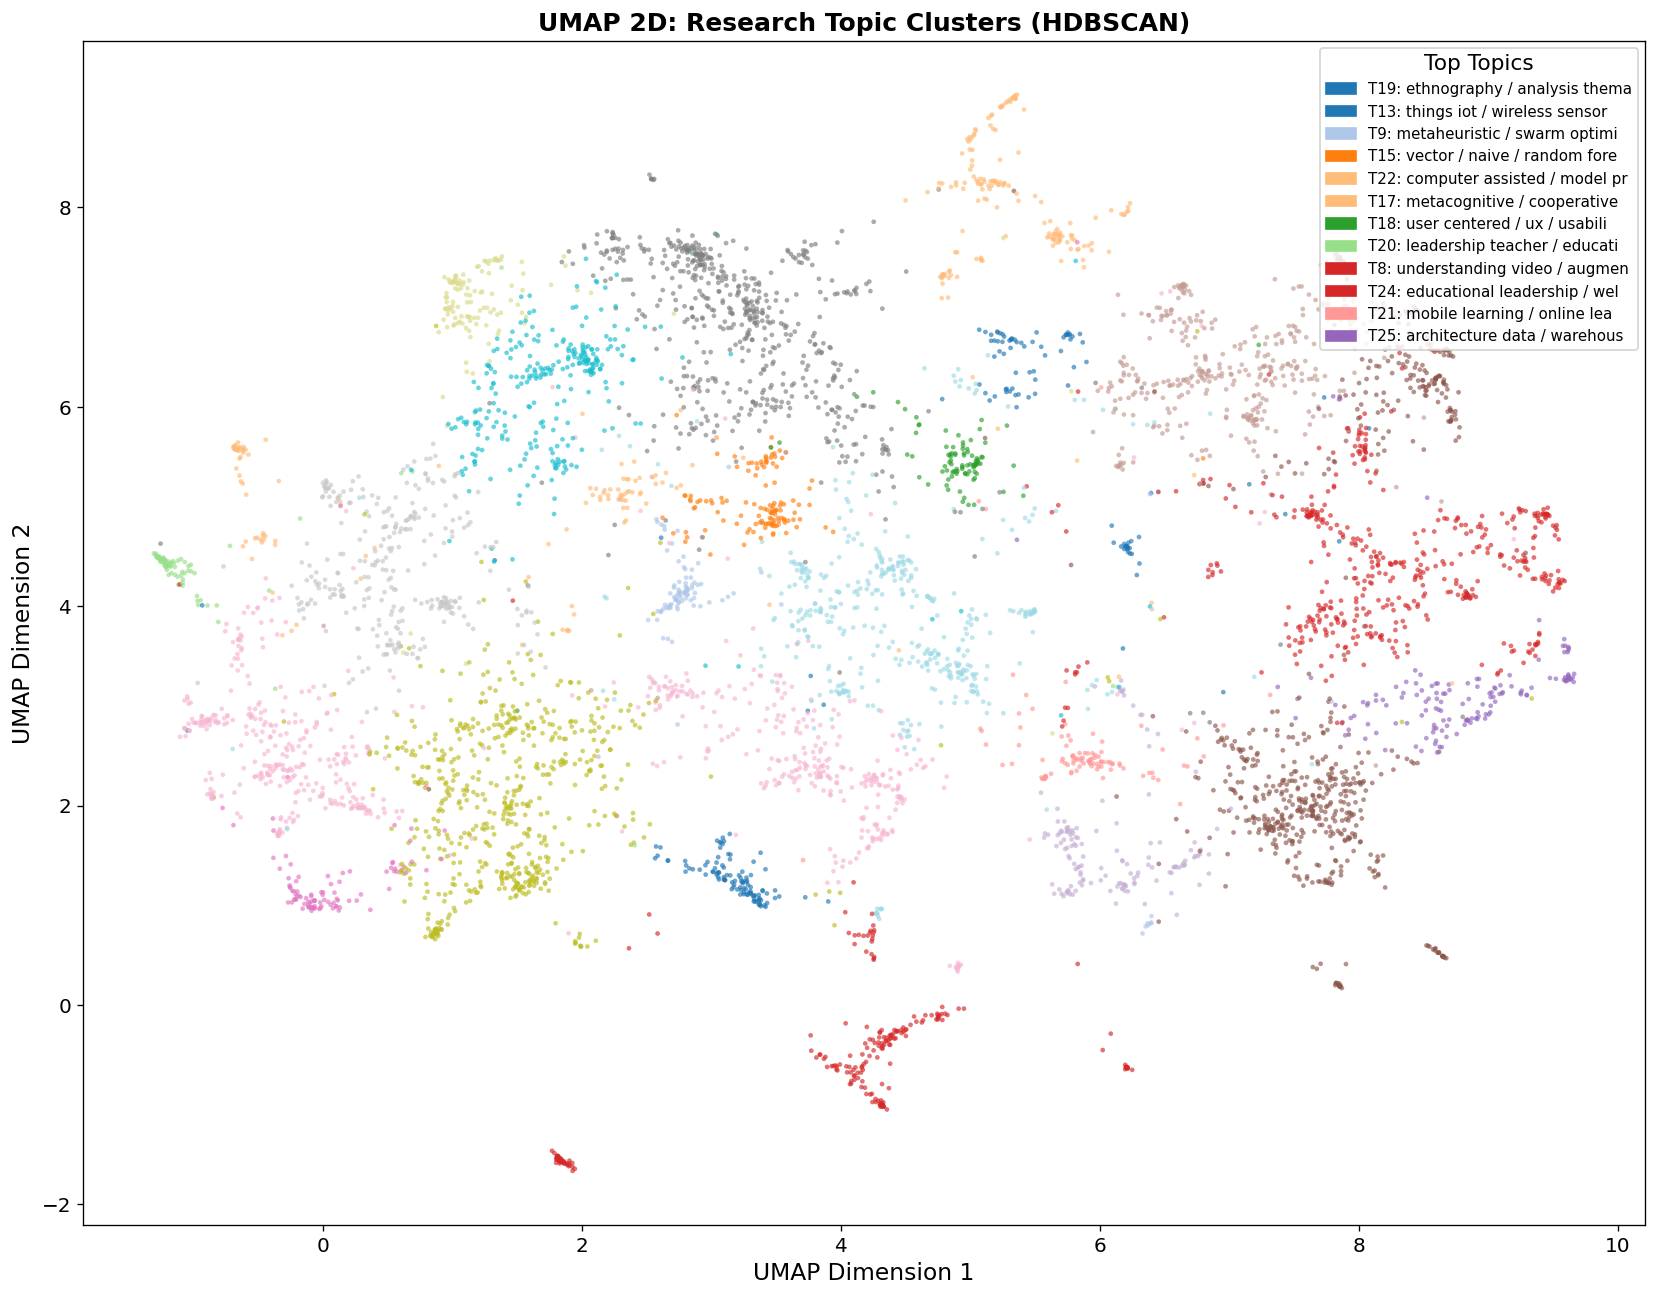

In [ ]:
cmap = plt.cm.get_cmap("tab20", n_topics)
fig, ax = plt.subplots(figsize=(14, 11))
scatter = ax.scatter(paper_embeddings_2d[:, 0], paper_embeddings_2d[:, 1],
    c=clean_papers_df["topic_id"], cmap="tab20", s=8, alpha=0.65, linewidths=0)
legend_handles = [mpatches.Patch(color=cmap(i % n_topics), label=f"T{tid}: {row['topic_label'][:28]}")
    for i, (tid, row) in enumerate(topic_label_df.head(12).set_index("topic_id").iterrows())]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.85, title="Top Topics")
ax.set_title("UMAP 2D: Research Topic Clusters (HDBSCAN)", fontweight="bold")
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "topic_umap_scatter.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "2D UMAP scatter plot of paper topic clusters from HDBSCAN")
plt.show()

In [ ]:
plot_df = clean_papers_df.copy()
plot_df["umap_x"] = paper_embeddings_2d[:, 0]
plot_df["umap_y"] = paper_embeddings_2d[:, 1]
plot_df["topic_label_str"] = plot_df["topic_id"].map(dict(zip(topic_label_df["topic_id"], topic_label_df["topic_label"]))).fillna("unknown")
plot_df["topic_str"] = plot_df["topic_id"].astype(str)
fig_interactive = px.scatter(plot_df, x="umap_x", y="umap_y", color="topic_str",
    hover_data=["Title", "year", "topic_label_str"],
    title="Interactive UMAP Topic Cluster Visualization",
    labels={"umap_x": "UMAP Dim 1", "umap_y": "UMAP Dim 2", "topic_str": "Topic"},
    opacity=0.7, width=1100, height=800)
fig_interactive.update_traces(marker=dict(size=5))
p = os.path.join(OUTPUT_VIZ, "topic_umap_interactive.html")
fig_interactive.write_html(p)
register_artifact(p, "interactive UMAP 2D scatter plot of paper topic clusters")
fig_interactive.show()

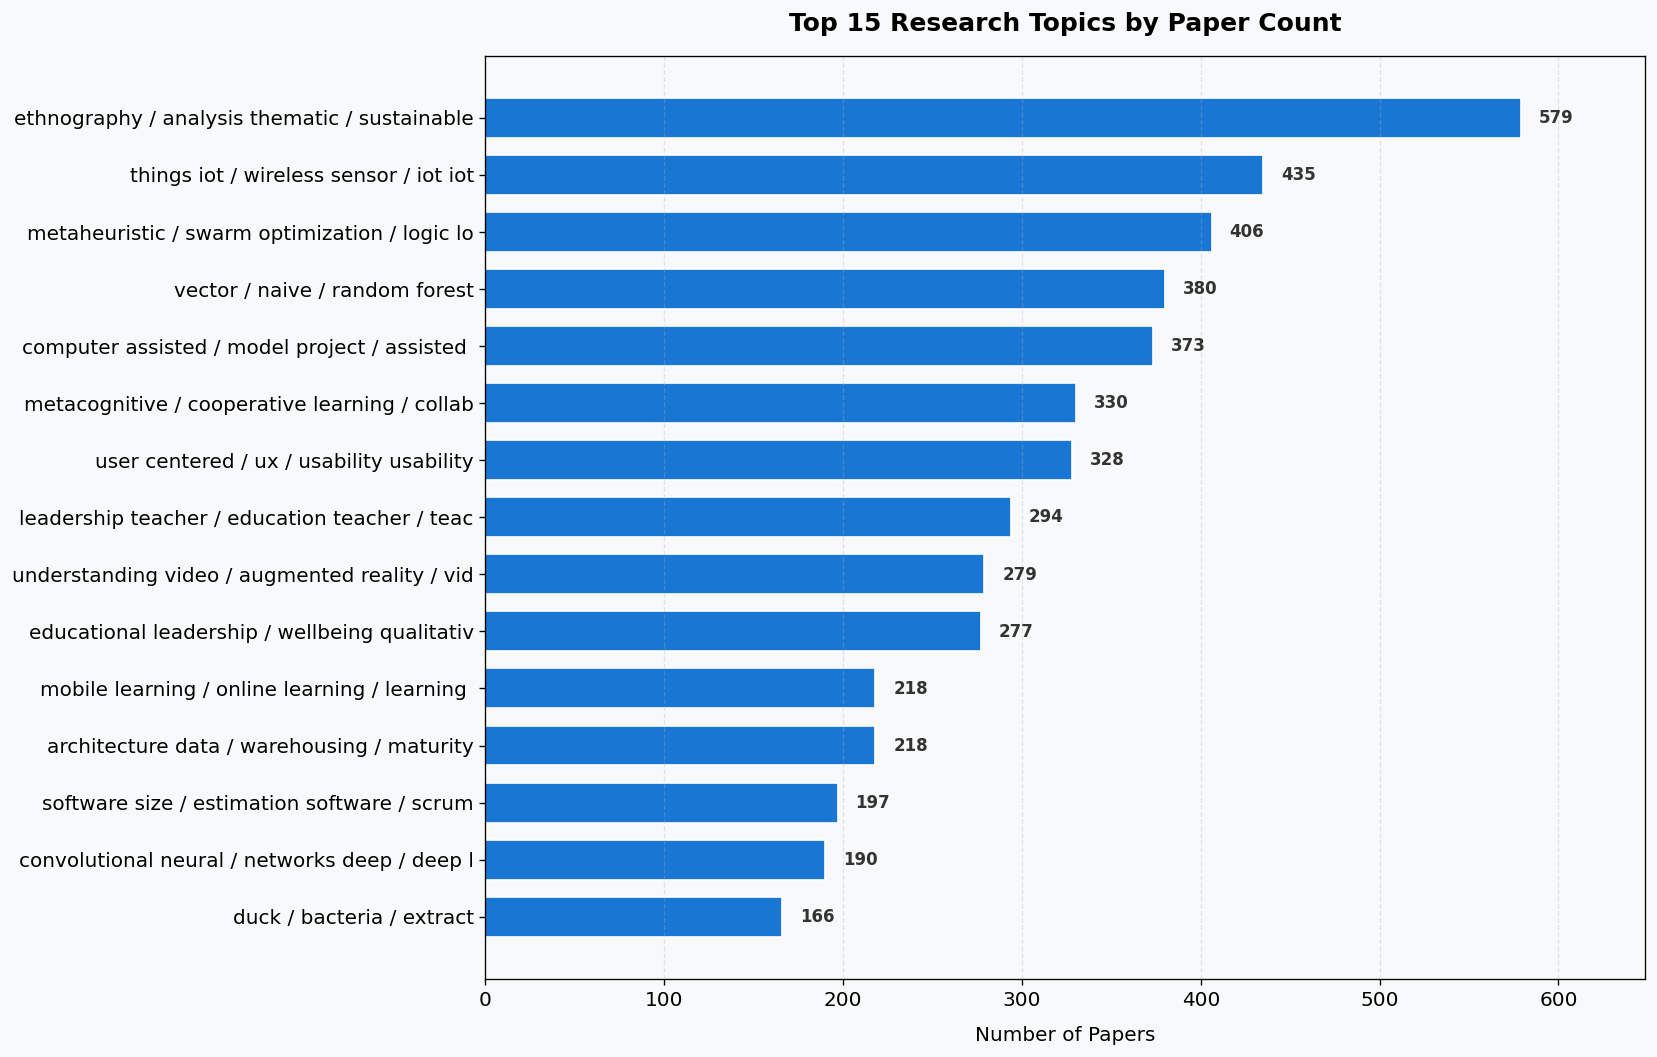

In [ ]:
top_topics = topic_label_df.head(15).sort_values("n_papers", ascending=True)

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bars = ax.barh(top_topics["topic_label"].str[:45], top_topics["n_papers"], color="#1976D2", edgecolor="white", height=0.7)
ax.set_title("Top 15 Research Topics by Paper Count", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Number of Papers", fontsize=12, labelpad=10)
ax.grid(axis="x", alpha=0.3, linestyle="--")

for bar in bars:
    w = bar.get_width()
    ax.text(w + 10, bar.get_y() + bar.get_height() / 2, f"{int(w)}", ha="left", va="center", fontsize=10, fontweight="bold", color="#333333")

ax.set_xlim(0, max(top_topics["n_papers"]) * 1.12)
plt.tight_layout()

p = os.path.join(OUTPUT_VIZ, "topic_size_bar.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "top 15 research topics ranked by number of papers")
plt.show()

In [ ]:
plt.close(fig)
del st_model, umap_reducer_5d, umap_reducer_2d, final_clusterer
del fit_embeddings_5d, ctfidf_matrix, hdbscan_grid_df, grid_search_rows
del raw_df, clean_df
free_memory()

## Tri-Feature Fusion Engine

Author node representations combine three complementary feature sources to form a 450D vector per author per temporal window.

In [ ]:
paper_idx_lookup = dict(zip(clean_papers_df["paper_id"], range(len(clean_papers_df))))

def compute_author_content_vectors(df_subset, paper_emb_matrix, idx_lookup):
    authors_local = sorted(set(a for ids in df_subset["author_id_list"] for a in ids))
    a_to_i = {a: i for i, a in enumerate(authors_local)}
    n = len(authors_local)
    dim = paper_emb_matrix.shape[1]
    vectors = np.zeros((n, dim), dtype=np.float32)
    weights = np.zeros(n, dtype=np.float32)
    for idx, row in df_subset.iterrows():
        gidx = idx_lookup.get(row["paper_id"])
        if gidx is None:
            continue
        emb = paper_emb_matrix[gidx]
        w = 1.0
        for a in row["author_id_list"]:
            if a in a_to_i:
                vectors[a_to_i[a]] += emb * w
                weights[a_to_i[a]] += w
    for i in range(n):
        if weights[i] > 0:
            vectors[i] /= weights[i]
    return dict(zip(authors_local, vectors))

try:
    from node2vec import Node2Vec
    NODE2VEC_AVAILABLE = True
except ImportError:
    NODE2VEC_AVAILABLE = False

def compute_node2vec_embeddings(nx_graph, author_ids, dim=64, seed=42):
    if NODE2VEC_AVAILABLE and nx_graph.number_of_edges() > 0:
        n2v = Node2Vec(nx_graph, dimensions=dim, walk_length=20, num_walks=10, workers=1, seed=seed, quiet=True)
        m = n2v.fit(window=5, min_count=1, batch_words=4)
        embs = {}
        for a in author_ids:
            try:
                embs[a] = m.wv[a]
            except KeyError:
                embs[a] = np.zeros(dim, dtype=np.float32)
        return embs
    return {a: np.zeros(dim, dtype=np.float32) for a in author_ids}

def compute_tstpr(nx_graph, author_ids, topic_membership, decay=0.85):
    if nx_graph.number_of_edges() == 0:
        return {a: np.array([0.0, 0.0], dtype=np.float32) for a in author_ids}
    pr = nx.pagerank(nx_graph, weight="weight", alpha=decay, max_iter=100, tol=1e-6)
    max_pr = max(pr.values()) if pr else 1.0
    topic_counts = {a: len(topic_membership.get(a, set())) for a in author_ids}
    max_tc = max(topic_counts.values()) if topic_counts else 1.0
    result = {}
    for a in author_ids:
        pr_val = pr.get(a, 0.0) / (max_pr + 1e-10)
        tc_val = topic_counts.get(a, 0) / (max_tc + 1e-10)
        result[a] = np.array([pr_val, tc_val], dtype=np.float32)
    return result

## Heterogeneous Temporal Graph Assembly

The publication timeline is partitioned into sliding 3 year training windows with the subsequent year as the prediction target. Each window builds a real heterogeneous graph with three node types, Author, Paper, and Topic, connected through three relations, coauthored_with, authored, and has_topic. Author nodes additionally carry the Tri Feature Fusion vector while Paper and Topic nodes carry semantic content embeddings. Only the refined Author representations are kept for temporal stacking and link prediction.

In [ ]:
all_author_ids_sorted = sorted(set(a for ids in clean_papers_df["author_id_list"] for a in ids))
author_id_to_index = {a: i for i, a in enumerate(all_author_ids_sorted)}
N_AUTHORS = len(all_author_ids_sorted)
print(f"total unique authors: {N_AUTHORS}")

TOPIC_ID_LIST = topic_ids_ordered
TOPIC_COUNT = len(TOPIC_ID_LIST)
topic_id_to_local = {tid: i for i, tid in enumerate(TOPIC_ID_LIST)}
NUM_HETERO_RELATIONS = 3

paper_topic_long = clean_papers_df[["paper_id", "author_id_list", "topic_id", "year"]].explode("author_id_list")
paper_topic_long = paper_topic_long.rename(columns={"author_id_list": "author_id"}).dropna(subset=["author_id"])

def get_author_topic_membership_upto(year_cutoff):
    df_hist = paper_topic_long[paper_topic_long["year"] <= year_cutoff]
    membership = {}
    for author_id, group in df_hist.groupby("author_id"):
        membership[author_id] = set(group["topic_id"].astype(str))
    for a in all_author_ids_sorted:
        membership.setdefault(a, set())
    return membership

def compute_global_topic_fallback_embeddings():
    fallback = {}
    for tid in TOPIC_ID_LIST:
        rows = clean_papers_df[clean_papers_df["topic_id"] == tid]
        gidxs = [paper_idx_lookup[pid] for pid in rows["paper_id"] if pid in paper_idx_lookup]
        fallback[tid] = paper_embeddings[gidxs].mean(axis=0) if gidxs else np.zeros(384, dtype=np.float32)
    return fallback

GLOBAL_TOPIC_FALLBACK = compute_global_topic_fallback_embeddings()

def build_hetero_snapshot(df_train, author_features_np, coauthor_pairs):
    window_paper_ids = df_train["paper_id"].tolist()
    n_papers = len(window_paper_ids)
    paper_local_index = {pid: N_AUTHORS + TOPIC_COUNT + j for j, pid in enumerate(window_paper_ids)}

    topic_paper_embs = {tid: [] for tid in TOPIC_ID_LIST}
    for _, row in df_train.iterrows():
        gidx = paper_idx_lookup.get(row["paper_id"])
        if gidx is not None and row["topic_id"] in topic_paper_embs:
            topic_paper_embs[row["topic_id"]].append(paper_embeddings[gidx])

    FEATURE_DIM = author_features_np.shape[1]

    topic_feat = np.zeros((TOPIC_COUNT, FEATURE_DIM), dtype=np.float32)
    for tid, local_i in topic_id_to_local.items():
        embs = topic_paper_embs[tid]
        topic_feat[local_i, :384] = np.mean(embs, axis=0) if embs else GLOBAL_TOPIC_FALLBACK[tid]

    paper_feat = np.zeros((n_papers, FEATURE_DIM), dtype=np.float32)
    for pid, local_idx in paper_local_index.items():
        gidx = paper_idx_lookup.get(pid)
        if gidx is not None:
            paper_feat[local_idx - N_AUTHORS - TOPIC_COUNT, :384] = paper_embeddings[gidx]

    x_hetero = np.concatenate([author_features_np, topic_feat, paper_feat], axis=0)

    coauthor_src, coauthor_dst = [], []
    for a, b in coauthor_pairs:
        i, j = author_id_to_index[a], author_id_to_index[b]
        coauthor_src += [i, j]
        coauthor_dst += [j, i]

    authored_src, authored_dst = [], []
    topic_src, topic_dst = [], []
    for _, row in df_train.iterrows():
        pid = row["paper_id"]
        p_idx = paper_local_index.get(pid)
        if p_idx is None:
            continue
        for a in set(row["author_id_list"]):
            if a in author_id_to_index:
                a_idx = author_id_to_index[a]
                authored_src += [a_idx, p_idx]
                authored_dst += [p_idx, a_idx]
        t_local = topic_id_to_local.get(row["topic_id"])
        if t_local is not None:
            t_idx = N_AUTHORS + t_local
            topic_src += [p_idx, t_idx]
            topic_dst += [t_idx, p_idx]

    edge_index_hetero = torch.tensor([
        coauthor_src + authored_src + topic_src,
        coauthor_dst + authored_dst + topic_dst,
    ], dtype=torch.long)
    edge_type_hetero = torch.tensor(
        [0] * len(coauthor_src) + [1] * len(authored_src) + [2] * len(topic_src), dtype=torch.long
    )
    total_nodes = N_AUTHORS + TOPIC_COUNT + n_papers
    return torch.tensor(x_hetero, dtype=torch.float32), edge_index_hetero, edge_type_hetero, total_nodes

SLIDING_WINDOWS = [
    {"name": "w1", "train_years": (2018, 2020), "target_year": 2021},
    {"name": "w2", "train_years": (2019, 2021), "target_year": 2022},
    {"name": "w3", "train_years": (2020, 2022), "target_year": 2023},
    {"name": "w4", "train_years": (2021, 2023), "target_year": 2024},
    {"name": "w5", "train_years": (2022, 2024), "target_year": 2025},
]

def build_window_data(window_config, node2vec_dim=64):
    min_y, max_y = window_config["train_years"]
    target_y = window_config["target_year"]
    df_train = clean_papers_df[(clean_papers_df["year"] >= min_y) & (clean_papers_df["year"] <= max_y)]
    df_target = clean_papers_df[clean_papers_df["year"] == target_y]

    nx_coauthor = nx.Graph()
    nx_coauthor.add_nodes_from(all_author_ids_sorted)

    for _, row in df_train.iterrows():
        p_year = row["year"]
        recency_weight = math.exp(0.5 * (p_year - max_y))
        ids = sorted(set(row["author_id_list"]))
        if len(ids) >= 2:
            for a, b in itertools.combinations(ids, 2):
                if nx_coauthor.has_edge(a, b):
                    nx_coauthor[a][b]["weight"] += recency_weight
                else:
                    nx_coauthor.add_edge(a, b, weight=recency_weight)

    content_vecs = compute_author_content_vectors(df_train, paper_embeddings, paper_idx_lookup)
    n2v_vecs = compute_node2vec_embeddings(nx_coauthor, all_author_ids_sorted, dim=node2vec_dim)

    author_topic_membership_window = get_author_topic_membership_upto(max_y)
    tstpr_vecs = compute_tstpr(nx_coauthor, all_author_ids_sorted, author_topic_membership_window)

    deg = dict(nx_coauthor.degree(weight="weight"))
    clustering = nx.clustering(nx_coauthor, weight="weight") if nx_coauthor.number_of_edges() > 0 else {a: 0.0 for a in all_author_ids_sorted}
    max_deg = max(deg.values()) if deg else 1.0

    author_features = np.zeros((N_AUTHORS, 384 + node2vec_dim + 4), dtype=np.float32)
    for i, a in enumerate(all_author_ids_sorted):
        cv = content_vecs.get(a, np.zeros(384))
        nv = n2v_vecs.get(a, np.zeros(node2vec_dim))
        pv = tstpr_vecs.get(a, np.zeros(2))
        deg_feat = np.array([deg.get(a, 0) / (max_deg + 1e-5), clustering.get(a, 0.0)], dtype=np.float32)
        author_features[i] = np.concatenate([cv, nv, pv, deg_feat])

    train_pair_set_w = set()
    for _, row in df_train.iterrows():
        ids = sorted(set(row["author_id_list"]))
        for a, b in itertools.combinations(ids, 2):
            train_pair_set_w.add((a, b))
    target_pair_dict = {}
    for _, row in df_target.iterrows():
        ids = sorted(set(row["author_id_list"]))
        for a, b in itertools.combinations(ids, 2):
            target_pair_dict[(a, b)] = target_pair_dict.get((a, b), 0) + 1
    coauthor_edges_src = [author_id_to_index[a] for a, b in train_pair_set_w]
    coauthor_edges_dst = [author_id_to_index[b] for a, b in train_pair_set_w]
    edge_weights = [nx_coauthor[a][b]["weight"] for a, b in train_pair_set_w]
    self_loops = list(range(N_AUTHORS))
    edge_index = torch.tensor([
        coauthor_edges_src + coauthor_edges_dst + self_loops,
        coauthor_edges_dst + coauthor_edges_src + self_loops,
    ], dtype=torch.long)
    edge_attr = torch.tensor(edge_weights + edge_weights + [1.0] * N_AUTHORS, dtype=torch.float32).unsqueeze(-1)

    x_hetero, edge_index_hetero, edge_type_hetero, total_nodes = build_hetero_snapshot(df_train, author_features, train_pair_set_w)

    return {"name": window_config["name"], "train_years": window_config["train_years"],
            "target_year": target_y, "author_features": torch.tensor(author_features, dtype=torch.float32),
            "edge_index": edge_index, "edge_attr": edge_attr, "train_pair_set": train_pair_set_w,
            "target_pair_dict": target_pair_dict, "nx_coauthor": nx_coauthor,
            "x_hetero": x_hetero, "edge_index_hetero": edge_index_hetero,
            "edge_type_hetero": edge_type_hetero, "total_hetero_nodes": total_nodes}

print("building temporal windows (leakage safe TSTPR, heterogeneous graph)...")
window_data_list = []
window_summary_rows = []
for i, wc in enumerate(SLIDING_WINDOWS):
    wd = build_window_data(wc)
    window_data_list.append(wd)
    n_active_authors = sum(1 for _, d in wd["nx_coauthor"].degree() if d > 0)
    n_train_edges = len(wd["train_pair_set"])
    n_target_pairs = len(wd["target_pair_dict"])
    n_new_target_pairs = sum(1 for pr in wd["target_pair_dict"] if pr not in wd["train_pair_set"])
    n_renewed_target_pairs = n_target_pairs - n_new_target_pairs
    max_possible_edges = N_AUTHORS * (N_AUTHORS - 1) / 2
    density = n_train_edges / max_possible_edges if max_possible_edges > 0 else 0.0
    role = "Held Out Validation and Test Window" if i == len(SLIDING_WINDOWS) - 1 else "In Sample Training Target Window"
    window_summary_rows.append({
        "window": wc["name"],
        "train_years": f"{wc['train_years'][0]} to {wc['train_years'][1]}",
        "target_year": wc["target_year"],
        "active_authors": n_active_authors,
        "train_coauthor_edges": n_train_edges,
        "graph_density": round(density, 5),
        "target_pairs_total": n_target_pairs,
        "target_pairs_new": n_new_target_pairs,
        "target_pairs_renewed": n_renewed_target_pairs,
        "hetero_nodes": wd["total_hetero_nodes"],
        "role_in_pipeline": role,
    })
    print(f"  {wc['name']} [{wc['train_years'][0]} to {wc['train_years'][1]} -> target {wc['target_year']}]"
          f" active_authors={n_active_authors} train_edges={n_train_edges} target_pairs={n_target_pairs}"
          f" (new={n_new_target_pairs}, renewed={n_renewed_target_pairs}) hetero_nodes={wd['total_hetero_nodes']} role={role}")

window_summary_df = pd.DataFrame(window_summary_rows)
print("\nTemporal Sliding Window Summary:")
print(window_summary_df.to_string(index=False))
p = os.path.join(OUTPUT_ROOT, "temporal_window_summary.csv")
window_summary_df.to_csv(p, index=False)
register_artifact(p, "summary statistics per temporal sliding window, active authors, training edges, new versus renewed target pairs, heterogeneous node count")

total unique authors: 126
building temporal windows (leakage safe TSTPR, heterogeneous graph)...
  w1 [2018 to 2020 -> target 2021] active_authors=85 train_edges=267 target_pairs=190 (new=107, renewed=83) hetero_nodes=1489 role=In Sample Training Target Window
  w2 [2019 to 2021 -> target 2022] active_authors=88 train_edges=324 target_pairs=222 (new=113, renewed=109) hetero_nodes=1699 role=In Sample Training Target Window
  w3 [2020 to 2022 -> target 2023] active_authors=95 train_edges=413 target_pairs=270 (new=160, renewed=110) hetero_nodes=1899 role=In Sample Training Target Window
  w4 [2021 to 2023 -> target 2024] active_authors=104 train_edges=494 target_pairs=335 (new=185, renewed=150) hetero_nodes=2020 role=In Sample Training Target Window
  w5 [2022 to 2024 -> target 2025] active_authors=111 train_edges=597 target_pairs=484 (new=278, renewed=206) hetero_nodes=2302 role=Held Out Validation and Test Window

Temporal Sliding Window Summary:
window  train_years  target_year  active

### Heterogeneous Graph Schema Visualization

The schema shows the three node types and three relations actually instantiated in the graph at each snapshot. Author nodes carry the Tri Feature Fusion vector, Paper nodes carry title and keyword semantic embeddings, and Topic nodes carry the mean embedding of their member papers. Relations are coauthored_with between authors, authored between authors and papers, and has_topic between papers and topics.

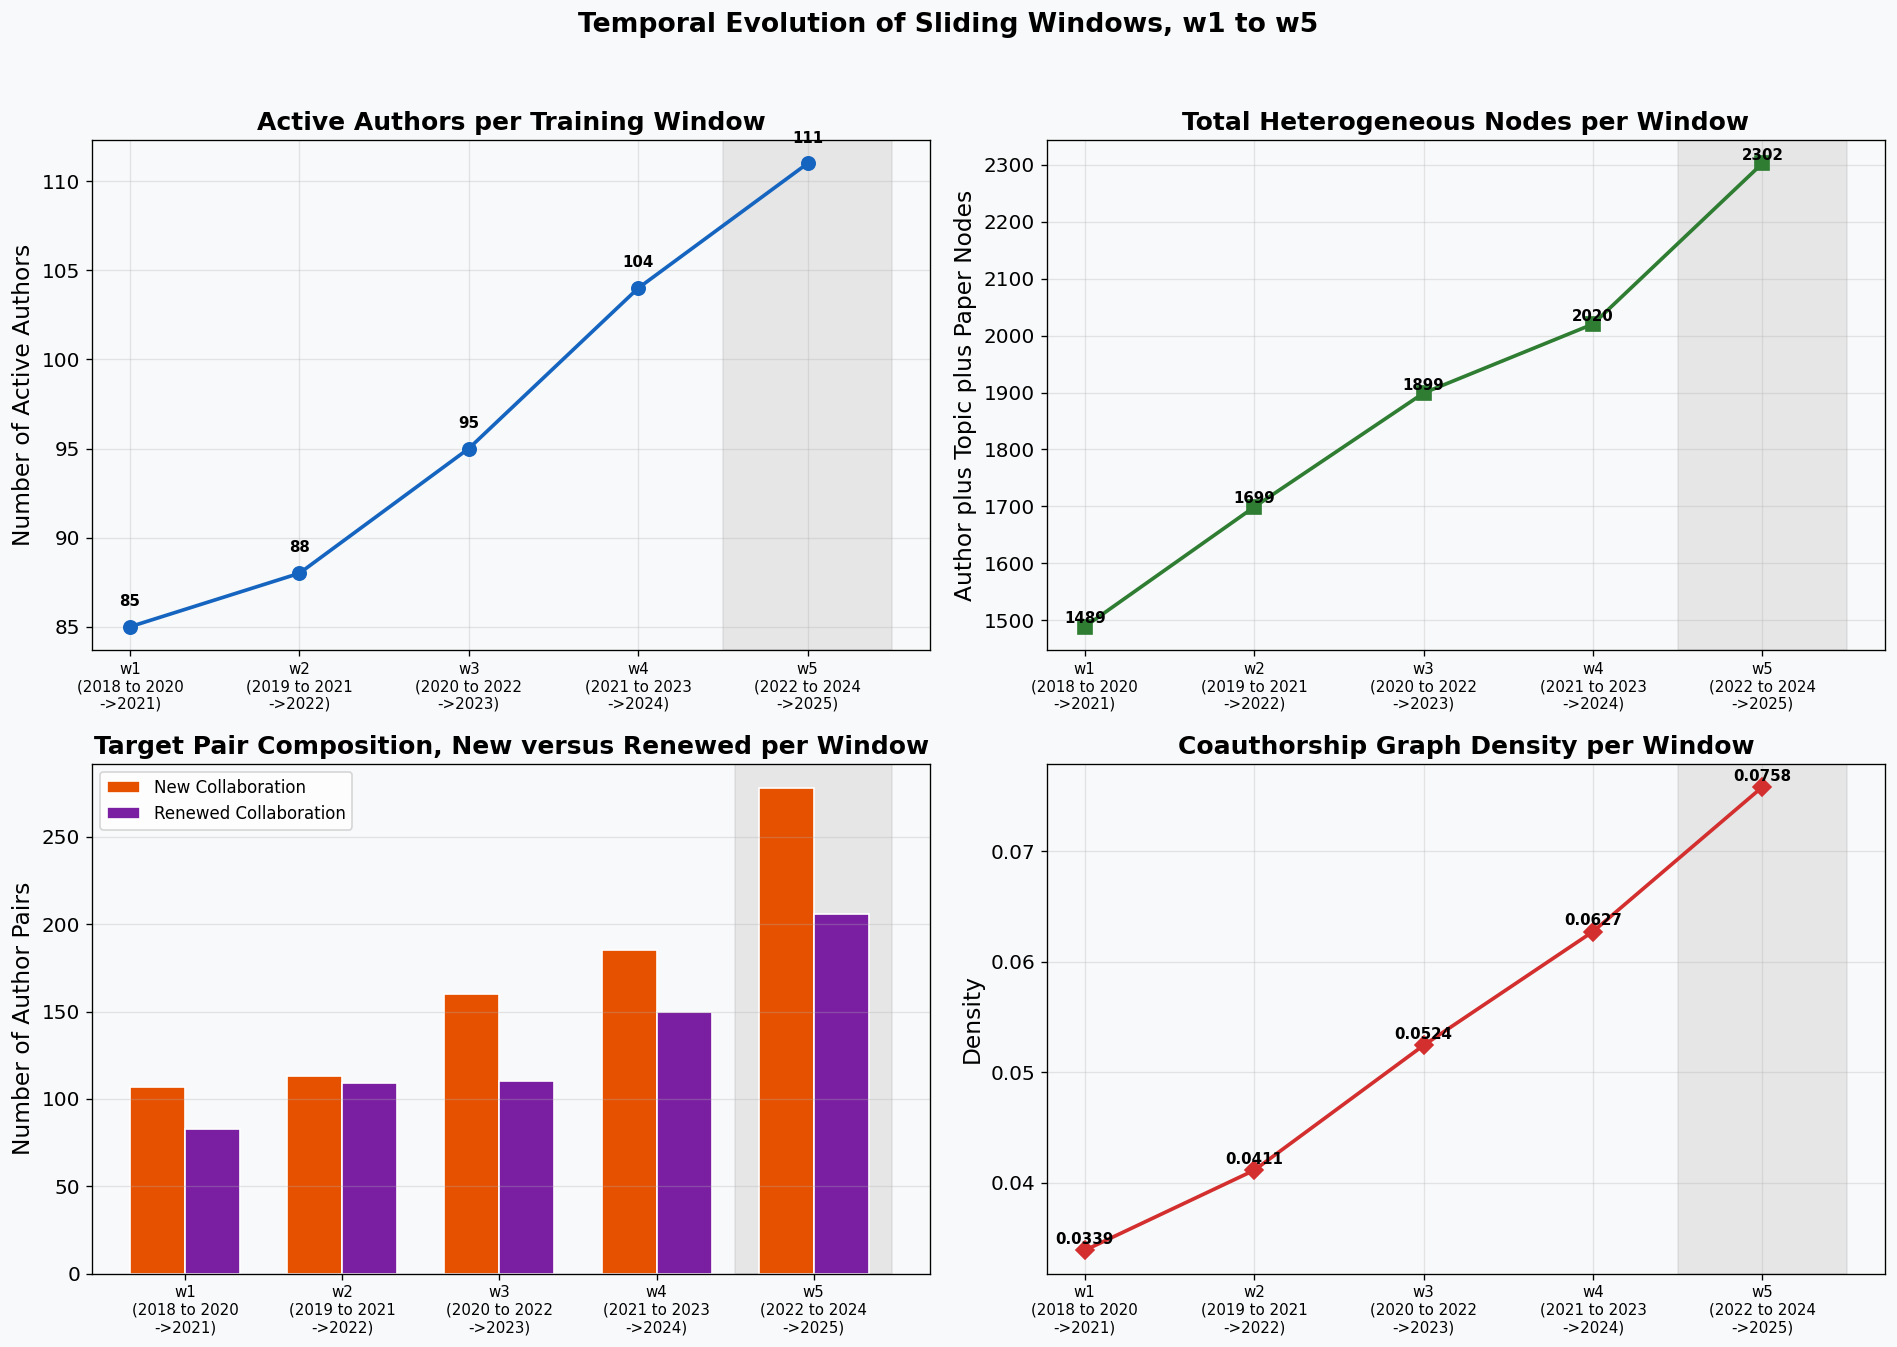

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor("#F8F9FA")
window_labels = [f"{r['window']}\n({r['train_years']}\n->{r['target_year']})" for _, r in window_summary_df.iterrows()]
x_w = np.arange(len(window_summary_df))
last_idx = len(x_w) - 1

ax = axes[0, 0]
ax.set_facecolor("#F8F9FA")
ax.axvspan(last_idx - 0.5, last_idx + 0.5, color="gray", alpha=0.15)
ax.plot(x_w, window_summary_df["active_authors"], marker="o", color="#1565C0", linewidth=2.2, markersize=8)
for xi, yi in zip(x_w, window_summary_df["active_authors"]):
    ax.text(xi, yi + 1, str(yi), ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x_w); ax.set_xticklabels(window_labels, fontsize=9)
ax.set_title("Active Authors per Training Window", fontweight="bold")
ax.set_ylabel("Number of Active Authors")
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.set_facecolor("#F8F9FA")
ax.axvspan(last_idx - 0.5, last_idx + 0.5, color="gray", alpha=0.15)
ax.plot(x_w, window_summary_df["hetero_nodes"], marker="s", color="#2E7D32", linewidth=2.2, markersize=8)
for xi, yi in zip(x_w, window_summary_df["hetero_nodes"]):
    ax.text(xi, yi + 1, str(yi), ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x_w); ax.set_xticklabels(window_labels, fontsize=9)
ax.set_title("Total Heterogeneous Nodes per Window", fontweight="bold")
ax.set_ylabel("Author plus Topic plus Paper Nodes")
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.set_facecolor("#F8F9FA")
ax.axvspan(last_idx - 0.5, last_idx + 0.5, color="gray", alpha=0.15)
width_w = 0.35
ax.bar(x_w - width_w / 2, window_summary_df["target_pairs_new"], width_w, label="New Collaboration", color="#E65100", edgecolor="white")
ax.bar(x_w + width_w / 2, window_summary_df["target_pairs_renewed"], width_w, label="Renewed Collaboration", color="#7B1FA2", edgecolor="white")
ax.set_xticks(x_w); ax.set_xticklabels(window_labels, fontsize=9)
ax.set_title("Target Pair Composition, New versus Renewed per Window", fontweight="bold")
ax.set_ylabel("Number of Author Pairs")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

ax = axes[1, 1]
ax.set_facecolor("#F8F9FA")
ax.axvspan(last_idx - 0.5, last_idx + 0.5, color="gray", alpha=0.15)
ax.plot(x_w, window_summary_df["graph_density"], marker="D", color="#D32F2F", linewidth=2.2, markersize=8)
for xi, yi in zip(x_w, window_summary_df["graph_density"]):
    ax.text(xi, yi + 0.0003, f"{yi:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x_w); ax.set_xticklabels(window_labels, fontsize=9)
ax.set_title("Coauthorship Graph Density per Window", fontweight="bold")
ax.set_ylabel("Density")
ax.grid(alpha=0.3)

fig.suptitle("Temporal Evolution of Sliding Windows, w1 to w5", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "temporal_window_evolution.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "temporal evolution of four metrics across sliding windows, active authors, heterogeneous node count, target pair composition, graph density")
plt.show()
plt.close(fig)

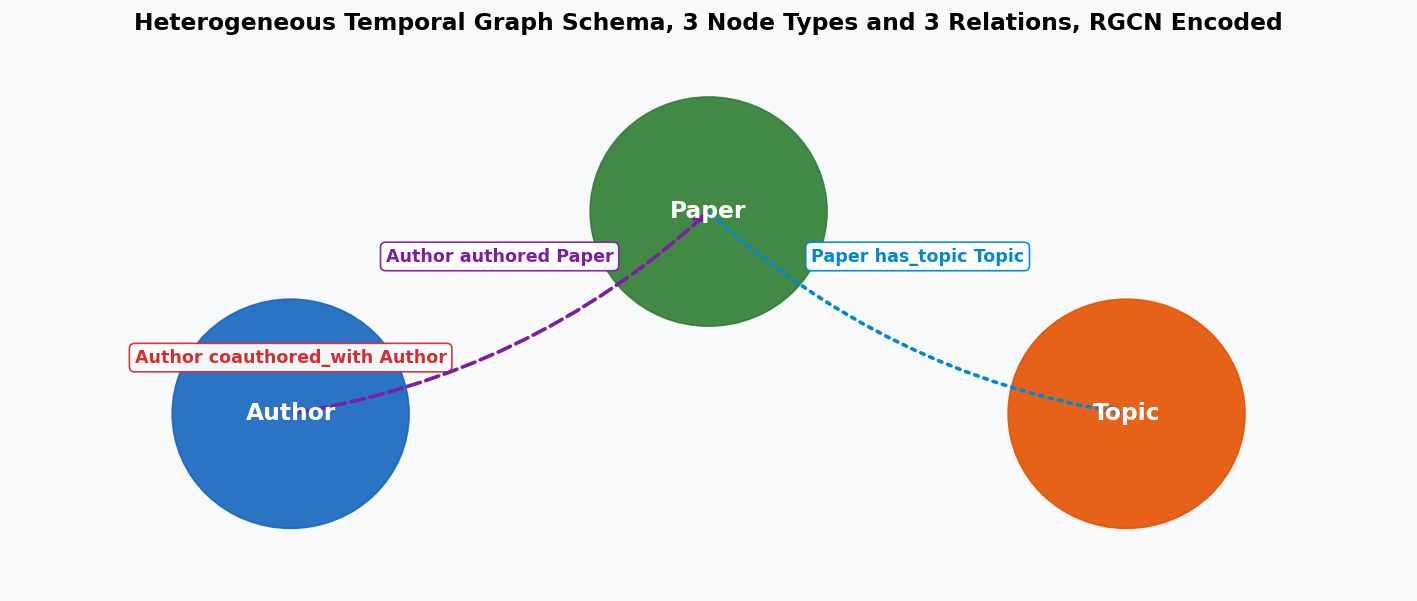

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.set_xlim(0.5, 10.5)
ax.set_ylim(1.2, 5.2)
ax.axis("off")
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")
node_colors = {"Author": "#1565C0", "Paper": "#2E7D32", "Topic": "#E65100"}
node_positions = {"Author": (2.5, 2.5), "Paper": (5.5, 4.0), "Topic": (8.5, 2.5)}
for node_type, (cx, cy) in node_positions.items():
    circle = plt.Circle((cx, cy), 0.85, color=node_colors[node_type], alpha=0.9, zorder=3)
    ax.add_patch(circle)
    ax.text(cx, cy, node_type, ha="center", va="center", fontsize=14, fontweight="bold", color="white", zorder=4)
edges_schema = [
    ("Author", "Author", "Author coauthored_with Author", "solid"),
    ("Author", "Paper", "Author authored Paper", "dashed"),
    ("Paper", "Topic", "Paper has_topic Topic", "dotted"),
]
edge_colors = ["#D32F2F", "#7B1FA2", "#0288D1"]
for (src, dst, label, ls), color in zip(edges_schema, edge_colors):
    sx, sy = node_positions[src]; dx, dy = node_positions[dst]
    mx, my = (sx + dx) / 2, (sy + dy) / 2 + 0.35
    ax.annotate("", xy=(dx, dy), xytext=(sx, sy),
        arrowprops=dict(arrowstyle="->", color=color, lw=2.2, linestyle=ls, connectionstyle="arc3,rad=0.15"))
    ax.text(mx, my, label, ha="center", va="bottom", fontsize=10.5, color=color, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=color, alpha=0.95))
ax.set_title("Heterogeneous Temporal Graph Schema, 3 Node Types and 3 Relations, RGCN Encoded", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "hetero_graph_schema.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "heterogeneous temporal graph schema diagram, three node types and three relations as implemented")
plt.show()

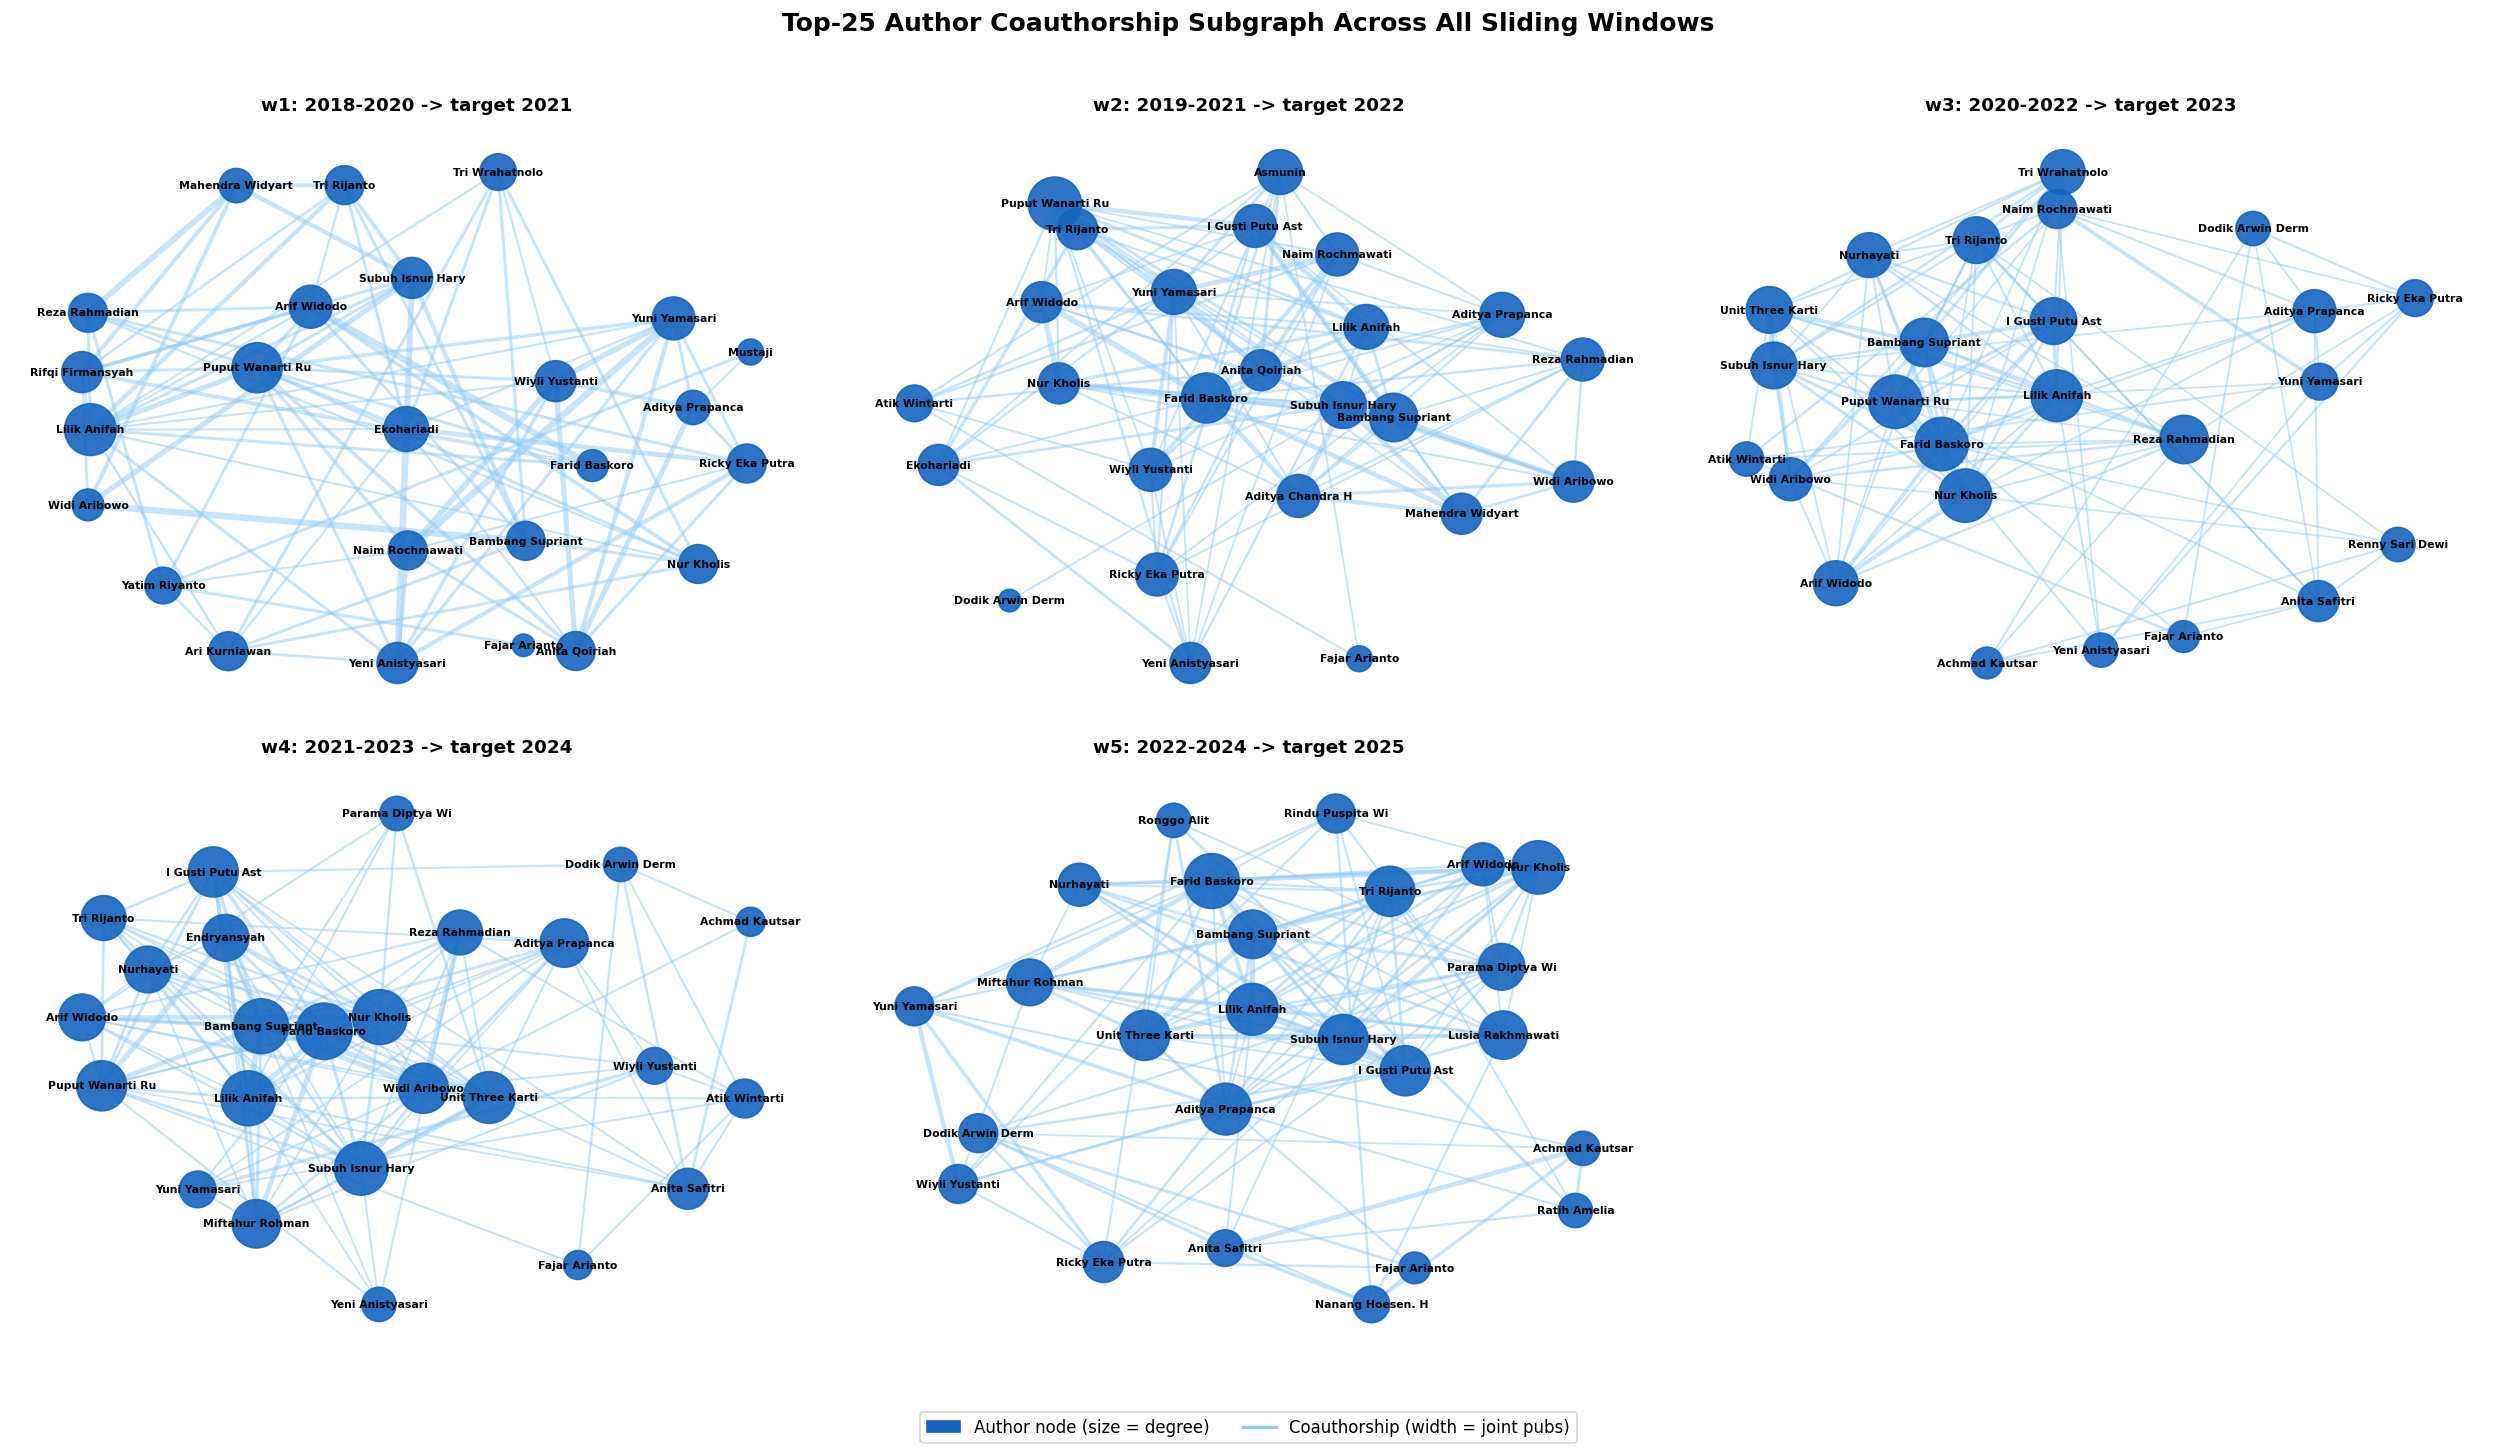

In [ ]:
node_name_map = dict(zip(id_name_lookup_df["author_id"], id_name_lookup_df["display_name"]))
n_windows = len(window_data_list)
n_cols = 3
n_rows = math.ceil(n_windows / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)
window_subgraphs = []
for idx, wd in enumerate(window_data_list):
    ax = axes[idx]
    nx_sample = wd["nx_coauthor"]
    sample_subgraph_nodes = sorted(nx_sample.degree(), key=lambda x: x[1], reverse=True)[:25]
    sample_nodes = [n for n, d in sample_subgraph_nodes]
    sample_subgraph = nx_sample.subgraph(sample_nodes)
    window_subgraphs.append(sample_subgraph)
    labels = {n: node_name_map.get(n, n)[:16] for n in sample_subgraph.nodes()}
    pos = nx.spring_layout(sample_subgraph, seed=RANDOM_SEED, k=2.5)
    edge_weights = [sample_subgraph[u][v].get("weight", 1) for u, v in sample_subgraph.edges()]
    max_w = max(edge_weights) if edge_weights else 1
    nx.draw_networkx_edges(sample_subgraph, pos, ax=ax, alpha=0.5,
        width=[1 + 3 * w / max_w for w in edge_weights], edge_color="#90CAF9")
    node_sizes = [120 + 60 * sample_subgraph.degree(n) for n in sample_subgraph.nodes()]
    nx.draw_networkx_nodes(sample_subgraph, pos, ax=ax, node_color="#1565C0", node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_labels(sample_subgraph, pos, labels=labels, ax=ax, font_size=6.5, font_color="black", font_weight="bold")
    ax.set_title(f"{wd['name']}: {wd['train_years'][0]}-{wd['train_years'][1]} -> target {wd['target_year']}", fontsize=11, fontweight="bold")
    ax.axis("off")
for idx in range(n_windows, len(axes)):
    axes[idx].axis("off")
legend_handles_g = [
    mpatches.Patch(color="#1565C0", label="Author node (size = degree)"),
    plt.Line2D([0], [0], color="#90CAF9", lw=2, label="Coauthorship (width = joint pubs)"),
]
fig.legend(handles=legend_handles_g, loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Top-25 Author Coauthorship Subgraph Across All Sliding Windows", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
p = os.path.join(OUTPUT_VIZ, "coauthor_subgraph_sample.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "top-25 author coauthorship subgraph with labeled nodes and edge width as weight, shown across all temporal sliding windows")
plt.show()

In [ ]:
plotly_layouts = [nx.spring_layout(sg, seed=RANDOM_SEED, k=2.5) for sg in window_subgraphs]

def build_frame_data(sg, pos_p):
    edge_x, edge_y = [], []
    for u, v in sg.edges():
        x0, y0 = pos_p[u]; x1, y1 = pos_p[v]
        edge_x += [x0, x1, None]; edge_y += [y0, y1, None]
    node_x = [pos_p[n][0] for n in sg.nodes()]
    node_y = [pos_p[n][1] for n in sg.nodes()]
    node_text = [node_name_map.get(n, n) for n in sg.nodes()]
    node_degree = [sg.degree(n) for n in sg.nodes()]
    edge_trace = go.Scatter(x=edge_x, y=edge_y, mode="lines",
        line=dict(color="#90CAF9", width=1.5), hoverinfo="none", name="Coauthorship edge")
    node_trace = go.Scatter(x=node_x, y=node_y, mode="markers+text",
        marker=dict(size=[8 + d * 2 for d in node_degree], color="#1565C0", opacity=0.9, line=dict(color="white", width=1)),
        text=node_text, textposition="top center", textfont=dict(size=10),
        hovertext=[f"{node_name_map.get(n, n)}<br>Degree: {sg.degree(n)}" for n in sg.nodes()],
        hoverinfo="text", name="Author node")
    return edge_trace, node_trace

initial_edge_trace, initial_node_trace = build_frame_data(window_subgraphs[0], plotly_layouts[0])
fig_sg = go.Figure(data=[initial_edge_trace, initial_node_trace])

frames = []
for wd, sg, pos_p in zip(window_data_list, window_subgraphs, plotly_layouts):
    edge_trace, node_trace = build_frame_data(sg, pos_p)
    frames.append(go.Frame(data=[edge_trace, node_trace], name=wd["name"],
        layout=go.Layout(title=f"Coauthorship Subgraph, Window {wd['name']} ({wd['train_years'][0]}-{wd['train_years'][1]}) -> target {wd['target_year']}")))
fig_sg.frames = frames

slider_steps = [
    dict(method="animate", args=[[wd["name"]], dict(mode="immediate", frame=dict(duration=800, redraw=True), transition=dict(duration=300))],
         label=f"{wd['name']} ({wd['train_years'][0]}-{wd['train_years'][1]})")
    for wd in window_data_list
]
fig_sg.update_layout(
    title=f"Interactive Coauthorship Subgraph Evolution (Top-25 Authors by Degree), Window {window_data_list[0]['name']} ({window_data_list[0]['train_years'][0]}-{window_data_list[0]['train_years'][1]})",
    showlegend=True, hovermode="closest",
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    width=1000, height=750,
    updatemenus=[dict(type="buttons", showactive=False, y=1.08, x=0.05,
        buttons=[dict(label="Play", method="animate", args=[None, dict(frame=dict(duration=800, redraw=True), fromcurrent=True)]),
                 dict(label="Pause", method="animate", args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")])])],
    sliders=[dict(active=0, steps=slider_steps, x=0.1, y=0, len=0.85)]
)
p = os.path.join(OUTPUT_VIZ, "coauthor_subgraph_interactive.html")
fig_sg.write_html(p)
register_artifact(p, "interactive plotly coauthorship subgraph across all temporal sliding windows with play/slider animation")
fig_sg.show()

## Temporal Split and Evaluation Setup

The train/validation/test split uses the last sliding window (2022-2024 -> target 2025). New author pairs appearing in the target year define positive labels. Cold-start pairs are those with no common neighbor in the training graph.

In [ ]:
TRAIN_CUTOFF_YEAR = 2024
last_wd = window_data_list[-1]
train_pair_set = last_wd["train_pair_set"]
target_pair_dict = last_wd["target_pair_dict"]
nx_train_graph = last_wd["nx_coauthor"]

new_future_pairs = [(a, b) for (a, b) in target_pair_dict.keys() if (a, b) not in train_pair_set]
new_future_pairs_df = pd.DataFrame(new_future_pairs, columns=["author_a", "author_b"])
print("new future collaboration pairs:", len(new_future_pairs_df))

np.random.seed(RANDOM_SEED)
shuffled_new_pairs = new_future_pairs_df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
n_val = max(1, int(len(shuffled_new_pairs) * 0.5))
val_positive_pairs_df = shuffled_new_pairs.iloc[:n_val].reset_index(drop=True)
test_positive_pairs_df = shuffled_new_pairs.iloc[n_val:].reset_index(drop=True)
print("val positives:", len(val_positive_pairs_df), "test positives:", len(test_positive_pairs_df))

split_path = os.path.join(OUTPUT_ROOT, "link_prediction_split_summary.csv")
pd.DataFrame({
    "split": ["train edges", "validation positives", "test positives"],
    "n_pairs": [len(train_pair_set), len(val_positive_pairs_df), len(test_positive_pairs_df)],
}).to_csv(split_path, index=False)
register_artifact(split_path, "temporal split summary")

new future collaboration pairs: 278
val positives: 139 test positives: 139


### Cold-Start Diagnostics

Pairs with no common neighbor in the training graph constitute the cold-start subset. Models that
rely solely on graph topology are expected to score near chance level (AUC ≈ 0.5) on this subset.

In [ ]:
def has_common_neighbor(graph, a, b):
    if a not in graph or b not in graph:
        return False
    return len(set(graph.neighbors(a)) & set(graph.neighbors(b))) > 0

val_positive_pairs_df["is_cold_start"] = val_positive_pairs_df.apply(
    lambda row: not has_common_neighbor(nx_train_graph, row["author_a"], row["author_b"]), axis=1)
test_positive_pairs_df["is_cold_start"] = test_positive_pairs_df.apply(
    lambda row: not has_common_neighbor(nx_train_graph, row["author_a"], row["author_b"]), axis=1)
cold_start_summary = pd.DataFrame({
    "split": ["validation", "test"],
    "n_pairs": [len(val_positive_pairs_df), len(test_positive_pairs_df)],
    "cold_start_ratio": [val_positive_pairs_df["is_cold_start"].mean(), test_positive_pairs_df["is_cold_start"].mean()],
})
print(cold_start_summary.to_string(index=False))
cs_path = os.path.join(OUTPUT_ROOT, "cold_start_diagnostics.csv")
cold_start_summary.to_csv(cs_path, index=False)
register_artifact(cs_path, "cold-start ratio of evaluation pairs with no common neighbor in training graph")

     split  n_pairs  cold_start_ratio
validation      139          0.467626
      test      139          0.503597


### Negative Sampling Strategy

Random negatives are sampled from all author pairs not present in training. Hard negatives are pairs that share at least one research topic but have never collaborated. The 50/50 mixture improves evaluation realism by challenging the model on semantically similar but non-collaborating pairs.

In [ ]:
author_topic_membership_hist = {}
paper_topic_long_hist = paper_topic_long[paper_topic_long["paper_id"].isin(
    clean_papers_df[clean_papers_df["year"] <= TRAIN_CUTOFF_YEAR]["paper_id"]
)]
for author_id, group in paper_topic_long_hist.groupby("author_id"):
    author_topic_membership_hist[author_id] = set(group["topic_id"].astype(str))
for a in all_author_ids_sorted:
    author_topic_membership_hist.setdefault(a, set())

def shares_topic_hist(pair):
    a, b = pair
    return bool(author_topic_membership_hist.get(a, set()) & author_topic_membership_hist.get(b, set()))

def _random_pair_batch(rng_obj, batch_size):
    i_arr = rng_obj.integers(0, N_AUTHORS, size=batch_size)
    j_arr = rng_obj.integers(0, N_AUTHORS, size=batch_size)
    return i_arr, j_arr

def sample_negative_pairs(positive_pairs, forbidden_pairs, n_random, n_hard, rng_obj):
    pos_set = set(positive_pairs)
    forbidden_full = forbidden_pairs | pos_set

    rand_neg = set()
    max_attempts = max(n_random * 30, 5000)
    attempts = 0
    while len(rand_neg) < n_random and attempts < max_attempts:
        batch = min(max_attempts - attempts, max((n_random - len(rand_neg)) * 4, 512))
        i_arr, j_arr = _random_pair_batch(rng_obj, batch)
        attempts += batch
        for ii, jj in zip(i_arr, j_arr):
            if ii == jj:
                continue
            a, b = all_author_ids_sorted[ii], all_author_ids_sorted[jj]
            if a > b:
                a, b = b, a
            pair = (a, b)
            if pair not in forbidden_full and pair not in rand_neg:
                rand_neg.add(pair)
                if len(rand_neg) >= n_random:
                    break

    hard_neg = set()
    max_attempts_h = max(n_hard * 60, 5000)
    attempts = 0
    while len(hard_neg) < n_hard and attempts < max_attempts_h:
        batch = min(max_attempts_h - attempts, max((n_hard - len(hard_neg)) * 6, 512))
        i_arr, j_arr = _random_pair_batch(rng_obj, batch)
        attempts += batch
        for ii, jj in zip(i_arr, j_arr):
            if ii == jj:
                continue
            a, b = all_author_ids_sorted[ii], all_author_ids_sorted[jj]
            if a > b:
                a, b = b, a
            pair = (a, b)
            if pair in forbidden_full or pair in rand_neg or pair in hard_neg:
                continue
            if shares_topic_hist(pair):
                hard_neg.add(pair)
                if len(hard_neg) >= n_hard:
                    break

    return list(rand_neg) + list(hard_neg)

rng = np.random.default_rng(RANDOM_SEED)
val_pos_list = list(zip(val_positive_pairs_df["author_a"], val_positive_pairs_df["author_b"]))
test_pos_list = list(zip(test_positive_pairs_df["author_a"], test_positive_pairs_df["author_b"]))
forbidden = train_pair_set | set(val_pos_list)
n_neg = max(len(val_pos_list), len(test_pos_list), 50)
val_neg = sample_negative_pairs(val_pos_list, train_pair_set, n_neg, n_neg // 2, rng)[:len(val_pos_list)]
test_neg = sample_negative_pairs(test_pos_list, forbidden, n_neg, n_neg // 2, rng)[:len(test_pos_list)]
print(f"val: {len(val_pos_list)} pos, {len(val_neg)} neg")
print(f"test: {len(test_pos_list)} pos, {len(test_neg)} neg")

val: 139 pos, 139 neg
test: 139 pos, 139 neg


## Evaluation Utility

All models are evaluated on the held-out test split using ROC AUC, Average Precision (AP), Hits@10, and MRR for the classification task, and RMSE and MAE for the regression task on collaboration intensity.

In [ ]:
def evaluate_link_prediction(positive_scores, negative_scores):
    y_true = [1] * len(positive_scores) + [0] * len(negative_scores)
    y_score = list(positive_scores) + list(negative_scores)
    if len(set(y_true)) < 2:
        return {"auc": float("nan"), "average_precision": float("nan"), "hits_at_10": 0.0, "mrr": 0.0}
    auc_val = float(roc_auc_score(y_true, y_score))
    ap_val = float(average_precision_score(y_true, y_score))

    neg_array = np.array(negative_scores)
    ranks = []
    for score in positive_scores:
        rank = 1 + int(np.sum(neg_array >= score))
        ranks.append(rank)
    ranks = np.array(ranks)
    hits_at_10 = float(np.mean(ranks <= 10))
    mrr_val = float(np.mean(1.0 / ranks))

    return {"auc": auc_val, "average_precision": ap_val, "hits_at_10": hits_at_10, "mrr": mrr_val}

def compute_regression_metrics(pred_intensities, true_intensities):
    preds = np.array(pred_intensities)
    truths = np.array(true_intensities)
    rmse = float(np.sqrt(np.mean((preds - truths) ** 2)))
    mae = float(np.mean(np.abs(preds - truths)))
    return {"rmse": rmse, "mae": mae}

def describe_model(model, name):
    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Arsitektur Model: {name}\n")
    print(model)
    print(f"\nTotal parameter: {n_params:,} | Trainable: {n_trainable:,}\n")

print("evaluation metric utilities (AUC, AP, Hits@10, MRR, RMSE, MAE) ready")

evaluation metric utilities (AUC, AP, Hits@10, MRR, RMSE, MAE) ready


## Baseline (Non-learned)

Three structure-based non-learned baselines are computed: Jaccard Coefficient, Adamic-Adar Index, and Resource Allocation Index. All three exploit neighborhood overlap on the training graph.

In [ ]:
def score_pairs_jaccard(graph, pairs):
    return [s for _, _, s in nx.jaccard_coefficient(graph, [(a, b) for a, b in pairs])]

def score_pairs_adamic_adar(graph, pairs):
    return [s for _, _, s in nx.adamic_adar_index(graph, [(a, b) for a, b in pairs])]

def score_pairs_resource_allocation(graph, pairs):
    return [s for _, _, s in nx.resource_allocation_index(graph, [(a, b) for a, b in pairs])]

jaccard_test_scores = score_pairs_jaccard(nx_train_graph, test_pos_list + test_neg)
adamic_test_scores = score_pairs_adamic_adar(nx_train_graph, test_pos_list + test_neg)
ra_test_scores = score_pairs_resource_allocation(nx_train_graph, test_pos_list + test_neg)

jaccard_class_metrics = evaluate_link_prediction(jaccard_test_scores[:len(test_pos_list)], jaccard_test_scores[len(test_pos_list):])
adamic_class_metrics = evaluate_link_prediction(adamic_test_scores[:len(test_pos_list)], adamic_test_scores[len(test_pos_list):])
ra_class_metrics = evaluate_link_prediction(ra_test_scores[:len(test_pos_list)], ra_test_scores[len(test_pos_list):])

dummy_reg_true = np.array([1.0] * len(test_pos_list) + [0.0] * len(test_neg))
jaccard_reg_metrics = compute_regression_metrics(np.array(jaccard_test_scores), dummy_reg_true)
adamic_reg_metrics = compute_regression_metrics(np.array(adamic_test_scores), dummy_reg_true)
ra_reg_metrics = compute_regression_metrics(np.array(ra_test_scores), dummy_reg_true)

baseline_results_df = pd.DataFrame([
    {"model": "Common Neighbors Jaccard", **jaccard_class_metrics, **jaccard_reg_metrics},
    {"model": "Adamic Adar", **adamic_class_metrics, **adamic_reg_metrics},
    {"model": "Resource Allocation", **ra_class_metrics, **ra_reg_metrics},
])

print("Baseline Evaluation Summary:")
print(baseline_results_df.to_string(index=False))

Baseline Evaluation Summary:
                   model      auc  average_precision  hits_at_10      mrr     rmse      mae
Common Neighbors Jaccard 0.636458           0.663901    0.309353 0.125577 0.663921 0.477471
             Adamic Adar 0.636665           0.661035    0.302158 0.119317 0.694014 0.473712
     Resource Allocation 0.636277           0.657441    0.302158 0.113776 0.649277 0.468241


## Dynamic Self Attention Network DySAT Architecture

DySAT first encodes the heterogeneous snapshot with a relational graph convolution across the three relations, then refines Author representations with edge weighted Spatial Graph Attention over the coauthorship graph. A causally masked Multi Head Temporal Self Attention layer combines the Author representations across the sequence of snapshots so that each window only attends to itself and earlier windows. A dual task output head predicts link classification probability and collaboration intensity regression simultaneously.

In [ ]:
from torch_geometric.nn import GATv2Conv
from torch_geometric_temporal.nn.recurrent import EvolveGCNO

_PAIR_FEATURE_MATRIX_CACHE = {}

def _build_pair_feature_matrices(graph, raw_features):
    N = len(all_author_ids_sorted)
    adj = np.zeros((N, N), dtype=np.float32)
    for a, b in graph.edges():
        i, j = author_id_to_index[a], author_id_to_index[b]
        adj[i, j] = 1.0
        adj[j, i] = 1.0
    deg = adj.sum(axis=1)
    common = adj @ adj
    np.fill_diagonal(common, 0.0)
    union = deg[:, None] + deg[None, :] - common
    jaccard = common / np.maximum(union, 1e-8)
    log_deg = np.log(np.maximum(deg, 2.0))
    inv_deg = 1.0 / np.maximum(deg, 1.0)
    aa = (adj * (1.0 / log_deg)[None, :]) @ adj.T
    ra = (adj * inv_deg[None, :]) @ adj.T
    pa = np.outer(deg, deg)
    content = raw_features[:, :384]
    norm = np.linalg.norm(content, axis=1, keepdims=True) + 1e-8
    content_n = content / norm
    content_sim = content_n @ content_n.T
    return {"common": common, "jaccard": jaccard, "aa": aa, "ra": ra, "pa": pa, "content_sim": content_sim}

def compute_ultra_pair_features(graph, pair_indices, raw_features):
    key = id(graph)
    if key not in _PAIR_FEATURE_MATRIX_CACHE:
        _PAIR_FEATURE_MATRIX_CACHE[key] = _build_pair_feature_matrices(graph, raw_features)
    m = _PAIR_FEATURE_MATRIX_CACHE[key]
    u_idx = pair_indices[:, 0]
    v_idx = pair_indices[:, 1]
    cn_count = m["common"][u_idx, v_idx]
    jaccard = m["jaccard"][u_idx, v_idx]
    aa_score = m["aa"][u_idx, v_idx]
    pa_score = m["pa"][u_idx, v_idx]
    ra_score = m["ra"][u_idx, v_idx]
    content_sim = m["content_sim"][u_idx, v_idx]
    feats = np.stack([
        cn_count / 10.0, jaccard, aa_score / 10.0,
        np.log1p(pa_score) / 10.0, ra_score / 10.0, content_sim
    ], axis=1)
    return torch.tensor(feats, dtype=torch.float32, device=DEVICE)

class HeteroRelationalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_relations, dropout=0.15):
        super().__init__()
        self.conv = RGCNConv(in_channels, out_channels, num_relations=num_relations)
        self.norm = nn.LayerNorm(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.proj = nn.Linear(in_channels, out_channels) if in_channels != out_channels else nn.Identity()

    def forward(self, x, edge_index, edge_type):
        h = self.conv(x, edge_index, edge_type)
        h = self.norm(F.elu(h) + self.proj(x))
        return self.dropout(h)

class EdgeWeightedGATBlock(nn.Module):
    def __init__(self, in_channels, out_channels, heads=4, dropout=0.15):
        super().__init__()
        self.conv = GATv2Conv(in_channels, out_channels // heads, heads=heads, edge_dim=1, concat=True, dropout=dropout)
        self.norm = nn.LayerNorm(out_channels)
        self.proj = nn.Linear(in_channels, out_channels) if in_channels != out_channels else nn.Identity()

    def forward(self, x, edge_index, edge_attr):
        h = self.conv(x, edge_index, edge_attr)
        return self.norm(F.elu(h + self.proj(x)))

class DeepTopoHead(nn.Module):
    def __init__(self, hidden_dim, dropout=0.15):
        super().__init__()
        in_dim = hidden_dim * 4 + 1 + 6
        self.link_mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
        self.intensity_mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, src, dst, topo_feats):
        hadamard = src * dst
        abs_diff = torch.abs(src - dst)
        cos_sim = F.cosine_similarity(src, dst, dim=-1, eps=1e-8).unsqueeze(-1)
        pair_feat = torch.cat([src, dst, hadamard, abs_diff, cos_sim, topo_feats], dim=-1)
        logits = self.link_mlp(pair_feat).squeeze(-1)
        probs = torch.sigmoid(logits)
        intensities = self.intensity_mlp(pair_feat).squeeze(-1)
        return probs, intensities

class DySATModel(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_relations=3, n_spatial_layers=2, n_temporal_heads=4, dropout=0.15):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.hetero_block = HeteroRelationalBlock(hidden_dim, hidden_dim, num_relations=num_relations, dropout=dropout)
        self.spatial_layers = nn.ModuleList([
            EdgeWeightedGATBlock(hidden_dim, hidden_dim, heads=4, dropout=dropout) for _ in range(n_spatial_layers)
        ])
        self.temporal_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=n_temporal_heads, dropout=dropout, batch_first=True)
        self.temporal_gate = nn.Parameter(torch.tensor(-2.0))
        self.norm_temp = nn.LayerNorm(hidden_dim)
        self.norm_final = nn.LayerNorm(hidden_dim)
        self.head = DeepTopoHead(hidden_dim, dropout=dropout)
        self.hidden_dim = hidden_dim

    def encode_snapshot(self, x_hetero, edge_index_hetero, edge_type_hetero, edge_index_author, edge_attr_author, n_authors):
        h = F.elu(self.input_proj(x_hetero))
        h = self.hetero_block(h, edge_index_hetero, edge_type_hetero)
        h_author = h[:n_authors]
        for layer in self.spatial_layers:
            h_author = layer(h_author, edge_index_author, edge_attr_author)
        return h_author

    def forward(self, snapshot_list):
        snapshot_embs = [
            self.encode_snapshot(xh.to(DEVICE), eih.to(DEVICE), eth.to(DEVICE), eia.to(DEVICE), eaa.to(DEVICE), n_auth)
            for xh, eih, eth, eia, eaa, n_auth in snapshot_list
        ]
        stacked = torch.stack(snapshot_embs, dim=1)
        T = stacked.shape[1]
        causal_mask = torch.triu(torch.full((T, T), float("-inf"), device=DEVICE), diagonal=1)
        attn_out, _ = self.temporal_attn(stacked, stacked, stacked, attn_mask=causal_mask)
        gate = torch.sigmoid(self.temporal_gate)
        temporal_out = self.norm_temp(stacked + gate * attn_out)
        return self.norm_final(temporal_out)

    def predict_pairs(self, node_embs, pair_indices, graph, raw_features):
        src = node_embs[pair_indices[:, 0]]
        dst = node_embs[pair_indices[:, 1]]
        topo_feats = compute_ultra_pair_features(graph, pair_indices.cpu().numpy(), raw_features)
        return self.head(src, dst, topo_feats)

IN_DIM = window_data_list[0]["author_features"].shape[1]
print(f"input feature dimension: {IN_DIM}")
LEARNED_MODEL_EPOCHS = 150
LEARNED_MODEL_PATIENCE = 20
LEARNED_MODEL_LR = 8e-4
LEARNED_MODEL_WEIGHT_DECAY = 2e-4
NEG_RANDOM_MULTIPLIER = 2
NEG_HARD_MULTIPLIER = 0.5

model = DySATModel(in_dim=IN_DIM, hidden_dim=128, num_relations=NUM_HETERO_RELATIONS, n_spatial_layers=2, n_temporal_heads=4, dropout=0.15).to(DEVICE)
describe_model(model, "DySAT (Heterogeneous, Causal Temporal)")

snapshot_list = [
    (wd["x_hetero"], wd["edge_index_hetero"], wd["edge_type_hetero"], wd["edge_index"], wd["edge_attr"], N_AUTHORS)
    for wd in window_data_list
]

input feature dimension: 452
Arsitektur Model: DySAT (Heterogeneous, Causal Temporal)

DySATModel(
  (input_proj): Linear(in_features=452, out_features=128, bias=True)
  (hetero_block): HeteroRelationalBlock(
    (conv): RGCNConv(128, 128, num_relations=3)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
    (proj): Identity()
  )
  (spatial_layers): ModuleList(
    (0-1): 2 x EdgeWeightedGATBlock(
      (conv): GATv2Conv(128, 32, heads=4)
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (proj): Identity()
    )
  )
  (temporal_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (norm_temp): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (norm_final): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): DeepTopoHead(
    (link_mlp): Sequential(
      (0): Linear(in_features=519, out_features=256, bias=True

## Dual Task Training Objective

DySAT is trained with a dual head loss combining Binary Cross Entropy for link classification and Mean Squared Error for collaboration intensity regression. Supervision comes from the target pairs of windows w1 to w4 only, these are in sample training targets and are never used as held out generalization evidence. The causal mask guarantees that a window can only be influenced by itself and earlier windows during both training and evaluation.



### Regression Target: Collaboration Intensity

The regression target measures **how strongly two authors are expected to co-author again**, scaled between 0 and 1.

**How it's computed:**

1. Count how many papers the pair actually co-authored in the target year → the **raw collaboration count**.
2. Set an **upper cap**, taken from historical data (windows w1–w4) as the 95th percentile of collaboration counts. This prevents a few highly prolific pairs from skewing the scale.
3. Target = **raw count divided by the cap**, clipped to a maximum of 1.

**Formula:**

$$
y = \frac{\min(\text{raw count},\ \text{cap})}{\text{cap}}
$$

**Example:**

| Pair | Raw Count | Cap | Target |
|---|---|---|---|
| A & B | 3 papers | 5 | 3/5 = **0.6** |
| C & D | 8 papers | 5 | clipped → **1.0** |
| E & F | 0 papers | 5 | **0.0** |

In [ ]:
all_hist_counts = [c for wd in window_data_list[:-1] for c in wd["target_pair_dict"].values()]
INTENSITY_CAP = max(2, int(np.percentile(all_hist_counts, 95))) if all_hist_counts else 10
print(f"intensity cap (95th percentile of historical joint paper counts): {INTENSITY_CAP}")

def prepare_supervision(window_data, target_pairs_dict, rng_obj, n_neg_per_pos=3):
    pos_pairs = list(target_pairs_dict.keys())
    pos_weights = np.array([min(target_pairs_dict[p], INTENSITY_CAP) / INTENSITY_CAP for p in pos_pairs], dtype=np.float32)
    pos_set = set(pos_pairs)
    train_pos = window_data["train_pair_set"]
    forbidden_full = train_pos | pos_set

    n_neg_target = len(pos_pairs) * n_neg_per_pos
    neg_pairs_set = set()
    max_attempts = max(n_neg_target * 30, 5000)
    attempts = 0
    while len(neg_pairs_set) < n_neg_target and attempts < max_attempts:
        batch = min(max_attempts - attempts, max((n_neg_target - len(neg_pairs_set)) * 4, 512))
        i_arr = rng_obj.integers(0, N_AUTHORS, size=batch)
        j_arr = rng_obj.integers(0, N_AUTHORS, size=batch)
        attempts += batch
        for ii, jj in zip(i_arr, j_arr):
            if ii == jj:
                continue
            a, b = all_author_ids_sorted[ii], all_author_ids_sorted[jj]
            if a > b:
                a, b = b, a
            pair = (a, b)
            if pair not in forbidden_full and pair not in neg_pairs_set:
                neg_pairs_set.add(pair)
                if len(neg_pairs_set) >= n_neg_target:
                    break

    neg_pairs = list(neg_pairs_set)
    all_pairs = pos_pairs + neg_pairs
    labels = np.array([1.0] * len(pos_pairs) + [0.0] * len(neg_pairs), dtype=np.float32)
    intensities = np.array(list(pos_weights) + [0.0] * len(neg_pairs), dtype=np.float32)
    pair_indices = torch.tensor([[author_id_to_index[a], author_id_to_index[b]] for a, b in all_pairs], dtype=torch.long)
    return pair_indices, torch.tensor(labels), torch.tensor(intensities)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNED_MODEL_LR, weight_decay=LEARNED_MODEL_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=LEARNED_MODEL_EPOCHS, eta_min=1e-5)
LAMBDA_REG = 0.15

val_pair_idx = torch.tensor([[author_id_to_index[a], author_id_to_index[b]] for a, b in val_pos_list + val_neg], dtype=torch.long)
val_labels = torch.tensor([1.0] * len(val_pos_list) + [0.0] * len(val_neg))
train_rng = np.random.default_rng(RANDOM_SEED)

best_val_auc = 0.0
patience_counter = 0
train_loss_history = []
val_auc_history = []
best_model_state = None

print(f"training DySAT for {LEARNED_MODEL_EPOCHS} epochs with early stopping (patience={LEARNED_MODEL_PATIENCE})...")
for epoch in range(LEARNED_MODEL_EPOCHS):
    model.train()
    optimizer.zero_grad()
    all_embs = model(snapshot_list)
    total_loss = torch.tensor(0.0, device=DEVICE, requires_grad=True)
    n_used = 0
    for t, wd in enumerate(window_data_list[:-1]):
        target_dict = wd["target_pair_dict"]
        if not target_dict:
            continue
        pi, lt, it = prepare_supervision(wd, wd["target_pair_dict"], train_rng)
        if pi.shape[0] == 0:
            continue
        embs_t = all_embs[:, t, :]
        lp, ip = model.predict_pairs(embs_t, pi.to(DEVICE), wd["nx_coauthor"], wd["author_features"].numpy())
        bce = F.binary_cross_entropy(lp.clamp(1e-7, 1 - 1e-7), lt.to(DEVICE))
        mse = F.mse_loss(ip, it.to(DEVICE))
        total_loss = total_loss + bce + LAMBDA_REG * mse
        n_used += 1
        del pi, lt, it, embs_t, lp, ip, bce, mse
    if n_used > 0:
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    scheduler.step()
    model.eval()
    with torch.no_grad():
        embs_eval = model(snapshot_list)[:, -1, :]
        val_probs, _ = model.predict_pairs(embs_eval, val_pair_idx.to(DEVICE), nx_train_graph, last_wd["author_features"].numpy())
        val_probs_np = val_probs.cpu().numpy()
    val_auc = roc_auc_score(val_labels.numpy(), val_probs_np) if len(set(val_labels.numpy())) > 1 else 0.5
    train_loss_history.append(float(total_loss.item()) / max(n_used, 1))
    val_auc_history.append(val_auc)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
    del all_embs, total_loss, embs_eval, val_probs, val_probs_np
    free_memory()
    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1:3d}/{LEARNED_MODEL_EPOCHS} loss={train_loss_history[-1]:.4f} val_auc={val_auc:.4f} best={best_val_auc:.4f}")
    if patience_counter >= LEARNED_MODEL_PATIENCE:
        print(f"early stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"restored best model val_auc={best_val_auc:.4f}")
dysat_path = os.path.join(OUTPUT_MODELS, "dysat_model.pt")
torch.save(model.state_dict(), dysat_path)
register_artifact(dysat_path, "trained DySAT model state dict")

del optimizer, scheduler, best_model_state
free_memory()

intensity cap (95th percentile of historical joint paper counts): 5
training DySAT for 150 epochs with early stopping (patience=20)...
  epoch  10/150 loss=0.4668 val_auc=0.5889 best=0.5889
  epoch  20/150 loss=0.3905 val_auc=0.6225 best=0.6226
  epoch  30/150 loss=0.3430 val_auc=0.6579 best=0.6579
  epoch  40/150 loss=0.3194 val_auc=0.6564 best=0.6635
  epoch  50/150 loss=0.3028 val_auc=0.6622 best=0.6663
  epoch  60/150 loss=0.2797 val_auc=0.6606 best=0.6702
  epoch  70/150 loss=0.2618 val_auc=0.6792 best=0.6792
  epoch  80/150 loss=0.2552 val_auc=0.6739 best=0.6792
  epoch  90/150 loss=0.2497 val_auc=0.6563 best=0.6792
early stopping at epoch 90
restored best model val_auc=0.6792


In [ ]:
model.eval()
with torch.no_grad():
    all_embs_final = model(snapshot_list)

TRAIN_CUTOFF_YEAR = 2024
last_wd = window_data_list[-1]
train_pair_set = last_wd["train_pair_set"]
target_pair_dict = last_wd["target_pair_dict"]
nx_train_graph = last_wd["nx_coauthor"]

per_window_rows = []
per_window_rng = np.random.default_rng(RANDOM_SEED)
for t, wd in enumerate(window_data_list):
    is_final_window = t == len(window_data_list) - 1
    if is_final_window:
        pos_pairs_w = test_pos_list
        neg_pairs_w = test_neg
        role = "Held Out Validation and Test Window"
    else:
        target_dict = wd["target_pair_dict"]
        if not target_dict:
            continue
        pos_pairs_w = list(target_dict.keys())
        neg_pairs_w = sample_negative_pairs(pos_pairs_w, wd["train_pair_set"],
                                             len(pos_pairs_w) * NEG_RANDOM_MULTIPLIER,
                                             int(len(pos_pairs_w) * NEG_HARD_MULTIPLIER), per_window_rng)
        role = "In Sample Training Target Window"
    pair_idx_w = torch.tensor([[author_id_to_index[a], author_id_to_index[b]] for a, b in pos_pairs_w + neg_pairs_w], dtype=torch.long)
    embs_t = all_embs_final[:, t, :]
    with torch.no_grad():
        probs_w, _ = model.predict_pairs(embs_t, pair_idx_w.to(DEVICE), wd["nx_coauthor"], wd["author_features"].numpy())
    probs_np_w = probs_w.cpu().numpy()
    metrics_w = evaluate_link_prediction(probs_np_w[:len(pos_pairs_w)], probs_np_w[len(pos_pairs_w):])
    per_window_rows.append({
        "window": wd["name"], "train_years": f"{wd['train_years'][0]} to {wd['train_years'][1]}",
        "target_year": wd["target_year"], "role": role, "n_target_pairs": len(pos_pairs_w),
        **metrics_w,
    })

per_window_df = pd.DataFrame(per_window_rows)
print("DySAT score per sliding window, w1 to w4 evaluated on in sample target pairs, w5 evaluated on the identical held out test split used by DySAT Test Results:")
print(per_window_df.to_string(index=False))
p = os.path.join(OUTPUT_ROOT, "dysat_per_window_metrics.csv")
per_window_df.to_csv(p, index=False)
register_artifact(p, "AUC, AP, Hits at 10, MRR for DySAT evaluated separately per temporal sliding window")

del all_embs_final
free_memory()

DySAT score per sliding window, w1 to w4 evaluated on in sample target pairs, w5 evaluated on the identical held out test split used by DySAT Test Results:
window  train_years  target_year                                role  n_target_pairs      auc  average_precision  hits_at_10      mrr
    w1 2018 to 2020         2021    In Sample Training Target Window             190 0.958161           0.929209    0.773684 0.475491
    w2 2019 to 2021         2022    In Sample Training Target Window             222 0.950702           0.909474    0.594595 0.394466
    w3 2020 to 2022         2023    In Sample Training Target Window             270 0.913822           0.848020    0.477778 0.235855
    w4 2021 to 2023         2024    In Sample Training Target Window             335 0.918026           0.859947    0.513433 0.316196
    w5 2022 to 2024         2025 Held Out Validation and Test Window             139 0.686041           0.700768    0.273381 0.113492


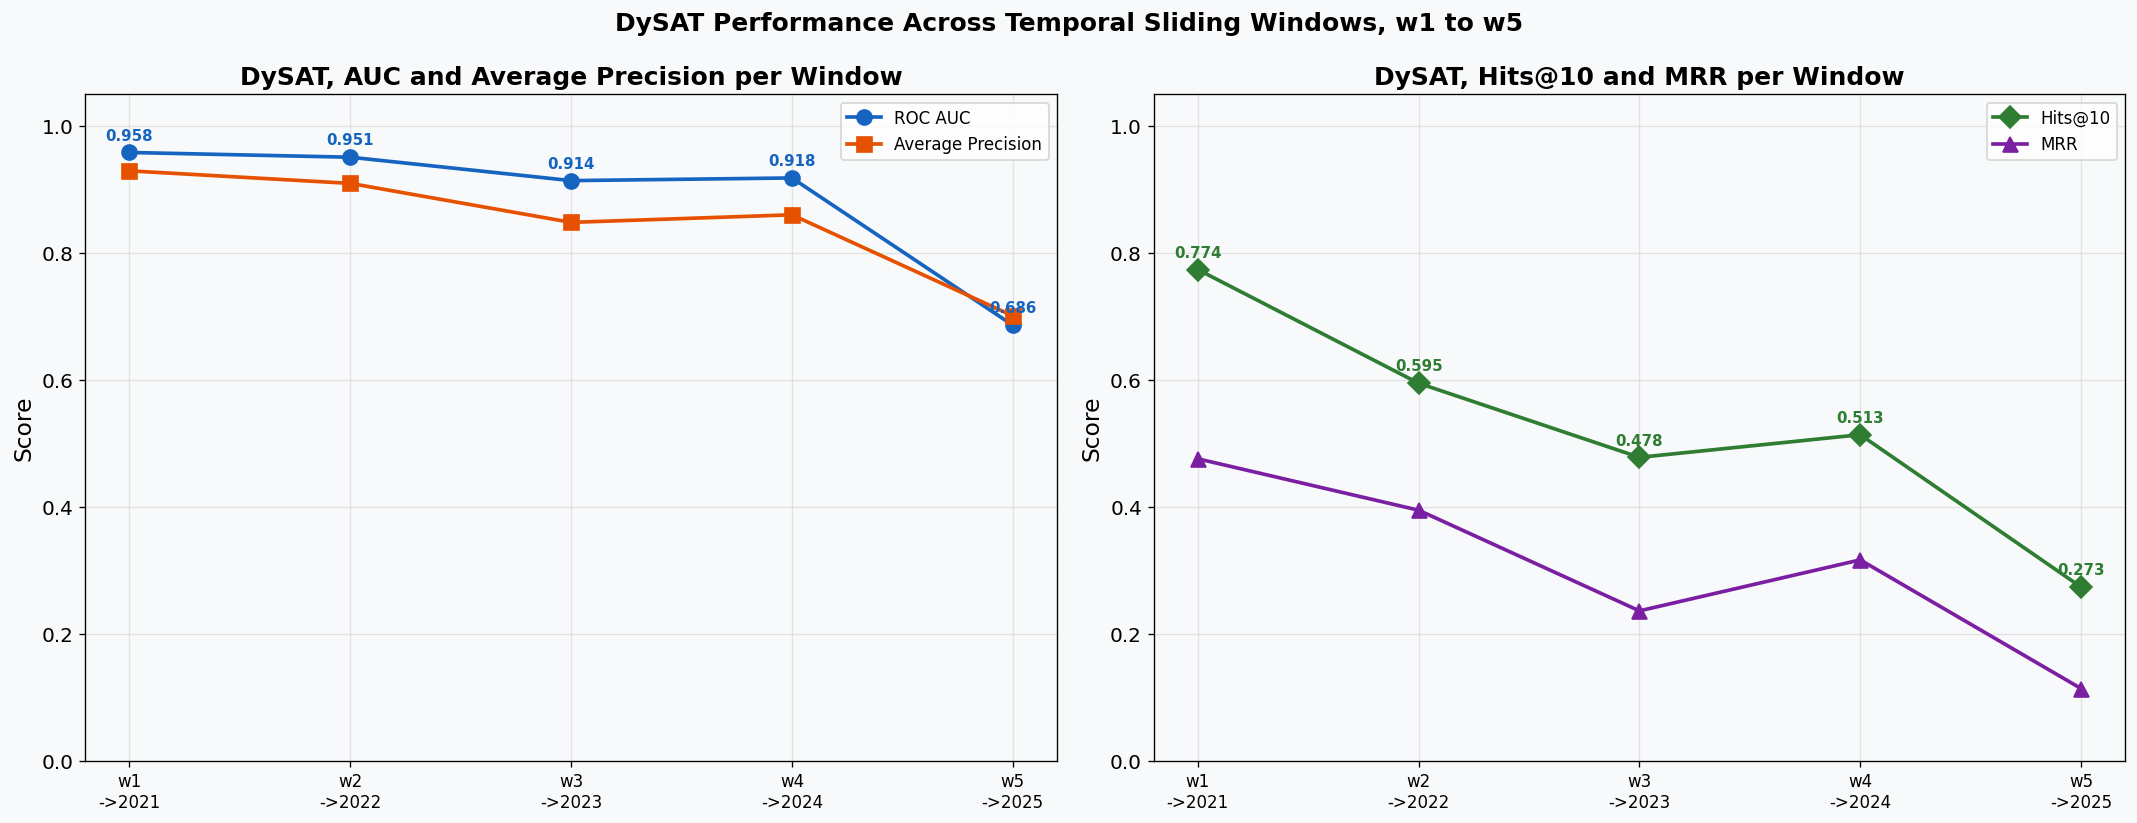

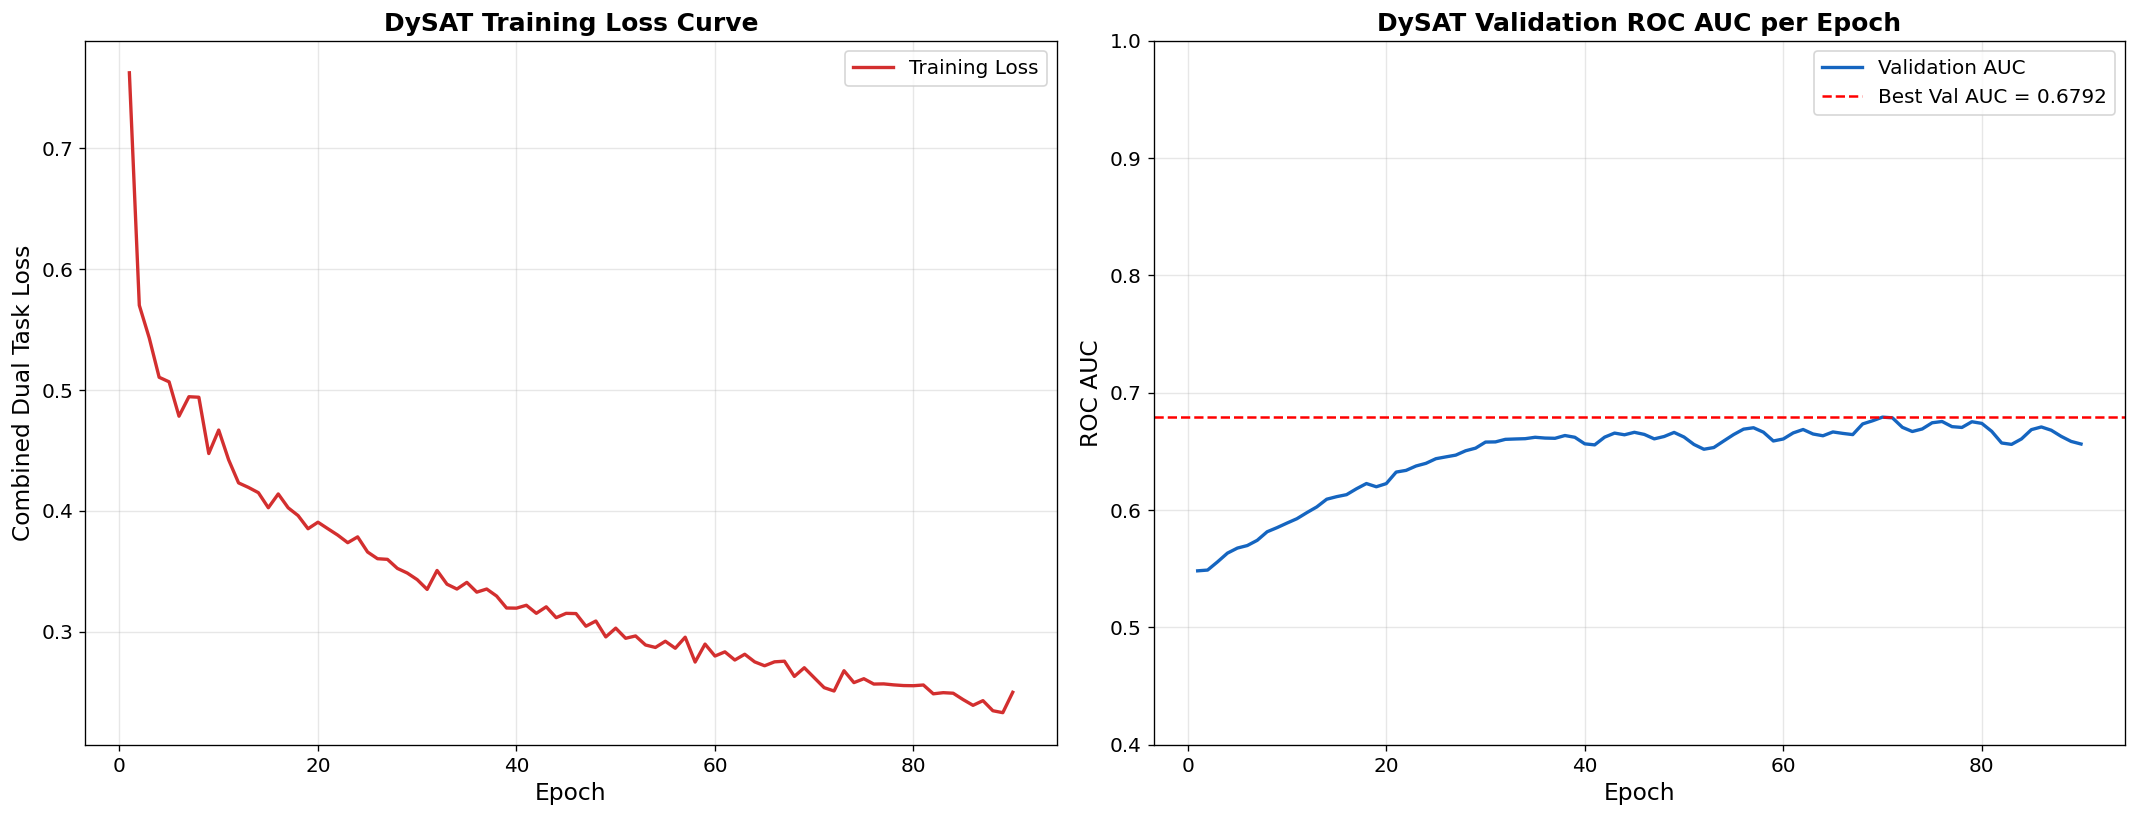

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#F8F9FA")
window_labels_pw = [f"{r['window']}\n->{r['target_year']}" for _, r in per_window_df.iterrows()]
x_pw = np.arange(len(per_window_df))

ax = axes[0]
ax.set_facecolor("#F8F9FA")
ax.plot(x_pw, per_window_df["auc"], marker="o", color="#1565C0", linewidth=2.2, markersize=9, label="ROC AUC")
ax.plot(x_pw, per_window_df["average_precision"], marker="s", color="#E65100", linewidth=2.2, markersize=9, label="Average Precision")
for xi, yi in zip(x_pw, per_window_df["auc"]):
    ax.text(xi, yi + 0.015, f"{yi:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#1565C0")
ax.set_xticks(x_pw); ax.set_xticklabels(window_labels_pw, fontsize=10)
ax.set_ylim(0.0, 1.05)
ax.set_title("DySAT, AUC and Average Precision per Window", fontweight="bold")
ax.set_ylabel("Score")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
ax.set_facecolor("#F8F9FA")
ax.plot(x_pw, per_window_df["hits_at_10"], marker="D", color="#2E7D32", linewidth=2.2, markersize=9, label="Hits@10")
ax.plot(x_pw, per_window_df["mrr"], marker="^", color="#7B1FA2", linewidth=2.2, markersize=9, label="MRR")
for xi, yi in zip(x_pw, per_window_df["hits_at_10"]):
    ax.text(xi, yi + 0.015, f"{yi:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#2E7D32")
ax.set_xticks(x_pw); ax.set_xticklabels(window_labels_pw, fontsize=10)
ax.set_ylim(0.0, 1.05)
ax.set_title("DySAT, Hits@10 and MRR per Window", fontweight="bold")
ax.set_ylabel("Score")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

fig.suptitle("DySAT Performance Across Temporal Sliding Windows, w1 to w5", fontsize=15, fontweight="bold")
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "dysat_per_window_performance.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "DySAT performance trend, AUC, AP, Hits at 10, MRR across temporal sliding windows")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
epochs_ran = list(range(1, len(train_loss_history) + 1))
axes[0].plot(epochs_ran, train_loss_history, color="#D32F2F", linewidth=2, label="Training Loss")
axes[0].set_title("DySAT Training Loss Curve", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Combined Dual Task Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs_ran, val_auc_history, color="#1565C0", linewidth=2, label="Validation AUC")
axes[1].axhline(best_val_auc, color="red", linestyle="--", linewidth=1.5, label=f"Best Val AUC = {best_val_auc:.4f}")
axes[1].set_title("DySAT Validation ROC AUC per Epoch", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC AUC")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.4, 1.0)
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "dysat_training_curve.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "DySAT training loss and validation AUC curves per epoch")
plt.show()

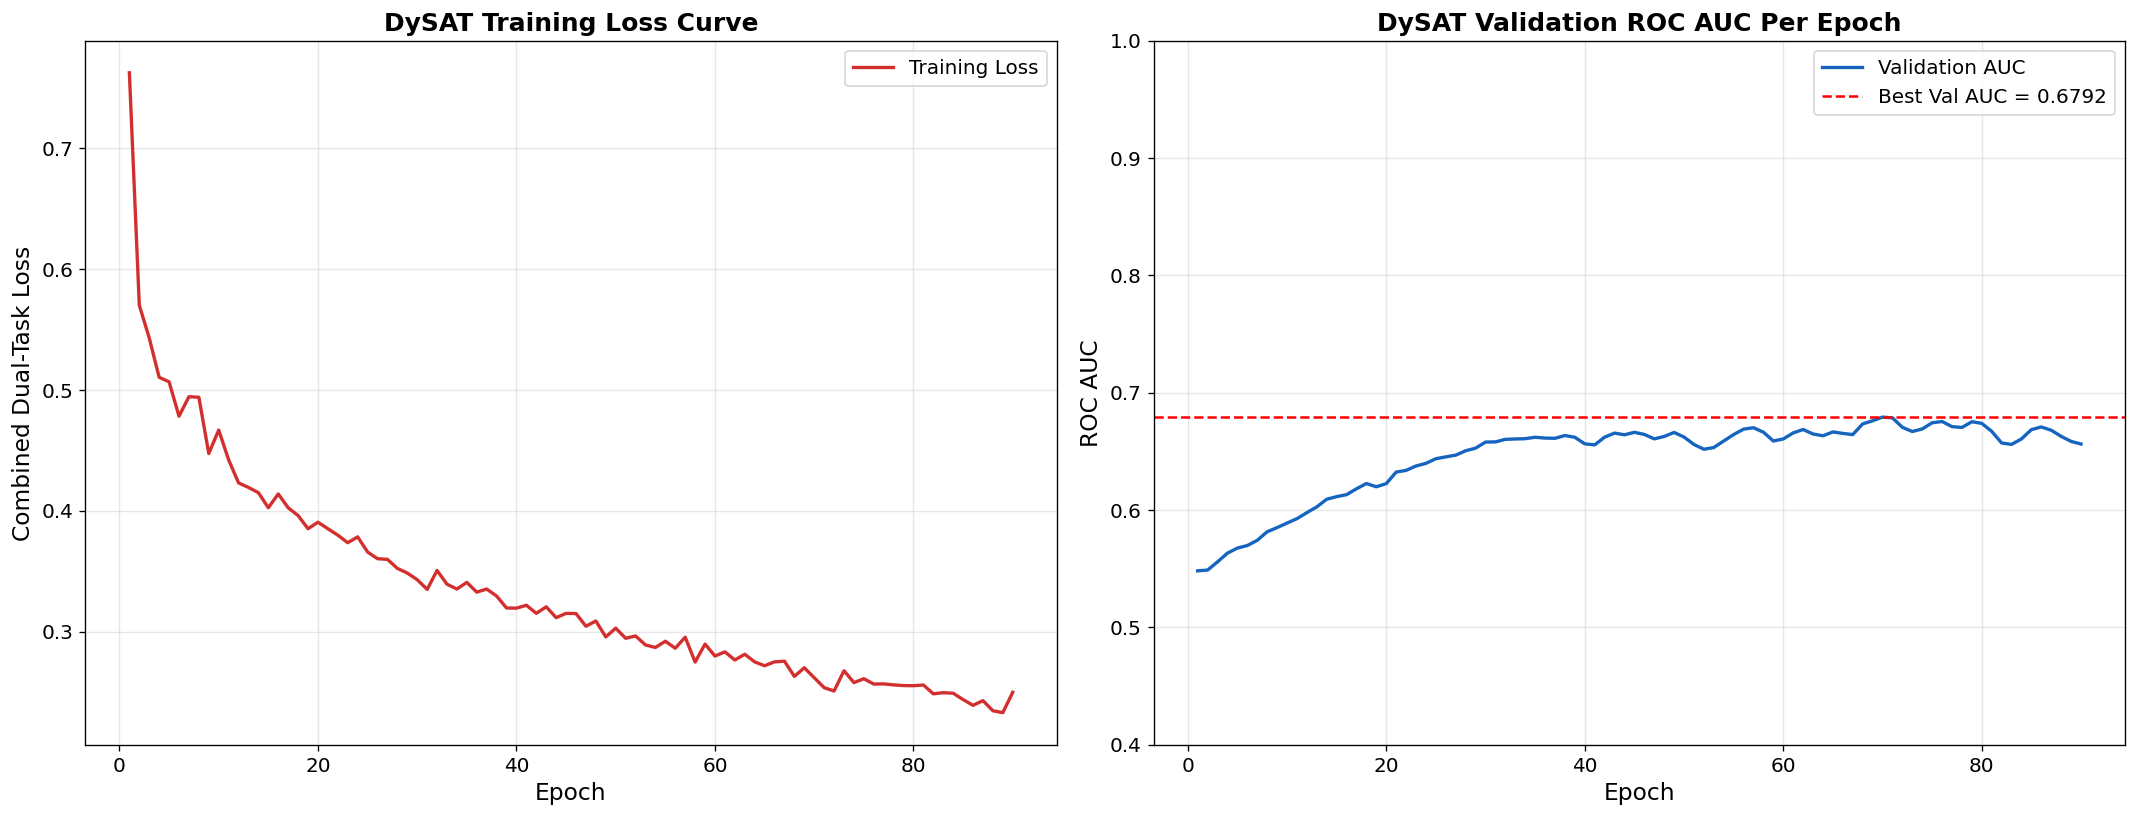

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
epochs_ran = list(range(1, len(train_loss_history) + 1))
axes[0].plot(epochs_ran, train_loss_history, color="#D32F2F", linewidth=2, label="Training Loss")
axes[0].set_title("DySAT Training Loss Curve", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Combined Dual-Task Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs_ran, val_auc_history, color="#1565C0", linewidth=2, label="Validation AUC")
axes[1].axhline(best_val_auc, color="red", linestyle="--", linewidth=1.5, label=f"Best Val AUC = {best_val_auc:.4f}")
axes[1].set_title("DySAT Validation ROC AUC Per Epoch", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC AUC")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.4, 1.0)
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "dysat_training_curve.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "DySAT training loss and validation AUC curves per epoch")
plt.show()

## Static GNN Baselines

Static VGAE with a GraphSAGE encoder is a homogeneous Author to Author baseline that does not see Paper or Topic nodes, useful as a contrast for the value of heterogeneous structure. Static Heterogeneous RGCN uses the same three relations as DySAT through two RGCN layers, giving it access to Paper and Topic context without any temporal mechanism. Both are trained on the final training window snapshot only, since they carry no state across snapshots, and both use the same optimizer, epoch budget, negative sampling ratio, and validation based early stopping as the temporal models for a fair comparison.

In [ ]:
last_wd_static = window_data_list[-1]
static_x = last_wd_static["author_features"].to(DEVICE)
static_ei = last_wd_static["edge_index"].to(DEVICE)
static_x_hetero = last_wd_static["x_hetero"].to(DEVICE)
static_edge_index_hetero = last_wd_static["edge_index_hetero"].to(DEVICE)
static_edge_type_hetero = last_wd_static["edge_type_hetero"].to(DEVICE)

test_pair_idx = torch.tensor([[author_id_to_index[a], author_id_to_index[b]] for a, b in test_pos_list + test_neg], dtype=torch.long)
test_labels_arr = np.array([1.0] * len(test_pos_list) + [0.0] * len(test_neg))
pos_train_pairs = list(last_wd_static["train_pair_set"])
pos_train_idx = torch.tensor([[author_id_to_index[a], author_id_to_index[b]] for a, b in pos_train_pairs], dtype=torch.long)
pos_train_intensity = torch.tensor(
    [min(last_wd_static["nx_coauthor"][a][b].get("weight", 1.0), INTENSITY_CAP) / INTENSITY_CAP for a, b in pos_train_pairs],
    dtype=torch.float32
)

target_pair_dict = last_wd_static["target_pair_dict"]
true_intensities_test = np.array([target_pair_dict.get(p, 0) for p in test_pos_list], dtype=np.float32)
true_norm = np.clip(true_intensities_test / INTENSITY_CAP, 0, 1)

class VGAEEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv_mu = SAGEConv(hidden_dim, hidden_dim)
        self.conv_logstd = SAGEConv(hidden_dim, hidden_dim)
    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        return self.conv_mu(h, edge_index), self.conv_logstd(h, edge_index)

class StaticVGAE(nn.Module):
    def __init__(self, in_dim, hidden_dim=128):
        super().__init__()
        self.encoder = VGAEEncoder(in_dim, hidden_dim)
        self.head = DeepTopoHead(hidden_dim, dropout=0.15)
    def encode(self, x, edge_index):
        mu, logstd = self.encoder(x, edge_index)
        logstd = logstd.clamp(-10, 10)
        z = mu + 0.05 * torch.randn_like(mu) * torch.exp(logstd) if self.training else mu
        return z, mu, logstd
    def decode(self, z, pair_indices, graph, raw_features):
        src = z[pair_indices[:, 0]]; dst = z[pair_indices[:, 1]]
        topo_feats = compute_ultra_pair_features(graph, pair_indices.cpu().numpy(), raw_features)
        probs, intensities = self.head(src, dst, topo_feats)
        return probs, intensities

class StaticHeteroRGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_relations=3, dropout=0.15):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.block1 = HeteroRelationalBlock(hidden_dim, hidden_dim, num_relations=num_relations, dropout=dropout)
        self.block2 = HeteroRelationalBlock(hidden_dim, hidden_dim, num_relations=num_relations, dropout=dropout)
        self.head = DeepTopoHead(hidden_dim, dropout=dropout)
    def forward(self, x_hetero, edge_index_hetero, edge_type_hetero, n_authors):
        h = F.elu(self.input_proj(x_hetero))
        h = self.block1(h, edge_index_hetero, edge_type_hetero)
        h = self.block2(h, edge_index_hetero, edge_type_hetero)
        return h[:n_authors]
    def decode(self, z, pair_indices, graph, raw_features):
        src = z[pair_indices[:, 0]]; dst = z[pair_indices[:, 1]]
        topo_feats = compute_ultra_pair_features(graph, pair_indices.cpu().numpy(), raw_features)
        probs, intensities = self.head(src, dst, topo_feats)
        return probs, intensities

def train_static_model_with_early_stopping(model_obj, forward_fn, name):
    opt = torch.optim.AdamW(model_obj.parameters(), lr=LEARNED_MODEL_LR, weight_decay=LEARNED_MODEL_WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=LEARNED_MODEL_EPOCHS, eta_min=1e-5)
    static_rng = np.random.default_rng(RANDOM_SEED)
    best_val_auc_s, patience_s, best_state_s = 0.0, 0, None
    for ep in range(LEARNED_MODEL_EPOCHS):
        model_obj.train()
        opt.zero_grad()
        z = forward_fn()
        neg_train_pairs = sample_negative_pairs(pos_train_pairs, last_wd_static["train_pair_set"],
                                                  len(pos_train_pairs) * NEG_RANDOM_MULTIPLIER,
                                                  int(len(pos_train_pairs) * NEG_HARD_MULTIPLIER), static_rng)
        neg_train_idx = torch.tensor([[author_id_to_index[a], author_id_to_index[b]] for a, b in neg_train_pairs], dtype=torch.long)
        p_idx = torch.cat([pos_train_idx, neg_train_idx], dim=0).to(DEVICE)
        labels = torch.tensor([1.0] * len(pos_train_pairs) + [0.0] * len(neg_train_pairs), device=DEVICE)
        intensity_targets = torch.cat([pos_train_intensity, torch.zeros(len(neg_train_pairs))], dim=0).to(DEVICE)
        scores, intensities = model_obj.decode(z, p_idx, nx_train_graph, last_wd_static["author_features"].numpy())
        bce = F.binary_cross_entropy(scores.clamp(1e-7, 1 - 1e-7), labels)
        mse = F.mse_loss(intensities, intensity_targets)
        loss = bce + LAMBDA_REG * mse
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_obj.parameters(), 1.0)
        opt.step()
        sched.step()
        model_obj.eval()
        with torch.no_grad():
            z_val = forward_fn()
            val_probs, _ = model_obj.decode(z_val, val_pair_idx.to(DEVICE), nx_train_graph, last_wd_static["author_features"].numpy())
            val_auc = roc_auc_score(val_labels.numpy(), val_probs.cpu().numpy()) if len(set(val_labels.numpy())) > 1 else 0.5
        if val_auc > best_val_auc_s:
            best_val_auc_s, patience_s = val_auc, 0
            best_state_s = {k: v.cpu().clone() for k, v in model_obj.state_dict().items()}
        else:
            patience_s += 1
        del z, neg_train_pairs, neg_train_idx, p_idx, labels, intensity_targets, scores, intensities, bce, mse, loss, z_val, val_probs
        free_memory()
        if patience_s >= LEARNED_MODEL_PATIENCE:
            print(f"{name} early stopping at epoch {ep+1}")
            break
    if best_state_s is not None:
        model_obj.load_state_dict(best_state_s)
    del opt, sched
    return best_val_auc_s

In [ ]:
rgcn = StaticHeteroRGCN(in_dim=IN_DIM, hidden_dim=128, num_relations=NUM_HETERO_RELATIONS).to(DEVICE)
describe_model(rgcn, "Static Heterogeneous RGCN")
rgcn_best_val_auc = train_static_model_with_early_stopping(
    rgcn, lambda: rgcn(static_x_hetero, static_edge_index_hetero, static_edge_type_hetero, N_AUTHORS), "Static Heterogeneous RGCN"
)

rgcn.eval()
with torch.no_grad():
    z_rgcn = rgcn(static_x_hetero, static_edge_index_hetero, static_edge_type_hetero, N_AUTHORS)
    rgcn_scores, rgcn_intensities = rgcn.decode(z_rgcn, test_pair_idx.to(DEVICE), nx_train_graph, last_wd_static["author_features"].numpy())
    rgcn_scores = rgcn_scores.cpu().numpy()
    rgcn_intensities = rgcn_intensities.cpu().numpy()
rgcn_metrics = evaluate_link_prediction(rgcn_scores[:len(test_pos_list)], rgcn_scores[len(test_pos_list):])
rgcn_reg = compute_regression_metrics(rgcn_intensities[:len(test_pos_list)], true_norm)
print(f"Static Heterogeneous RGCN: AUC={rgcn_metrics['auc']:.4f} AP={rgcn_metrics['average_precision']:.4f} best_val_auc={rgcn_best_val_auc:.4f}")
free_memory()

Arsitektur Model: Static Heterogeneous RGCN

StaticHeteroRGCN(
  (input_proj): Linear(in_features=452, out_features=128, bias=True)
  (block1): HeteroRelationalBlock(
    (conv): RGCNConv(128, 128, num_relations=3)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
    (proj): Identity()
  )
  (block2): HeteroRelationalBlock(
    (conv): RGCNConv(128, 128, num_relations=3)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
    (proj): Identity()
  )
  (head): DeepTopoHead(
    (link_mlp): Sequential(
      (0): Linear(in_features=519, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.15, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (6): GELU(approximate='none')


In [ ]:
vgae = StaticVGAE(in_dim=IN_DIM, hidden_dim=128).to(DEVICE)
describe_model(vgae, "Static VGAE (Homogeneous)")
vgae_best_val_auc = train_static_model_with_early_stopping(vgae, lambda: vgae.encode(static_x, static_ei)[0], "Static VGAE")

vgae.eval()
with torch.no_grad():
    z_vgae, _, _ = vgae.encode(static_x, static_ei)
    vgae_scores, vgae_intensities = vgae.decode(z_vgae, test_pair_idx.to(DEVICE), nx_train_graph, last_wd_static["author_features"].numpy())
    vgae_scores = vgae_scores.cpu().numpy()
    vgae_intensities = vgae_intensities.cpu().numpy()
vgae_metrics = evaluate_link_prediction(vgae_scores[:len(test_pos_list)], vgae_scores[len(test_pos_list):])
vgae_reg = compute_regression_metrics(vgae_intensities[:len(test_pos_list)], true_norm)
print(f"Static VGAE: AUC={vgae_metrics['auc']:.4f} AP={vgae_metrics['average_precision']:.4f} best_val_auc={vgae_best_val_auc:.4f}")
free_memory()

Arsitektur Model: Static VGAE (Homogeneous)

StaticVGAE(
  (encoder): VGAEEncoder(
    (conv1): SAGEConv(452, 128, aggr=mean)
    (conv_mu): SAGEConv(128, 128, aggr=mean)
    (conv_logstd): SAGEConv(128, 128, aggr=mean)
  )
  (head): DeepTopoHead(
    (link_mlp): Sequential(
      (0): Linear(in_features=519, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.15, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (6): GELU(approximate='none')
      (7): Dropout(p=0.15, inplace=False)
      (8): Linear(in_features=128, out_features=1, bias=True)
    )
    (intensity_mlp): Sequential(
      (0): Linear(in_features=519, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=128, out_features=1, bias=True)
      (3): Sigmoid()
    )
  )
)

Total paramet

## EvolveGCN (Temporal Comparison)

EvolveGCNO from PyTorch Geometric Temporal replaces a custom implementation. It processes snapshots strictly in chronological order and evolves its graph convolution weight with a GRU cell, so it is causal by construction with no masking needed. The same heterogeneous relational block used by DySAT enriches each snapshot with Paper and Topic context before the evolving convolution step. Training uses the same multi window supervision, optimizer, epoch budget, and early stopping protocol as DySAT for a fair temporal to temporal comparison.

In [ ]:
class EvolveGCNTemporal(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_relations=3, dropout=0.15):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.hetero_block = HeteroRelationalBlock(hidden_dim, hidden_dim, num_relations=num_relations, dropout=dropout)
        self.recurrent = EvolveGCNO(hidden_dim)
        self.head = DeepTopoHead(hidden_dim, dropout=dropout)
        self.hidden_dim = hidden_dim

    def forward(self, snapshot_list):
        self.recurrent.weight = None
        snapshot_embs = []
        for xh, eih, eth, eia, eaa, n_auth in snapshot_list:
            xh, eih, eth = xh.to(DEVICE), eih.to(DEVICE), eth.to(DEVICE)
            h = F.elu(self.input_proj(xh))
            h = self.hetero_block(h, eih, eth)
            h_author = h[:n_auth]
            edge_index_author = eia.to(DEVICE)
            edge_weight_author = eaa.to(DEVICE).squeeze(-1)
            h_author = self.recurrent(h_author, edge_index_author, edge_weight_author)
            snapshot_embs.append(h_author)
        return torch.stack(snapshot_embs, dim=1)

    def predict_pairs(self, node_embs, pair_indices, graph, raw_features):
        src = node_embs[pair_indices[:, 0]]
        dst = node_embs[pair_indices[:, 1]]
        topo_feats = compute_ultra_pair_features(graph, pair_indices.cpu().numpy(), raw_features)
        return self.head(src, dst, topo_feats)

evolvegcn = EvolveGCNTemporal(in_dim=IN_DIM, hidden_dim=128, num_relations=NUM_HETERO_RELATIONS).to(DEVICE)
describe_model(evolvegcn, "EvolveGCN-O (Heterogeneous, PyTorch Geometric Temporal)")
evolvegcn_opt = torch.optim.AdamW(evolvegcn.parameters(), lr=LEARNED_MODEL_LR, weight_decay=LEARNED_MODEL_WEIGHT_DECAY)
evolvegcn_sched = torch.optim.lr_scheduler.CosineAnnealingLR(evolvegcn_opt, T_max=LEARNED_MODEL_EPOCHS, eta_min=1e-5)
evo_rng = np.random.default_rng(RANDOM_SEED)

evo_best_val_auc, evo_patience, evo_best_state = 0.0, 0, None
for ep in range(LEARNED_MODEL_EPOCHS):
    evolvegcn.train()
    evolvegcn_opt.zero_grad()
    z_evo_all = evolvegcn(snapshot_list)
    loss_e = torch.tensor(0.0, device=DEVICE, requires_grad=True)
    n_used = 0
    for t, wd in enumerate(window_data_list[:-1]):
        target_dict = wd["target_pair_dict"]
        if not target_dict:
            continue
        pi, lt, it = prepare_supervision(wd, target_dict, evo_rng)
        if pi.shape[0] == 0:
            continue
        embs_t = z_evo_all[:, t, :]
        lp, ip = evolvegcn.predict_pairs(embs_t, pi.to(DEVICE), wd["nx_coauthor"], wd["author_features"].numpy())
        bce_e = F.binary_cross_entropy(lp.clamp(1e-7, 1 - 1e-7), lt.to(DEVICE))
        mse_e = F.mse_loss(ip, it.to(DEVICE))
        loss_e = loss_e + bce_e + LAMBDA_REG * mse_e
        n_used += 1
        del pi, lt, it, embs_t, lp, ip, bce_e, mse_e
    if n_used > 0:
        loss_e.backward()
        torch.nn.utils.clip_grad_norm_(evolvegcn.parameters(), 1.0)
        evolvegcn_opt.step()
    evolvegcn_sched.step()
    evolvegcn.eval()
    with torch.no_grad():
        z_evo_val = evolvegcn(snapshot_list)[:, -1, :]
        val_probs_e, _ = evolvegcn.predict_pairs(z_evo_val, val_pair_idx.to(DEVICE), nx_train_graph, last_wd["author_features"].numpy())
        val_auc_e = roc_auc_score(val_labels.numpy(), val_probs_e.cpu().numpy()) if len(set(val_labels.numpy())) > 1 else 0.5
    if val_auc_e > evo_best_val_auc:
        evo_best_val_auc, evo_patience = val_auc_e, 0
        evo_best_state = {k: v.cpu().clone() for k, v in evolvegcn.state_dict().items()}
    else:
        evo_patience += 1
    del z_evo_all, loss_e, z_evo_val, val_probs_e
    free_memory()
    if (ep + 1) % 10 == 0:
        print(f"  epoch {ep+1:3d}/{LEARNED_MODEL_EPOCHS} val_auc={val_auc_e:.4f} best={evo_best_val_auc:.4f}")
    if evo_patience >= LEARNED_MODEL_PATIENCE:
        print(f"EvolveGCN-O early stopping at epoch {ep+1}")
        break

if evo_best_state is not None:
    evolvegcn.load_state_dict(evo_best_state)
    print(f"restored best EvolveGCN-O model val_auc={evo_best_val_auc:.4f}")

evolvegcn.eval()
with torch.no_grad():
    z_evo_final = evolvegcn(snapshot_list)[:, -1, :]
    evolvegcn_scores, evolvegcn_intensities = evolvegcn.predict_pairs(z_evo_final, test_pair_idx.to(DEVICE), nx_train_graph,
                                                last_wd["author_features"].numpy())
    evolvegcn_scores = evolvegcn_scores.cpu().numpy()
    evolvegcn_intensities = evolvegcn_intensities.cpu().numpy()
evolvegcn_metrics = evaluate_link_prediction(evolvegcn_scores[:len(test_pos_list)], evolvegcn_scores[len(test_pos_list):])
evolvegcn_reg = compute_regression_metrics(evolvegcn_intensities[:len(test_pos_list)], true_norm)
print(f"EvolveGCN-O: AUC={evolvegcn_metrics['auc']:.4f} AP={evolvegcn_metrics['average_precision']:.4f}")

del evolvegcn_opt, evolvegcn_sched, evo_best_state
free_memory()

Arsitektur Model: EvolveGCN-O (Heterogeneous, PyTorch Geometric Temporal)

EvolveGCNTemporal(
  (input_proj): Linear(in_features=452, out_features=128, bias=True)
  (hetero_block): HeteroRelationalBlock(
    (conv): RGCNConv(128, 128, num_relations=3)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
    (proj): Identity()
  )
  (recurrent): EvolveGCNO(
    (recurrent_layer): GRU(128, 128)
    (conv_layer): GCNConv_Fixed_W(128, 128)
  )
  (head): DeepTopoHead(
    (link_mlp): Sequential(
      (0): Linear(in_features=519, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.15, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (6): GELU(approximate='none')
      (7): Dropout(p=0.15, inplace=False)
      (8): Linear(in_features=1

## Additional Temporal GNN Comparators Selected from the DGNN Survey

DySAT and EvolveGCN-O are both discrete snapshot models. Following the comprehensive taxonomy and benchmarking dimensions in Feng et al., *A Comprehensive Survey of Dynamic Graph Neural Networks: Models, Frameworks, Benchmarks, Experiments, and Challenges* (IEEE TKDE, vol. 38, no. 1, 2026), two additional representative architectures are evaluated:

- **ROLAND (Discrete-Time Dynamic GNN)**: Reuses the multi-relational heterogeneous front-end and edge-weighted spatial GAT layers. Rather than simple state replacement, it implements ROLAND's true hierarchical node state updating mechanism (You et al., KDD 2022) with residual skip-connections and layer normalization across snapshots: $H_t^{(l)} = \text{LayerNorm}(G_t^{(l)} + \text{GRUCell}(G_t^{(l)}, H_{t-1}^{(l)}))$. This preserves local spatial topology while transferring long-term historical states without gradient saturation.
- **TGN (Continuous-Time Dynamic GNN)**: Serves as the continuous event-driven representative (Rossi et al., 2020). Interactions are processed chronologically at event resolution with 384D paper embeddings as edge messages.

In [ ]:
import time

def count_parameters(module_obj):
    return int(sum(p.numel() for p in module_obj.parameters() if p.requires_grad))

def sync_gpu():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def gpu_peak_reset():
    sync_gpu()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        return int(torch.cuda.memory_allocated())
    return 0

def gpu_peak_read_mb(baseline_bytes):
    sync_gpu()
    if torch.cuda.is_available():
        return float(max(torch.cuda.max_memory_allocated() - baseline_bytes, 0) / (1024 ** 2))
    return 0.0

def set_global_seed(seed_val):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_val)

def score_and_package(model_obj, z_final):
    n_pos = len(test_pos_list)
    with torch.no_grad():
        probs, intens = model_obj.predict_pairs(z_final, test_pair_idx.to(DEVICE), nx_train_graph, last_wd["author_features"].numpy())
    probs_np = probs.cpu().numpy()
    intens_np = intens.cpu().numpy()
    class_metrics = evaluate_link_prediction(probs_np[:n_pos], probs_np[n_pos:])
    reg_metrics = compute_regression_metrics(intens_np[:n_pos], true_norm)
    return probs_np, intens_np, class_metrics, reg_metrics

def package_result(label, seed_val, model_obj, z_final, loss_history, val_history, best_val, train_seconds, peak_mb, n_params):
    probs_np, intens_np, class_metrics, reg_metrics = score_and_package(model_obj, z_final)
    epochs_run = len(val_history)
    return {
        "label": label, "seed": seed_val, "model_obj": model_obj, "z_final": z_final,
        "scores": probs_np, "intensities": intens_np,
        "class_metrics": class_metrics, "reg_metrics": reg_metrics,
        "loss_history": loss_history, "val_history": val_history, "best_val_auc": best_val,
        "epochs_run": epochs_run, "train_seconds": train_seconds,
        "sec_per_epoch": train_seconds / max(epochs_run, 1),
        "peak_mem_mb": peak_mb, "params": n_params,
    }

class RolandTemporal(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_relations=3, n_spatial_layers=2, dropout=0.15):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.hetero_block = HeteroRelationalBlock(hidden_dim, hidden_dim, num_relations=num_relations, dropout=dropout)
        self.spatial_layers = nn.ModuleList([
            EdgeWeightedGATBlock(hidden_dim, hidden_dim, heads=4, dropout=dropout) for _ in range(n_spatial_layers)
        ])
        self.state_updaters = nn.ModuleList([nn.GRUCell(hidden_dim, hidden_dim) for _ in range(n_spatial_layers)])
        self.layer_norms = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(n_spatial_layers)])
        self.norm_final = nn.LayerNorm(hidden_dim)
        self.head = DeepTopoHead(hidden_dim, dropout=dropout)
        self.hidden_dim = hidden_dim

    def forward(self, snapshot_list):
        layer_states = [None] * len(self.spatial_layers)
        outputs = []
        for xh, eih, eth, eia, eaa, n_auth in snapshot_list:
            xh, eih, eth = xh.to(DEVICE), eih.to(DEVICE), eth.to(DEVICE)
            eia, eaa = eia.to(DEVICE), eaa.to(DEVICE)
            h = F.elu(self.input_proj(xh))
            h = self.hetero_block(h, eih, eth)[:n_auth]
            for layer_idx, (layer, updater, ln) in enumerate(zip(self.spatial_layers, self.state_updaters, self.layer_norms)):
                g = layer(h, eia, eaa)
                prev_state = layer_states[layer_idx] if layer_states[layer_idx] is not None else torch.zeros_like(g)
                u = updater(g, prev_state)
                h = ln(g + u)
                layer_states[layer_idx] = h
            outputs.append(self.norm_final(h))
        return torch.stack(outputs, dim=1)

    def predict_pairs(self, node_embs, pair_indices, graph, raw_features):
        src = node_embs[pair_indices[:, 0]]
        dst = node_embs[pair_indices[:, 1]]
        topo_feats = compute_ultra_pair_features(graph, pair_indices.cpu().numpy(), raw_features)
        return self.head(src, dst, topo_feats)

def run_snapshot_experiment(build_fn, seed_val, label, verbose=False):
    set_global_seed(seed_val)
    baseline_bytes = gpu_peak_reset()
    model_obj = build_fn().to(DEVICE)
    n_params = count_parameters(model_obj)
    opt = torch.optim.AdamW(model_obj.parameters(), lr=LEARNED_MODEL_LR, weight_decay=LEARNED_MODEL_WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=LEARNED_MODEL_EPOCHS, eta_min=1e-5)
    fit_rng = np.random.default_rng(seed_val)
    best_val, patience, best_state = 0.0, 0, None
    loss_history, val_history = [], []
    last_author_features = last_wd["author_features"].numpy()
    t_start = time.perf_counter()
    for ep in range(LEARNED_MODEL_EPOCHS):
        model_obj.train()
        opt.zero_grad()
        embs_all = model_obj(snapshot_list)
        loss_total = 0.0
        n_used = 0
        for win_t, wd in enumerate(window_data_list[:-1]):
            if not wd["target_pair_dict"]:
                continue
            pi, lt, it = prepare_supervision(wd, wd["target_pair_dict"], fit_rng)
            if pi.shape[0] == 0:
                continue
            lp, ip = model_obj.predict_pairs(embs_all[:, win_t, :], pi.to(DEVICE), wd["nx_coauthor"], wd["author_features"].numpy())
            loss_window = F.binary_cross_entropy(lp.clamp(1e-7, 1 - 1e-7), lt.to(DEVICE)) + LAMBDA_REG * F.mse_loss(ip, it.to(DEVICE))
            loss_total = loss_total + loss_window
            n_used += 1
        if n_used > 0:
            loss_norm = loss_total / n_used
            loss_norm.backward()
            torch.nn.utils.clip_grad_norm_(model_obj.parameters(), 1.0)
            opt.step()
            loss_value = float(loss_norm.item())
        else:
            loss_value = 0.0
        sched.step()
        model_obj.eval()
        with torch.no_grad():
            z_val = model_obj(snapshot_list)[:, -1, :]
            val_probs, _ = model_obj.predict_pairs(z_val, val_pair_idx.to(DEVICE), nx_train_graph, last_author_features)
            val_auc = float(roc_auc_score(val_labels.numpy(), val_probs.cpu().numpy()))
        loss_history.append(loss_value)
        val_history.append(val_auc)
        if val_auc > best_val:
            best_val, patience = val_auc, 0
            best_state = {k: v.cpu().clone() for k, v in model_obj.state_dict().items()}
        else:
            patience += 1
        del embs_all, z_val, val_probs
        if (ep + 1) % 20 == 0:
            free_memory()
        if verbose and (ep + 1) % 10 == 0:
            print(f"  epoch {ep + 1:3d}/{LEARNED_MODEL_EPOCHS} loss={loss_value:.4f} val_auc={val_auc:.4f} best={best_val:.4f}")
        if patience >= LEARNED_MODEL_PATIENCE:
            if verbose:
                print(f"{label} early stopping at epoch {ep + 1}")
            break
    sync_gpu()
    train_seconds = time.perf_counter() - t_start
    if best_state is not None:
        model_obj.load_state_dict(best_state)
    model_obj.eval()
    with torch.no_grad():
        z_final = model_obj(snapshot_list)[:, -1, :]
    peak_mb = gpu_peak_read_mb(baseline_bytes)
    del opt, sched, best_state
    return package_result(label, seed_val, model_obj, z_final, loss_history, val_history, best_val, train_seconds, peak_mb, n_params)

roland_result = run_snapshot_experiment(
    lambda: RolandTemporal(in_dim=IN_DIM, hidden_dim=128, num_relations=NUM_HETERO_RELATIONS, n_spatial_layers=2, dropout=0.15),
    RANDOM_SEED, "ROLAND (Temporal)", verbose=True,
)
describe_model(roland_result["model_obj"], "ROLAND (Heterogeneous front-end, GRU hierarchical state update)")

roland_scores = roland_result["scores"]
roland_intensities = roland_result["intensities"]
roland_metrics = roland_result["class_metrics"]
roland_reg = roland_result["reg_metrics"]
print(f"ROLAND: AUC={roland_metrics['auc']:.4f} AP={roland_metrics['average_precision']:.4f} "
      f"Hits@10={roland_metrics['hits_at_10']:.4f} MRR={roland_metrics['mrr']:.4f} "
      f"best_val_auc={roland_result['best_val_auc']:.4f} epochs={roland_result['epochs_run']} "
      f"sec/epoch={roland_result['sec_per_epoch']:.3f} peak_mem={roland_result['peak_mem_mb']:.1f}MB")
free_memory()

  epoch  10/150 loss=0.4854 val_auc=0.5685 best=0.5784
  epoch  20/150 loss=0.4184 val_auc=0.6048 best=0.6048
  epoch  30/150 loss=0.3617 val_auc=0.6219 best=0.6284
  epoch  40/150 loss=0.3359 val_auc=0.6239 best=0.6284
  epoch  50/150 loss=0.3134 val_auc=0.6278 best=0.6294
  epoch  60/150 loss=0.2915 val_auc=0.6380 best=0.6391
  epoch  70/150 loss=0.2685 val_auc=0.6615 best=0.6615
  epoch  80/150 loss=0.2516 val_auc=0.6704 best=0.6708
  epoch  90/150 loss=0.2486 val_auc=0.6752 best=0.6778
  epoch 100/150 loss=0.2246 val_auc=0.6794 best=0.6794
  epoch 110/150 loss=0.2142 val_auc=0.6738 best=0.6800
  epoch 120/150 loss=0.2098 val_auc=0.6788 best=0.6800
ROLAND (Temporal) early stopping at epoch 121
Arsitektur Model: ROLAND (Heterogeneous front-end, GRU hierarchical state update)

RolandTemporal(
  (input_proj): Linear(in_features=452, out_features=128, bias=True)
  (hetero_block): HeteroRelationalBlock(
    (conv): RGCNConv(128, 128, num_relations=3)
    (norm): LayerNorm((128,), eps=1e-

## DySAT Final Evaluation on Test Set

In [ ]:
model.eval()
with torch.no_grad():
    final_embs_test = model(snapshot_list)[:, -1, :]
    test_probs_dysat, test_intensities_dysat = model.predict_pairs(final_embs_test, test_pair_idx.to(DEVICE), nx_train_graph, last_wd["author_features"].numpy())
    test_probs_np = test_probs_dysat.cpu().numpy()
    test_intensities_np = test_intensities_dysat.cpu().numpy()

dysat_class_metrics = evaluate_link_prediction(test_probs_np[:len(test_pos_list)], test_probs_np[len(test_pos_list):])
dysat_reg_metrics = compute_regression_metrics(test_intensities_np[:len(test_pos_list)], true_norm)

print("DySAT Test Results:")
for k, v in dysat_class_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"  rmse: {dysat_reg_metrics['rmse']:.4f}")
print(f"  mae:  {dysat_reg_metrics['mae']:.4f}")

DySAT Test Results:
  auc: 0.6860
  average_precision: 0.7008
  hits_at_10: 0.2734
  mrr: 0.1135
  rmse: 0.2292
  mae:  0.1815


### TGN as the Continuous-Time Representative

The coauthorship records are converted into a chronological event stream: one event per author pair per paper, timestamped at year-level resolution (scaled to elapsed days), with the 384D paper embedding acting as the edge message.

Events are consumed chronologically in temporal batches:
1. **Memory & State Evolution**: For each target year $y$, TGN queries its internal memory state accumulated strictly from events prior to $y$ ($t \le y - 1$), combining it with the static author profile to compute node embeddings $z(t)$.
2. **Supervision Alignment**: Predictions for year $y$ are evaluated against held-out positive and hard negative pairs before events of year $y$ are ingested into memory, completely eliminating target leakage.
3. **Inference on Held-Out Test Split**: At test time, memory is updated with all events through 2024, and predictions are generated for the 2025 link prediction benchmark using the shared deep topological decoder head.


In [ ]:
from torch_geometric.nn import TGNMemory, TransformerConv
from torch_geometric.nn.models.tgn import IdentityMessage, MeanAggregator, LastNeighborLoader

TGN_FIRST_YEAR = SLIDING_WINDOWS[0]["train_years"][0]
TGN_LAST_YEAR = SLIDING_WINDOWS[-1]["train_years"][1]
TGN_YEARS = list(range(TGN_FIRST_YEAR, TGN_LAST_YEAR + 1))
TGN_HIDDEN_DIM = 128
TGN_TIME_DIM = 32
TGN_NEIGHBORS = 25
TGN_EVENT_BATCH = 200
TGN_DAYS_PER_YEAR = 365

event_records = []
event_source_df = clean_papers_df[(clean_papers_df["year"] >= TGN_FIRST_YEAR) & (clean_papers_df["year"] <= TGN_LAST_YEAR)]
for _, paper_row in event_source_df.iterrows():
    paper_gidx = paper_idx_lookup.get(paper_row["paper_id"])
    member_ids = sorted(set(paper_row["author_id_list"]))
    if paper_gidx is None or len(member_ids) < 2:
        continue
    for a, b in itertools.combinations(member_ids, 2):
        event_records.append((author_id_to_index[a], author_id_to_index[b], int(paper_row["year"]), paper_gidx))

tgn_event_df = pd.DataFrame(event_records, columns=["src", "dst", "year", "gidx"]).sort_values("year", kind="stable").reset_index(drop=True)
tgn_year_values = tgn_event_df["year"].values
TGN_YEAR_SLICES = {
    y: (int(np.searchsorted(tgn_year_values, y, side="left")), int(np.searchsorted(tgn_year_values, y, side="right")))
    for y in TGN_YEARS
}
TGN_SRC = torch.tensor(tgn_event_df["src"].values, dtype=torch.long, device=DEVICE)
TGN_DST = torch.tensor(tgn_event_df["dst"].values, dtype=torch.long, device=DEVICE)
TGN_T = torch.tensor((tgn_event_df["year"].values - TGN_FIRST_YEAR) * TGN_DAYS_PER_YEAR, dtype=torch.long, device=DEVICE)
TGN_MSG = torch.tensor(paper_embeddings[tgn_event_df["gidx"].values], dtype=torch.float32, device=DEVICE)
TGN_MSG_DIM = int(TGN_MSG.shape[1])
TGN_ALL_NODES = torch.arange(N_AUTHORS, device=DEVICE)
TGN_WINDOW_BY_TARGET = {wd["target_year"]: wd for wd in window_data_list[:-1]}

print(tgn_event_df.groupby("year").size().rename("n_events").reset_index().to_string(index=False))
print(f"total events: {len(tgn_event_df)} | edge message dim: {TGN_MSG_DIM}")

class TGNGraphAttention(nn.Module):
    def __init__(self, hidden_dim, msg_dim, time_enc, heads=2, dropout=0.15):
        super().__init__()
        self.time_enc = time_enc
        edge_dim = msg_dim + time_enc.out_channels
        self.conv = TransformerConv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout, edge_dim=edge_dim)

    def forward(self, x, last_update, edge_index, t, msg):
        rel_t = last_update[edge_index[0]] - t
        rel_t_enc = self.time_enc(rel_t.to(x.dtype))
        edge_attr = torch.cat([rel_t_enc, msg], dim=-1)
        return self.conv(x, edge_index, edge_attr)

class TGNLinkModel(nn.Module):
    def __init__(self, num_nodes, msg_dim, in_dim=IN_DIM, hidden_dim=128, time_dim=32, neighbor_size=25, dropout=0.15):
        super().__init__()
        self.node_proj = nn.Linear(in_dim, hidden_dim)
        self.norm_in = nn.LayerNorm(hidden_dim)
        self.memory = TGNMemory(
            num_nodes, msg_dim, hidden_dim, time_dim,
            message_module=IdentityMessage(msg_dim, hidden_dim, time_dim),
            aggregator_module=MeanAggregator(),
        )
        self.embedding = TGNGraphAttention(hidden_dim, msg_dim, self.memory.time_enc, heads=2, dropout=dropout)
        self.norm = nn.LayerNorm(hidden_dim)
        self.head = DeepTopoHead(hidden_dim, dropout=dropout)
        self.neighbor_loader = LastNeighborLoader(num_nodes, size=neighbor_size, device=DEVICE)
        self.hidden_dim = hidden_dim

    def reset_state(self):
        self.memory.reset_state()
        self.neighbor_loader.reset_state()

    def consume_year(self, year_value):
        s, e = TGN_YEAR_SLICES[year_value]
        if s >= e:
            return
        with torch.no_grad():
            for start in range(s, e, TGN_EVENT_BATCH):
                stop = min(start + TGN_EVENT_BATCH, e)
                src, dst = TGN_SRC[start:stop], TGN_DST[start:stop]
                self.memory.update_state(src, dst, TGN_T[start:stop], TGN_MSG[start:stop])
                self.neighbor_loader.insert(src, dst)

    def embed_all(self, author_features_tensor):
        n_id, edge_index, e_id = self.neighbor_loader(TGN_ALL_NODES)
        mem, last_update = self.memory(n_id)
        x_init = F.elu(self.node_proj(author_features_tensor))
        x_fused = self.norm_in(x_init + mem)
        z = self.embedding(x_fused, last_update, edge_index, TGN_T[e_id], TGN_MSG[e_id])
        return self.norm(z + x_fused)

    def predict_pairs(self, node_embs, pair_indices, graph, raw_features):
        src = node_embs[pair_indices[:, 0]]
        dst = node_embs[pair_indices[:, 1]]
        topo_feats = compute_ultra_pair_features(graph, pair_indices.cpu().numpy(), raw_features)
        return self.head(src, dst, topo_feats)

def tgn_train_epoch(tgn_obj, opt, epoch_rng, author_features_tensor):
    tgn_obj.train()
    tgn_obj.reset_state()
    opt.zero_grad()
    loss_sum, n_used = 0.0, 0
    valid_years = [y for y in TGN_YEARS if TGN_WINDOW_BY_TARGET.get(y) and TGN_WINDOW_BY_TARGET.get(y)["target_pair_dict"]]
    n_targets = max(len(valid_years), 1)

    for year_value in TGN_YEARS:
        wd = TGN_WINDOW_BY_TARGET.get(year_value)
        if wd is not None and wd["target_pair_dict"]:
            pi, lt, it = prepare_supervision(wd, wd["target_pair_dict"], epoch_rng)
            if pi.shape[0] > 0:
                z_all = tgn_obj.embed_all(author_features_tensor)
                lp, ip = tgn_obj.predict_pairs(z_all, pi.to(DEVICE), wd["nx_coauthor"], wd["author_features"].numpy())
                loss_y = F.binary_cross_entropy(lp.clamp(1e-7, 1 - 1e-7), lt.to(DEVICE)) + LAMBDA_REG * F.mse_loss(ip, it.to(DEVICE))
                (loss_y / n_targets).backward()
                loss_sum += float(loss_y.item())
                n_used += 1
                del z_all, lp, ip, loss_y
        tgn_obj.consume_year(year_value)

    if n_used > 0:
        torch.nn.utils.clip_grad_norm_(tgn_obj.parameters(), 1.0)
        opt.step()
        return loss_sum / n_used
    return 0.0

def tgn_eval_embeddings(tgn_obj, author_features_tensor):
    with torch.no_grad():
        tgn_obj.eval()
        tgn_obj.reset_state()
        for year_value in TGN_YEARS:
            tgn_obj.consume_year(year_value)
        return tgn_obj.embed_all(author_features_tensor)

def run_tgn_experiment(build_fn, seed_val, label, verbose=False):
    set_global_seed(seed_val)
    baseline_bytes = gpu_peak_reset()
    tgn_obj = build_fn().to(DEVICE)
    n_params = count_parameters(tgn_obj)
    opt = torch.optim.AdamW(tgn_obj.parameters(), lr=LEARNED_MODEL_LR, weight_decay=LEARNED_MODEL_WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=LEARNED_MODEL_EPOCHS, eta_min=1e-5)
    fit_rng = np.random.default_rng(seed_val)
    best_val, patience, best_state = 0.0, 0, None
    loss_history, val_history = [], []
    last_author_features = last_wd["author_features"].numpy()
    author_features_tensor = last_wd["author_features"].to(DEVICE)
    t_start = time.perf_counter()

    for ep in range(LEARNED_MODEL_EPOCHS):
        loss_value = tgn_train_epoch(tgn_obj, opt, fit_rng, author_features_tensor)
        sched.step()
        z_val = tgn_eval_embeddings(tgn_obj, author_features_tensor)
        with torch.no_grad():
            val_probs, _ = tgn_obj.predict_pairs(z_val, val_pair_idx.to(DEVICE), nx_train_graph, last_author_features)
            val_auc = float(roc_auc_score(val_labels.numpy(), val_probs.cpu().numpy()))
        loss_history.append(loss_value)
        val_history.append(val_auc)
        if val_auc > best_val:
            best_val, patience = val_auc, 0
            best_state = {k: v.cpu().clone() for k, v in tgn_obj.state_dict().items()}
        else:
            patience += 1
        del z_val, val_probs
        if (ep + 1) % 20 == 0:
            free_memory()
        if verbose and (ep + 1) % 10 == 0:
            print(f"  epoch {ep + 1:3d}/{LEARNED_MODEL_EPOCHS} loss={loss_value:.4f} val_auc={val_auc:.4f} best={best_val:.4f}")
        if patience >= LEARNED_MODEL_PATIENCE:
            if verbose:
                print(f"{label} early stopping at epoch {ep + 1}")
            break

    sync_gpu()
    train_seconds = time.perf_counter() - t_start
    if best_state is not None:
        tgn_obj.load_state_dict(best_state)
    z_final = tgn_eval_embeddings(tgn_obj, author_features_tensor)
    peak_mb = gpu_peak_read_mb(baseline_bytes)
    del opt, sched, best_state
    return package_result(label, seed_val, tgn_obj, z_final, loss_history, val_history, best_val, train_seconds, peak_mb, n_params)

tgn_result = run_tgn_experiment(
    lambda: TGNLinkModel(N_AUTHORS, TGN_MSG_DIM, in_dim=IN_DIM, hidden_dim=TGN_HIDDEN_DIM, time_dim=TGN_TIME_DIM, neighbor_size=TGN_NEIGHBORS, dropout=0.15),
    RANDOM_SEED, "TGN (Continuous-Time)", verbose=True,
)
describe_model(tgn_result["model_obj"], "TGN (Feature-Fused Memory, Mean Aggregator, Temporal Graph Attention)")

tgn_scores = tgn_result["scores"]
tgn_intensities = tgn_result["intensities"]
tgn_metrics = tgn_result["class_metrics"]
tgn_reg = tgn_result["reg_metrics"]
print(f"TGN: AUC={tgn_metrics['auc']:.4f} AP={tgn_metrics['average_precision']:.4f} "
      f"Hits@10={tgn_metrics['hits_at_10']:.4f} MRR={tgn_metrics['mrr']:.4f} "
      f"best_val_auc={tgn_result['best_val_auc']:.4f} epochs={tgn_result['epochs_run']} "
      f"sec/epoch={tgn_result['sec_per_epoch']:.3f} peak_mem={tgn_result['peak_mem_mb']:.1f}MB")
free_memory()

 year  n_events
 2018       157
 2019        75
 2020       248
 2021       405
 2022       402
 2023       399
 2024       567
total events: 2253 | edge message dim: 384
  epoch  10/150 loss=0.4485 val_auc=0.5324 best=0.5330
  epoch  20/150 loss=0.4019 val_auc=0.5742 best=0.5742
  epoch  30/150 loss=0.3976 val_auc=0.5899 best=0.5899
  epoch  40/150 loss=0.3285 val_auc=0.6083 best=0.6083
  epoch  50/150 loss=0.2866 val_auc=0.6114 best=0.6146
  epoch  60/150 loss=0.2384 val_auc=0.6286 best=0.6302
  epoch  70/150 loss=0.2062 val_auc=0.6237 best=0.6304
  epoch  80/150 loss=0.1860 val_auc=0.6160 best=0.6304
TGN (Continuous-Time) early stopping at epoch 81
Arsitektur Model: TGN (Feature-Fused Memory, Mean Aggregator, Temporal Graph Attention)

TGNLinkModel(
  (node_proj): Linear(in_features=452, out_features=128, bias=True)
  (norm_in): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (memory): TGNMemory(
    (msg_s_module): IdentityMessage()
    (msg_d_module): IdentityMessage()
   

### Seed Stability Analysis

Three independent seeds are used to train DySAT. Mean and standard deviation of AUC across seeds quantifies the robustness of the learned representations.

In [ ]:
STABILITY_SEEDS = [42, 123, 2026]
stability_rows = []
for seed_val in STABILITY_SEEDS:
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)
    seed_model = DySATModel(in_dim=IN_DIM, hidden_dim=128, num_relations=NUM_HETERO_RELATIONS,
                             n_spatial_layers=2, n_temporal_heads=4, dropout=0.15).to(DEVICE)
    seed_opt = torch.optim.AdamW(seed_model.parameters(), lr=LEARNED_MODEL_LR, weight_decay=LEARNED_MODEL_WEIGHT_DECAY)
    seed_sched = torch.optim.lr_scheduler.CosineAnnealingLR(seed_opt, T_max=LEARNED_MODEL_EPOCHS, eta_min=1e-5)
    seed_rng = np.random.default_rng(seed_val)

    seed_best_val_auc, seed_patience, seed_best_state = 0.0, 0, None
    for ep in range(LEARNED_MODEL_EPOCHS):
        seed_model.train()
        embs_s_all = seed_model(snapshot_list)
        loss_s = torch.tensor(0.0, device=DEVICE, requires_grad=True)
        n_used = 0
        for t, wd in enumerate(window_data_list[:-1]):
            if not wd["target_pair_dict"]:
                continue
            pi, lt, it = prepare_supervision(wd, wd["target_pair_dict"], seed_rng)
            if pi.shape[0] == 0:
                continue
            embs_t = embs_s_all[:, t, :]
            lp, ip = seed_model.predict_pairs(embs_t, pi.to(DEVICE), wd["nx_coauthor"], wd["author_features"].numpy())
            loss_s = loss_s + F.binary_cross_entropy(lp.clamp(1e-7, 1-1e-7), lt.to(DEVICE)) + LAMBDA_REG * F.mse_loss(ip, it.to(DEVICE))
            n_used += 1
            del pi, lt, it, embs_t, lp, ip
        if n_used > 0:
            seed_opt.zero_grad(); loss_s.backward()
            torch.nn.utils.clip_grad_norm_(seed_model.parameters(), 1.0)
            seed_opt.step()
        seed_sched.step()

        seed_model.eval()
        with torch.no_grad():
            embs_eval = seed_model(snapshot_list)[:, -1, :]
            val_probs, _ = seed_model.predict_pairs(embs_eval, val_pair_idx.to(DEVICE), nx_train_graph, last_wd["author_features"].numpy())
            val_auc = roc_auc_score(val_labels.numpy(), val_probs.cpu().numpy()) if len(set(val_labels.numpy())) > 1 else 0.5
        if val_auc > seed_best_val_auc:
            seed_best_val_auc, seed_patience = val_auc, 0
            seed_best_state = {k: v.cpu().clone() for k, v in seed_model.state_dict().items()}
        else:
            seed_patience += 1
        del embs_s_all, loss_s, embs_eval, val_probs
        if (ep + 1) % 30 == 0:
            free_memory()
        if seed_patience >= LEARNED_MODEL_PATIENCE:
            break

    if seed_best_state is not None:
        seed_model.load_state_dict(seed_best_state)
    seed_model.eval()
    with torch.no_grad():
        seed_embs = seed_model(snapshot_list)[:, -1, :]
        seed_scores, _ = seed_model.predict_pairs(seed_embs, test_pair_idx.to(DEVICE), nx_train_graph, last_wd["author_features"].numpy())
        seed_scores_np = seed_scores.cpu().numpy()
    seed_auc = roc_auc_score(test_labels_arr, seed_scores_np) if len(set(test_labels_arr)) > 1 else 0.5
    stability_rows.append({"model": "DySAT", "seed": seed_val, "auc": float(seed_auc), "best_val_auc": seed_best_val_auc})
    print(f"  seed={seed_val} -> test AUC={seed_auc:.4f} (best val AUC={seed_best_val_auc:.4f})")

    del seed_model, seed_opt, seed_sched, seed_best_state, seed_embs, seed_scores, seed_scores_np
    free_memory()

stability_df = pd.DataFrame(stability_rows)
print(f"Mean test AUC: {stability_df['auc'].mean():.4f} +/- {stability_df['auc'].std():.4f}")
p = os.path.join(OUTPUT_ROOT, "dysat_seed_stability.csv")
stability_df.to_csv(p, index=False)
register_artifact(p, "DySAT seed stability across 3 seeds, identical training regime as main model")

  seed=42 -> test AUC=0.6876 (best val AUC=0.6779)
  seed=123 -> test AUC=0.7007 (best val AUC=0.7059)
  seed=2026 -> test AUC=0.6892 (best val AUC=0.6861)
Mean test AUC: 0.6925 +/- 0.0071


## Model Comparison and Benchmark Results

In [ ]:
dysat_row = {"model": "DySAT (Temporal)", **dysat_class_metrics, **dysat_reg_metrics, "params": count_parameters(model)}
roland_row = {"model": "ROLAND (Temporal)", **roland_metrics, **roland_reg, "params": roland_result["params"]}
tgn_row = {"model": "TGN (Continuous-Time)", **tgn_metrics, **tgn_reg, "params": tgn_result["params"]}
learned_rows = [
    {"model": "Static VGAE", **vgae_metrics, **vgae_reg, "params": count_parameters(vgae)},
    {"model": "Static RGCN", **rgcn_metrics, **rgcn_reg, "params": count_parameters(rgcn)},
    {"model": "EvolveGCN-O (Temporal)", **evolvegcn_metrics, **evolvegcn_reg, "params": count_parameters(evolvegcn)},
    roland_row,
    tgn_row,
    dysat_row,
]

n_learned = len(learned_rows)
BASELINE_MODEL_NAMES = set(baseline_results_df["model"].tolist())
baseline_results_df["category"] = "Non-Learned Baseline"
learned_rows_df = pd.DataFrame(learned_rows)
learned_rows_df["category"] = "Learned Model"

model_comparison_df = pd.concat([learned_rows_df, baseline_results_df], ignore_index=True)
model_comparison_df = model_comparison_df.sort_values(by="auc", ascending=False).reset_index(drop=True)

print("Model Comparison Benchmark Table Across All Metrics:")
print(model_comparison_df.to_string(index=False))

p = os.path.join(OUTPUT_ROOT, "model_comparison.csv")
model_comparison_df.to_csv(p, index=False)
register_artifact(p, "Full benchmark comparison table across all models on test split and parameter counts")

Model Comparison Benchmark Table Across All Metrics:
                   model      auc  average_precision  hits_at_10      mrr     rmse      mae   params             category
        DySAT (Temporal) 0.686041           0.700768    0.273381 0.113492 0.229162 0.181480 491395.0        Learned Model
       ROLAND (Temporal) 0.669013           0.691220    0.237410 0.139365 0.222539 0.176099 623746.0        Learned Model
  EvolveGCN-O (Temporal) 0.647275           0.673149    0.208633 0.129054 0.193998 0.138237 472962.0        Learned Model
             Static RGCN 0.639667           0.675638    0.244604 0.113207 0.246240 0.200175 423426.0        Learned Model
             Adamic Adar 0.636665           0.661035    0.302158 0.119317 0.694014 0.473712      NaN Non-Learned Baseline
Common Neighbors Jaccard 0.636458           0.663901    0.309353 0.125577 0.663921 0.477471      NaN Non-Learned Baseline
     Resource Allocation 0.636277           0.657441    0.302158 0.113776 0.649277 0.468241  

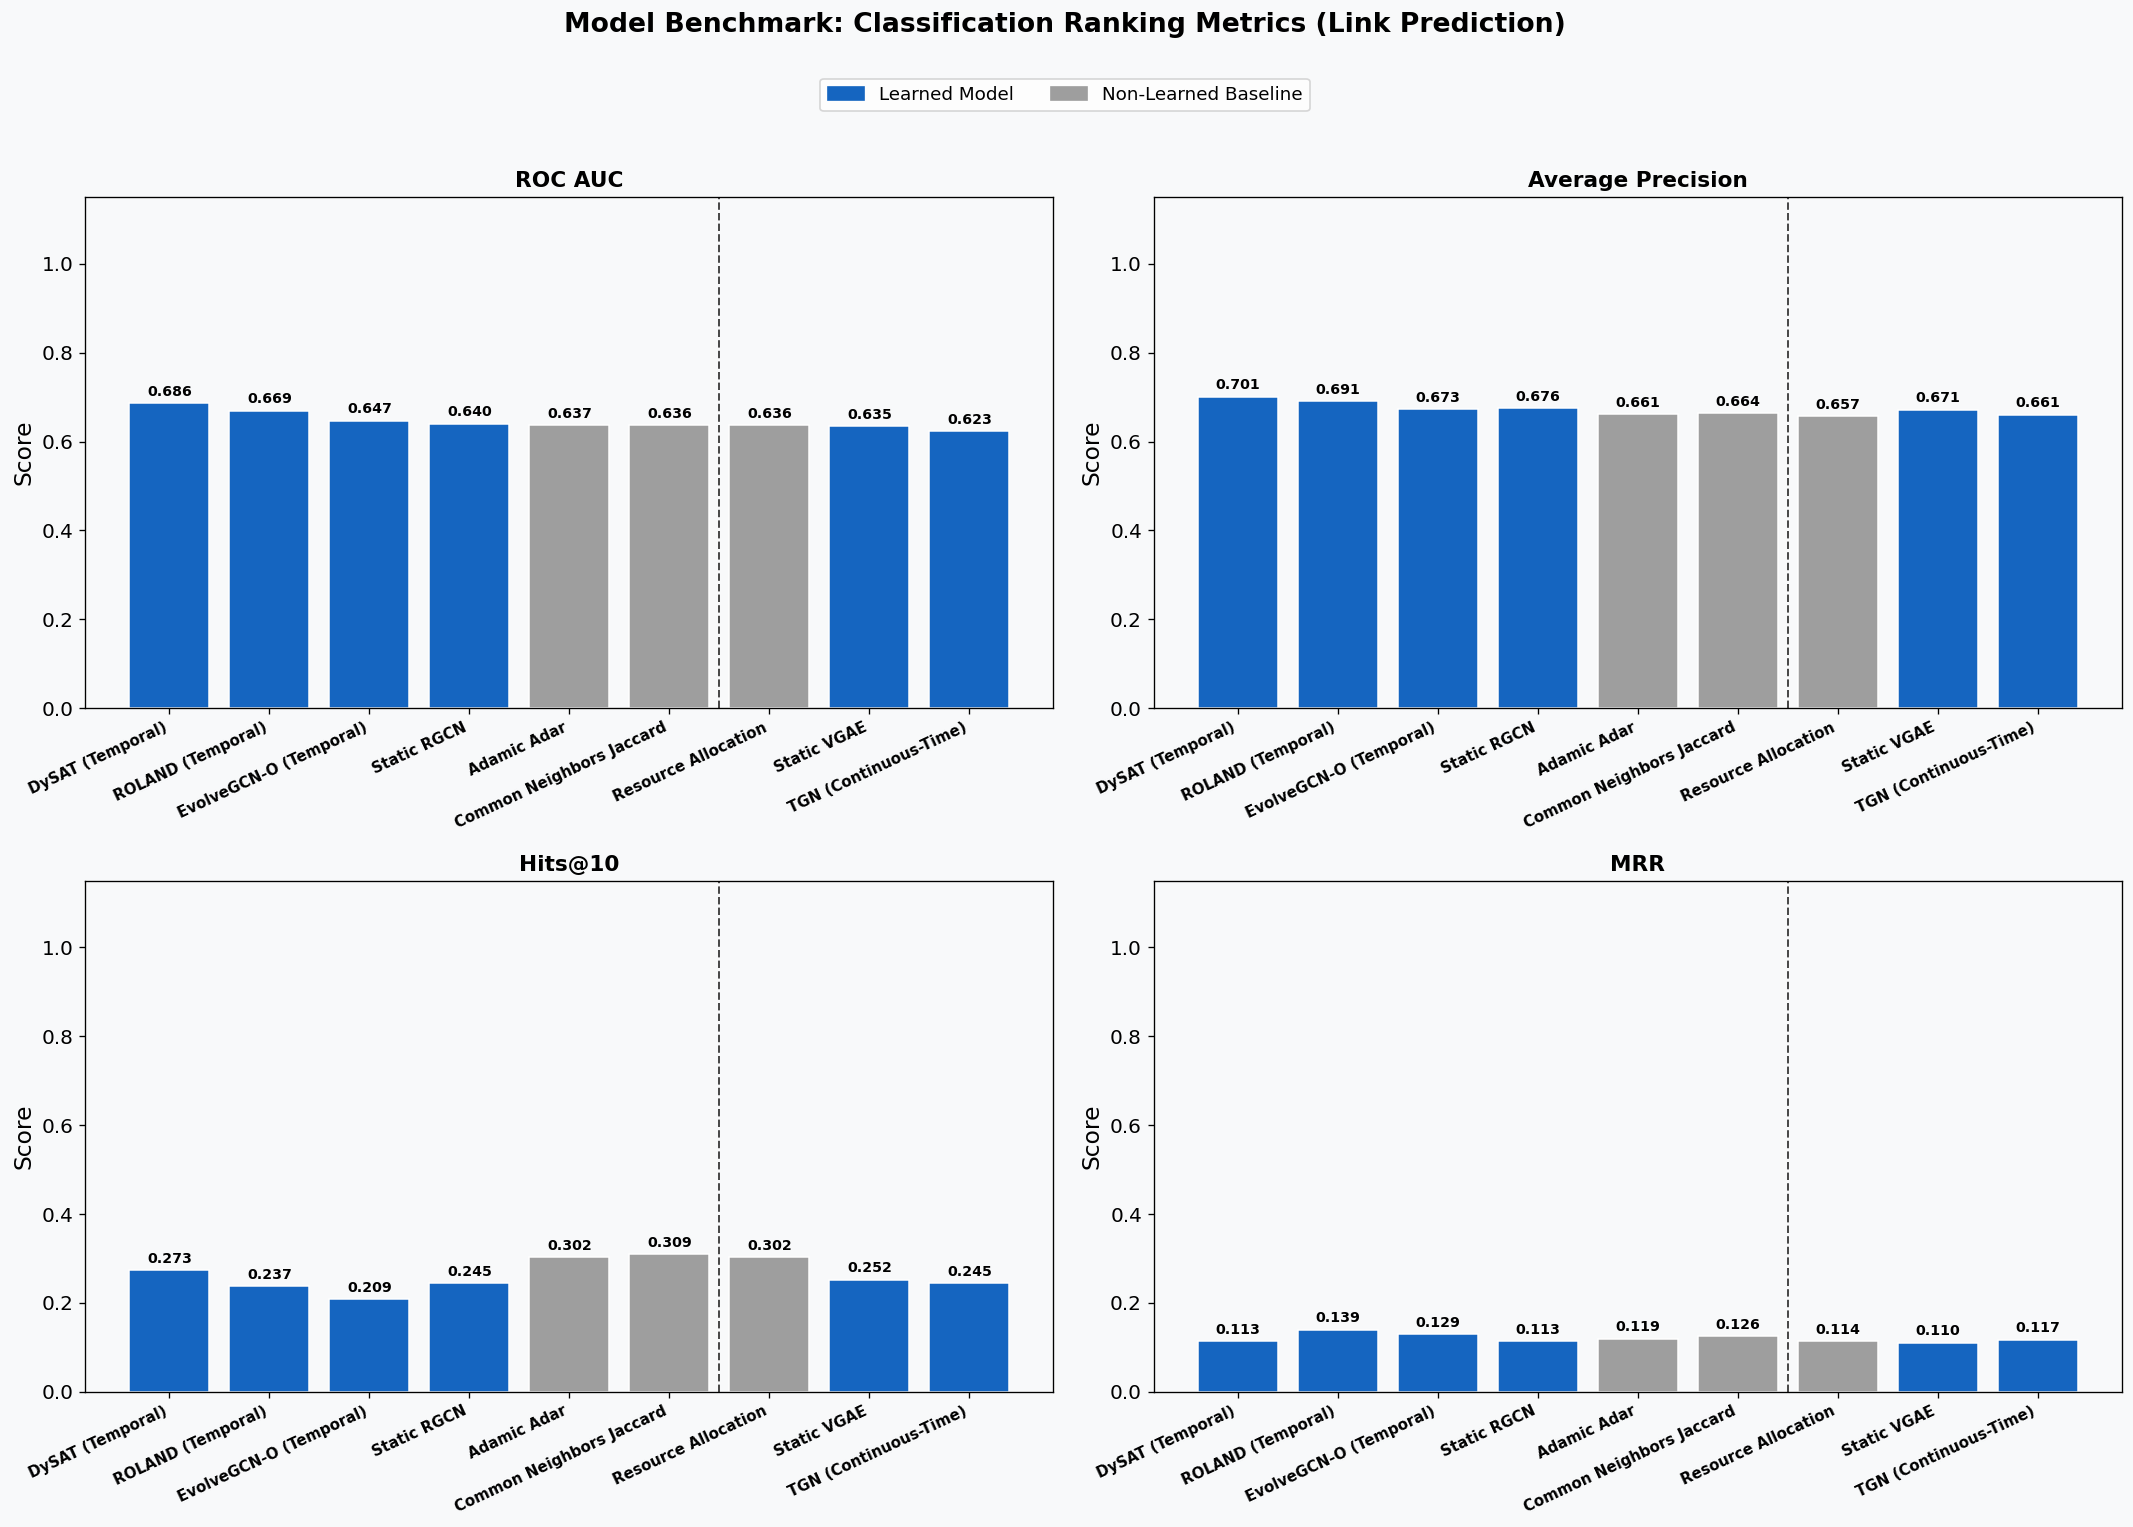

In [ ]:
models_ordered = model_comparison_df["model"].tolist()
bar_colors = ["#1565C0" if c == "Learned Model" else "#9E9E9E" for c in model_comparison_df["category"]]
x = np.arange(len(models_ordered))

class_metrics_panels = [
    ("auc", "ROC AUC"), ("average_precision", "Average Precision"),
    ("hits_at_10", "Hits@10"), ("mrr", "MRR"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor("#F8F9FA")
for ax, (col, title) in zip(axes.flat, class_metrics_panels):
    vals = model_comparison_df[col].tolist()
    bars = ax.bar(x, vals, color=bar_colors, edgecolor="white", linewidth=0.9)
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
    ax.axvline(n_learned - 0.5, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.set_facecolor("#F8F9FA")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models_ordered, rotation=25, ha="right", fontsize=9, fontweight="bold")
    ax.set_ylim(0.0, 1.15)
    ax.set_ylabel("Score")

legend_handles = [
    mpatches.Patch(color="#1565C0", label="Learned Model"),
    mpatches.Patch(color="#9E9E9E", label="Non-Learned Baseline"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Model Benchmark: Classification Ranking Metrics (Link Prediction)", fontsize=16, fontweight="bold", y=1.06)
plt.tight_layout()
p_img1 = os.path.join(OUTPUT_VIZ, "classification_ranking_metrics_bar.png")
plt.savefig(p_img1, dpi=300, bbox_inches="tight")
register_artifact(p_img1, "2x2 grid of classification ranking metrics compared per model, grouped by learned vs non-learned")
plt.show()
plt.close(fig)

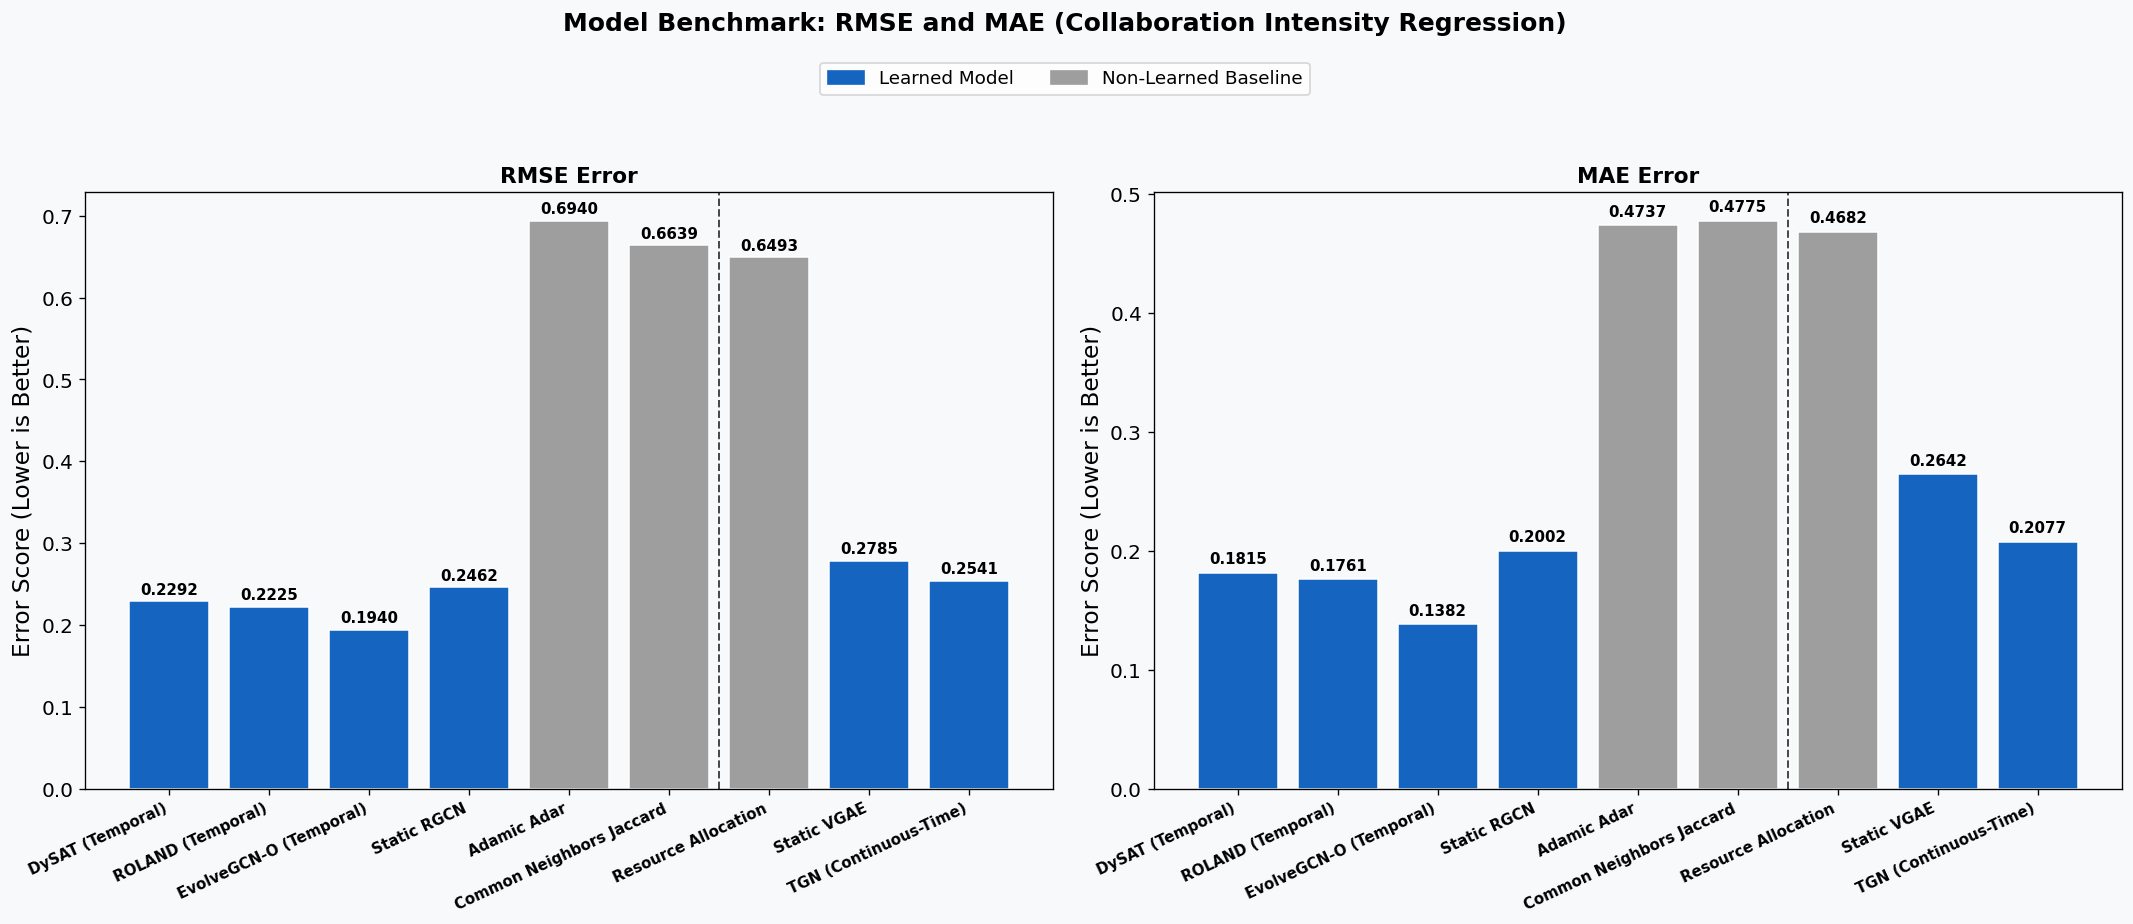

In [ ]:
reg_metrics_panels = [("rmse", "RMSE Error"), ("mae", "MAE Error")]
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#F8F9FA")
for ax, (col, title) in zip(axes, reg_metrics_panels):
    vals = model_comparison_df[col].tolist()
    bars = ax.bar(x, vals, color=bar_colors, edgecolor="white", linewidth=0.9)
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.axvline(n_learned - 0.5, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
    ax.set_facecolor("#F8F9FA")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models_ordered, rotation=25, ha="right", fontsize=9, fontweight="bold")
    ax.set_ylabel("Error Score (Lower is Better)")

fig.legend(handles=legend_handles, loc="upper center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("Model Benchmark: RMSE and MAE (Collaboration Intensity Regression)", fontsize=15, fontweight="bold", y=1.1)
plt.tight_layout()
p_img2 = os.path.join(OUTPUT_VIZ, "regression_error_metrics_bar.png")
plt.savefig(p_img2, dpi=300, bbox_inches="tight")
register_artifact(p_img2, "RMSE and MAE regression error metrics, one panel per metric")
plt.show()
plt.close(fig)

                    model         subset      auc
 Common Neighbors Jaccard     cold start 0.342857
 Common Neighbors Jaccard non cold start 0.895820
              Adamic Adar     cold start 0.342857
              Adamic Adar non cold start 0.898551
      Resource Allocation     cold start 0.342857
      Resource Allocation non cold start 0.898656
              Static VGAE     cold start 0.351429
              Static VGAE non cold start 0.872086
Static Heterogeneous RGCN     cold start 0.401633
Static Heterogeneous RGCN non cold start 0.836799
   EvolveGCN-O (Temporal)     cold start 0.462041
   EvolveGCN-O (Temporal) non cold start 0.813064
        ROLAND (Temporal)     cold start 0.501837
        ROLAND (Temporal) non cold start 0.821466
    TGN (Continuous-Time)     cold start 0.432041
    TGN (Continuous-Time) non cold start 0.796471
         DySAT (Temporal)     cold start 0.511224
         DySAT (Temporal) non cold start 0.855493


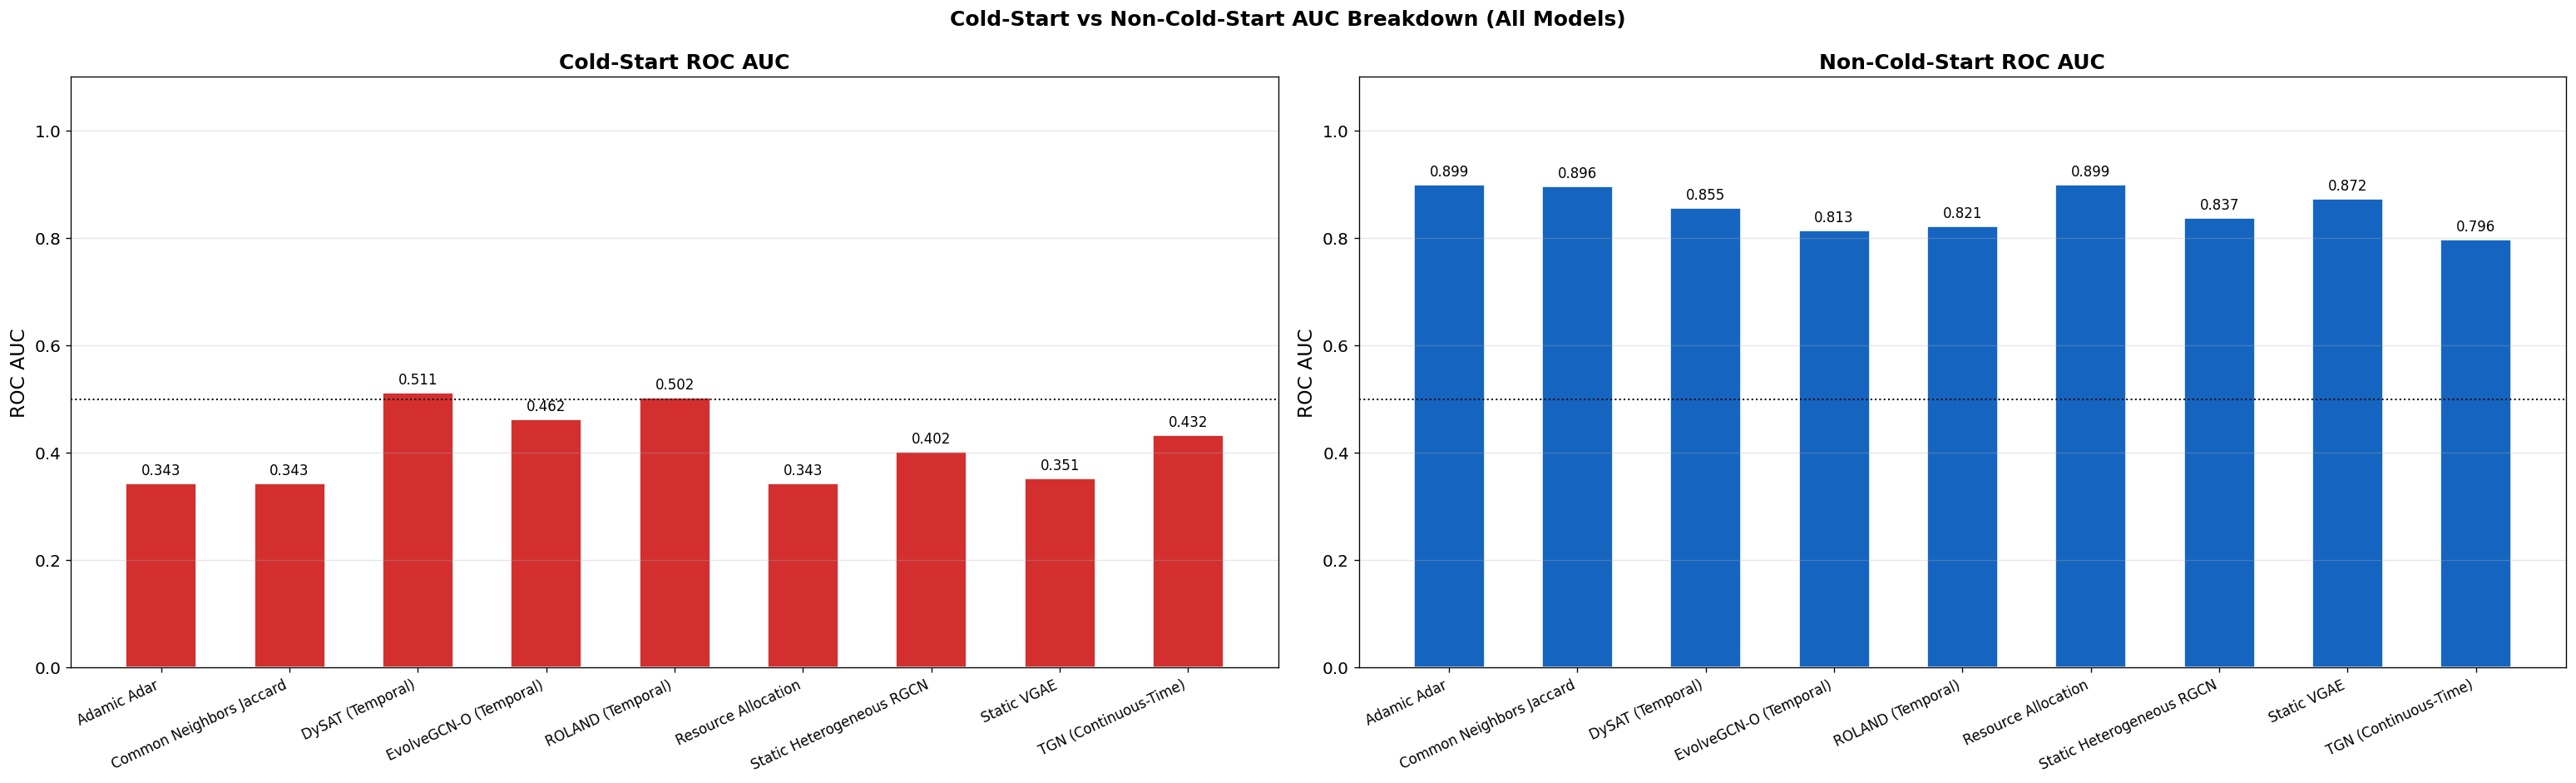

In [ ]:
cold_start_pos_test = [p for p in test_pos_list if not has_common_neighbor(nx_train_graph, p[0], p[1])]
non_cold_start_pos_test = [p for p in test_pos_list if has_common_neighbor(nx_train_graph, p[0], p[1])]
cold_neg = test_neg[:max(len(cold_start_pos_test), 1)]
non_cold_neg = test_neg[:max(len(non_cold_start_pos_test), 1)]

model.eval(); vgae.eval(); rgcn.eval(); evolvegcn.eval()
roland_obj = roland_result["model_obj"]
tgn_obj_cold = tgn_result["model_obj"]
roland_obj.eval(); tgn_obj_cold.eval()
with torch.no_grad():
    embs_cold = model(snapshot_list)[:, -1, :]
    z_vgae_cold, _, _ = vgae.encode(static_x, static_ei)
    z_rgcn_cold = rgcn(static_x_hetero, static_edge_index_hetero, static_edge_type_hetero, N_AUTHORS)
    z_evo_cold = evolvegcn(snapshot_list)[:, -1, :]

def pair_idx_tensor(pairs):
    return torch.tensor([[author_id_to_index[a], author_id_to_index[b]] for a, b in pairs], dtype=torch.long).to(DEVICE)

scorer_map = [
    ("Common Neighbors Jaccard", lambda pairs: score_pairs_jaccard(nx_train_graph, pairs)),
    ("Adamic Adar", lambda pairs: score_pairs_adamic_adar(nx_train_graph, pairs)),
    ("Resource Allocation", lambda pairs: score_pairs_resource_allocation(nx_train_graph, pairs)),
    ("Static VGAE", lambda pairs: [float(v) for v in vgae.decode(z_vgae_cold, pair_idx_tensor(pairs), nx_train_graph, last_wd_static["author_features"].numpy())[0].detach().cpu().numpy()]),
    ("Static Heterogeneous RGCN", lambda pairs: [float(v) for v in rgcn.decode(z_rgcn_cold, pair_idx_tensor(pairs), nx_train_graph, last_wd["author_features"].numpy())[0].detach().cpu().numpy()]),
    ("EvolveGCN-O (Temporal)", lambda pairs: [float(v) for v in evolvegcn.predict_pairs(z_evo_cold, pair_idx_tensor(pairs), nx_train_graph, last_wd_static["author_features"].numpy())[0].detach().cpu().numpy()]),
    ("ROLAND (Temporal)", lambda pairs: [float(v) for v in roland_obj.predict_pairs(roland_result["z_final"], pair_idx_tensor(pairs), nx_train_graph, last_wd["author_features"].numpy())[0].detach().cpu().numpy()]),
    ("TGN (Continuous-Time)", lambda pairs: [float(v) for v in tgn_obj_cold.predict_pairs(tgn_result["z_final"], pair_idx_tensor(pairs), nx_train_graph, last_wd["author_features"].numpy())[0].detach().cpu().numpy()]),
    ("DySAT (Temporal)", lambda pairs: [float(v) for v in model.predict_pairs(embs_cold, pair_idx_tensor(pairs), nx_train_graph, last_wd["author_features"].numpy())[0].detach().cpu().numpy()]),
]

cold_breakdown_rows = []
for model_name, scorer in scorer_map:
    for subset_name, pos_s, neg_s in [("cold start", cold_start_pos_test, cold_neg), ("non cold start", non_cold_start_pos_test, non_cold_neg)]:
        if len(pos_s) < 2:
            continue
        with torch.no_grad():
            m = evaluate_link_prediction(scorer(pos_s), scorer(neg_s))
        cold_breakdown_rows.append({"model": model_name, "subset": subset_name, "auc": m["auc"]})

cold_breakdown_df = pd.DataFrame(cold_breakdown_rows)
print(cold_breakdown_df.to_string(index=False))

if not cold_breakdown_df.empty:
    cold_pivot = cold_breakdown_df.pivot(index="model", columns="subset", values="auc").reset_index()
    x_c = np.arange(len(cold_pivot))
    fig, axes = plt.subplots(1, 2, figsize=(26, 8))
    panel_specs = [("cold start", "Cold-Start ROC AUC", "#D32F2F"), ("non cold start", "Non-Cold-Start ROC AUC", "#1565C0")]
    for ax, (col, title, color) in zip(axes, panel_specs):
        if col in cold_pivot.columns:
            bars = ax.bar(x_c, cold_pivot[col], 0.55, color=color, edgecolor="white")
            for b in bars:
                ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=10)
        ax.axhline(0.5, color="black", linestyle=":", linewidth=1.2)
        ax.set_xticks(x_c)
        ax.set_xticklabels(cold_pivot["model"], rotation=25, ha="right", fontsize=10)
        ax.set_ylabel("ROC AUC")
        ax.set_ylim(0, 1.1)
        ax.set_title(title, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
    fig.suptitle("Cold-Start vs Non-Cold-Start AUC Breakdown (All Models)", fontsize=15, fontweight="bold")
    plt.tight_layout()
    p = os.path.join(OUTPUT_VIZ, "cold_start_breakdown.png")
    plt.savefig(p, dpi=300, bbox_inches="tight")
    register_artifact(p, "cold-start vs non-cold-start AUC breakdown per model, all 9 models")
    plt.show()
    plt.close(fig)

del embs_cold, z_vgae_cold, z_rgcn_cold, z_evo_cold
free_memory()

## Bootstrap CI

In [ ]:
def bootstrap_auc_ci(pos_scores, neg_scores, n_boot=2000, seed=RANDOM_SEED):
    rng_b = np.random.default_rng(seed)
    pos_scores, neg_scores = np.array(pos_scores), np.array(neg_scores)
    boot_aucs = []
    for _ in range(n_boot):
        p_s = pos_scores[rng_b.integers(0, len(pos_scores), len(pos_scores))]
        n_s = neg_scores[rng_b.integers(0, len(neg_scores), len(neg_scores))]
        y = [1]*len(p_s) + [0]*len(n_s)
        s = list(p_s) + list(n_s)
        boot_aucs.append(roc_auc_score(y, s))
    boot_aucs = np.array(boot_aucs)
    return float(np.mean(boot_aucs)), float(np.percentile(boot_aucs, 2.5)), float(np.percentile(boot_aucs, 97.5))

def paired_bootstrap_test(pos_a, neg_a, pos_b, neg_b, n_boot=2000, seed=RANDOM_SEED):
    rng_b = np.random.default_rng(seed)
    pos_a, neg_a, pos_b, neg_b = map(np.array, [pos_a, neg_a, pos_b, neg_b])
    diffs = []
    n_pos, n_neg = len(pos_a), len(neg_a)
    for _ in range(n_boot):
        idx_pos = rng_b.integers(0, n_pos, n_pos)
        idx_neg = rng_b.integers(0, n_neg, n_neg)
        y = [1]*n_pos + [0]*n_neg
        auc_a = roc_auc_score(y, list(pos_a[idx_pos]) + list(neg_a[idx_neg]))
        auc_b = roc_auc_score(y, list(pos_b[idx_pos]) + list(neg_b[idx_neg]))
        diffs.append(auc_a - auc_b)
    diffs = np.array(diffs)
    p_value = float(2 * min((diffs > 0).mean(), (diffs < 0).mean()))
    return float(diffs.mean()), p_value

n_test_pos = len(test_pos_list)
score_lookup = {
    "Common Neighbors Jaccard": (jaccard_test_scores[:n_test_pos], jaccard_test_scores[n_test_pos:]),
    "Static VGAE": (vgae_scores[:n_test_pos], vgae_scores[n_test_pos:]),
    "Static RGCN": (rgcn_scores[:n_test_pos], rgcn_scores[n_test_pos:]),
    "EvolveGCN-O (Temporal)": (evolvegcn_scores[:n_test_pos], evolvegcn_scores[n_test_pos:]),
    "ROLAND (Temporal)": (roland_scores[:n_test_pos], roland_scores[n_test_pos:]),
    "TGN (Continuous-Time)": (tgn_scores[:n_test_pos], tgn_scores[n_test_pos:]),
    "DySAT (Temporal)": (test_probs_np[:n_test_pos], test_probs_np[n_test_pos:]),
}

ci_rows = []
for name, (p_s, n_s) in score_lookup.items():
    mean_auc, lo, hi = bootstrap_auc_ci(p_s, n_s)
    ci_rows.append({"model": name, "auc_mean": mean_auc, "ci_95_low": lo, "ci_95_high": hi})
ci_df = pd.DataFrame(ci_rows).sort_values("auc_mean", ascending=False).reset_index(drop=True)
print("Bootstrap 95% CI untuk AUC (n_boot=2000):")
print(ci_df.to_string(index=False))

d_pos, d_neg = score_lookup["DySAT (Temporal)"]
pair_rows = []
for name, (o_pos, o_neg) in score_lookup.items():
    if name == "DySAT (Temporal)":
        continue
    mean_diff, p_val = paired_bootstrap_test(d_pos, d_neg, o_pos, o_neg)
    pair_rows.append({
        "comparator": name,
        "mean_auc_diff_dysat_minus_comparator": mean_diff,
        "p_value": p_val,
        "significant_at_0.05": bool(p_val < 0.05),
    })
pair_df = pd.DataFrame(pair_rows).sort_values("p_value").reset_index(drop=True)
print("\nPaired bootstrap: DySAT vs setiap pembanding (n=%d positif / %d negatif):" % (len(test_pos_list), len(test_neg)))
print(pair_df.to_string(index=False))

p = os.path.join(OUTPUT_ROOT, "auc_bootstrap_ci_significance.csv")
ci_df.to_csv(p, index=False)
register_artifact(p, "bootstrap 95% CI AUC per model including ROLAND and TGN")
p = os.path.join(OUTPUT_ROOT, "auc_paired_bootstrap_vs_dysat.csv")
pair_df.to_csv(p, index=False)
register_artifact(p, "paired bootstrap test of DySAT against every other model")

Bootstrap 95% CI untuk AUC (n_boot=2000):
                   model  auc_mean  ci_95_low  ci_95_high
        DySAT (Temporal)  0.686399   0.619374    0.746963
       ROLAND (Temporal)  0.669578   0.604042    0.730966
  EvolveGCN-O (Temporal)  0.647384   0.579307    0.713060
             Static RGCN  0.639630   0.571798    0.702303
Common Neighbors Jaccard  0.636842   0.580160    0.694194
             Static VGAE  0.635316   0.569481    0.702147
   TGN (Continuous-Time)  0.622795   0.556580    0.685787

Paired bootstrap: DySAT vs setiap pembanding (n=139 positif / 139 negatif):
              comparator  mean_auc_diff_dysat_minus_comparator  p_value  significant_at_0.05
             Static RGCN                              0.046770    0.006                 True
   TGN (Continuous-Time)                              0.063604    0.009                 True
             Static VGAE                              0.051084    0.025                 True
  EvolveGCN-O (Temporal)                     

## Multi-Seed Temporal Benchmark and Training-Efficiency Profile

The four temporal GNN architectures (EvolveGCN-O, DySAT, ROLAND, TGN) are evaluated across three independent random seeds (42, 123, 2026) under a unified training and early stopping protocol.

Following the three core evaluation dimensions established in the survey paper (*Feng et al., IEEE TKDE 2026*):
1. **Predictive Accuracy & Convergence**: Mean and standard deviation of ROC AUC, AP, Hits@10, MRR, RMSE, and MAE.
2. **Computational Efficiency**: Training runtime per epoch and time-to-convergence under Cosine Annealing learning rate schedules.
3. **Hardware Scalability**: Peak GPU VRAM allocated during backpropagation and total trainable parameter footprint.


In [ ]:
TEMPORAL_REGISTRY = {
    "EvolveGCN-O (Temporal)": ("snapshot", lambda: EvolveGCNTemporal(in_dim=IN_DIM, hidden_dim=128, num_relations=NUM_HETERO_RELATIONS)),
    "DySAT (Temporal)": ("snapshot", lambda: DySATModel(in_dim=IN_DIM, hidden_dim=128, num_relations=NUM_HETERO_RELATIONS, n_spatial_layers=2, n_temporal_heads=4, dropout=0.15)),
    "ROLAND (Temporal)": ("snapshot", lambda: RolandTemporal(in_dim=IN_DIM, hidden_dim=128, num_relations=NUM_HETERO_RELATIONS, n_spatial_layers=2, dropout=0.15)),
    "TGN (Continuous-Time)": ("event", lambda: TGNLinkModel(N_AUTHORS, TGN_MSG_DIM, in_dim=IN_DIM, hidden_dim=TGN_HIDDEN_DIM, time_dim=TGN_TIME_DIM, neighbor_size=TGN_NEIGHBORS, dropout=0.15)),
}

TEMPORAL_SEEDS = list(STABILITY_SEEDS)
cached_runs = {
    ("ROLAND (Temporal)", RANDOM_SEED): roland_result,
    ("TGN (Continuous-Time)", RANDOM_SEED): tgn_result,
}

multiseed_rows = []
multiseed_curves = {}
for model_name, (model_kind, build_fn) in TEMPORAL_REGISTRY.items():
    for seed_val in TEMPORAL_SEEDS:
        run_key = (model_name, seed_val)
        is_cached = run_key in cached_runs
        if is_cached:
            run_res = cached_runs[run_key]
        elif model_kind == "snapshot":
            run_res = run_snapshot_experiment(build_fn, seed_val, model_name)
        else:
            run_res = run_tgn_experiment(build_fn, seed_val, model_name)
        multiseed_rows.append({
            "model": model_name, "seed": seed_val,
            **run_res["class_metrics"], **run_res["reg_metrics"],
            "best_val_auc": run_res["best_val_auc"], "epochs_run": run_res["epochs_run"],
            "train_seconds": run_res["train_seconds"], "sec_per_epoch": run_res["sec_per_epoch"],
            "peak_mem_mb": run_res["peak_mem_mb"], "params": run_res["params"],
        })
        multiseed_curves[run_key] = list(run_res["val_history"])
        row = multiseed_rows[-1]
        print(f"  {model_name:24s} seed={seed_val:<5d} AUC={row['auc']:.4f} AP={row['average_precision']:.4f} "
              f"epochs={row['epochs_run']:<3d} sec/epoch={row['sec_per_epoch']:.3f} peak={row['peak_mem_mb']:.1f}MB")
        if not is_cached:
            run_res.pop("model_obj", None)
            run_res.pop("z_final", None)
        del run_res
        free_memory()

set_global_seed(RANDOM_SEED)

multiseed_df = pd.DataFrame(multiseed_rows)
temporal_summary_df = multiseed_df.groupby("model", sort=False).agg(
    auc_mean=("auc", "mean"), auc_std=("auc", "std"),
    ap_mean=("average_precision", "mean"), ap_std=("average_precision", "std"),
    hits10_mean=("hits_at_10", "mean"), mrr_mean=("mrr", "mean"),
    rmse_mean=("rmse", "mean"), mae_mean=("mae", "mean"),
    epochs_mean=("epochs_run", "mean"), train_s_mean=("train_seconds", "mean"),
    sec_per_epoch_mean=("sec_per_epoch", "mean"), peak_mem_mb_mean=("peak_mem_mb", "mean"),
    params=("params", "first"),
).reset_index().sort_values("auc_mean", ascending=False).reset_index(drop=True)

print("\nMulti-seed temporal benchmark (mean and std over seeds):")
print(temporal_summary_df.round(4).to_string(index=False))

p = os.path.join(OUTPUT_ROOT, "temporal_multiseed_runs.csv")
multiseed_df.to_csv(p, index=False)
register_artifact(p, "per-seed results of EvolveGCN-O, DySAT, ROLAND and TGN under one shared training protocol")
p = os.path.join(OUTPUT_ROOT, "temporal_multiseed_summary.csv")
temporal_summary_df.to_csv(p, index=False)
register_artifact(p, "mean and std over seeds of accuracy, training time per epoch, peak GPU memory and parameters")

  EvolveGCN-O (Temporal)   seed=42    AUC=0.6780 AP=0.6901 epochs=96  sec/epoch=0.122 peak=110.5MB
  EvolveGCN-O (Temporal)   seed=123   AUC=0.6646 AP=0.6887 epochs=81  sec/epoch=0.123 peak=110.5MB
  EvolveGCN-O (Temporal)   seed=2026  AUC=0.6890 AP=0.7158 epochs=71  sec/epoch=0.117 peak=110.5MB
  DySAT (Temporal)         seed=42    AUC=0.6828 AP=0.6962 epochs=88  sec/epoch=0.152 peak=127.3MB
  DySAT (Temporal)         seed=123   AUC=0.7118 AP=0.7118 epochs=111 sec/epoch=0.156 peak=127.3MB
  DySAT (Temporal)         seed=2026  AUC=0.6567 AP=0.6788 epochs=59  sec/epoch=0.134 peak=127.3MB
  ROLAND (Temporal)        seed=42    AUC=0.6690 AP=0.6912 epochs=121 sec/epoch=0.156 peak=132.9MB
  ROLAND (Temporal)        seed=123   AUC=0.6685 AP=0.6941 epochs=76  sec/epoch=0.147 peak=134.4MB
  ROLAND (Temporal)        seed=2026  AUC=0.6569 AP=0.6783 epochs=44  sec/epoch=0.160 peak=134.4MB
  TGN (Continuous-Time)    seed=42    AUC=0.6228 AP=0.6605 epochs=81  sec/epoch=0.325 peak=37.2MB
  TGN (Cont

### Extended Link Prediction Diagnostics

Three complementary diagnostic views evaluate model discrimination on the held-out test split:
1. **ROC Curves**: Evaluates True Positive Rate versus False Positive Rate across all decision thresholds.
2. **Precision-Recall Curves**: Assesses precision retention under high recall constraints.
3. **Rank-Percentile Separation**: Visualizes the empirical distribution of predicted scores converted to percentile ranks, measuring how cleanly positive collaborations are separated from non-collaborating author pairs.


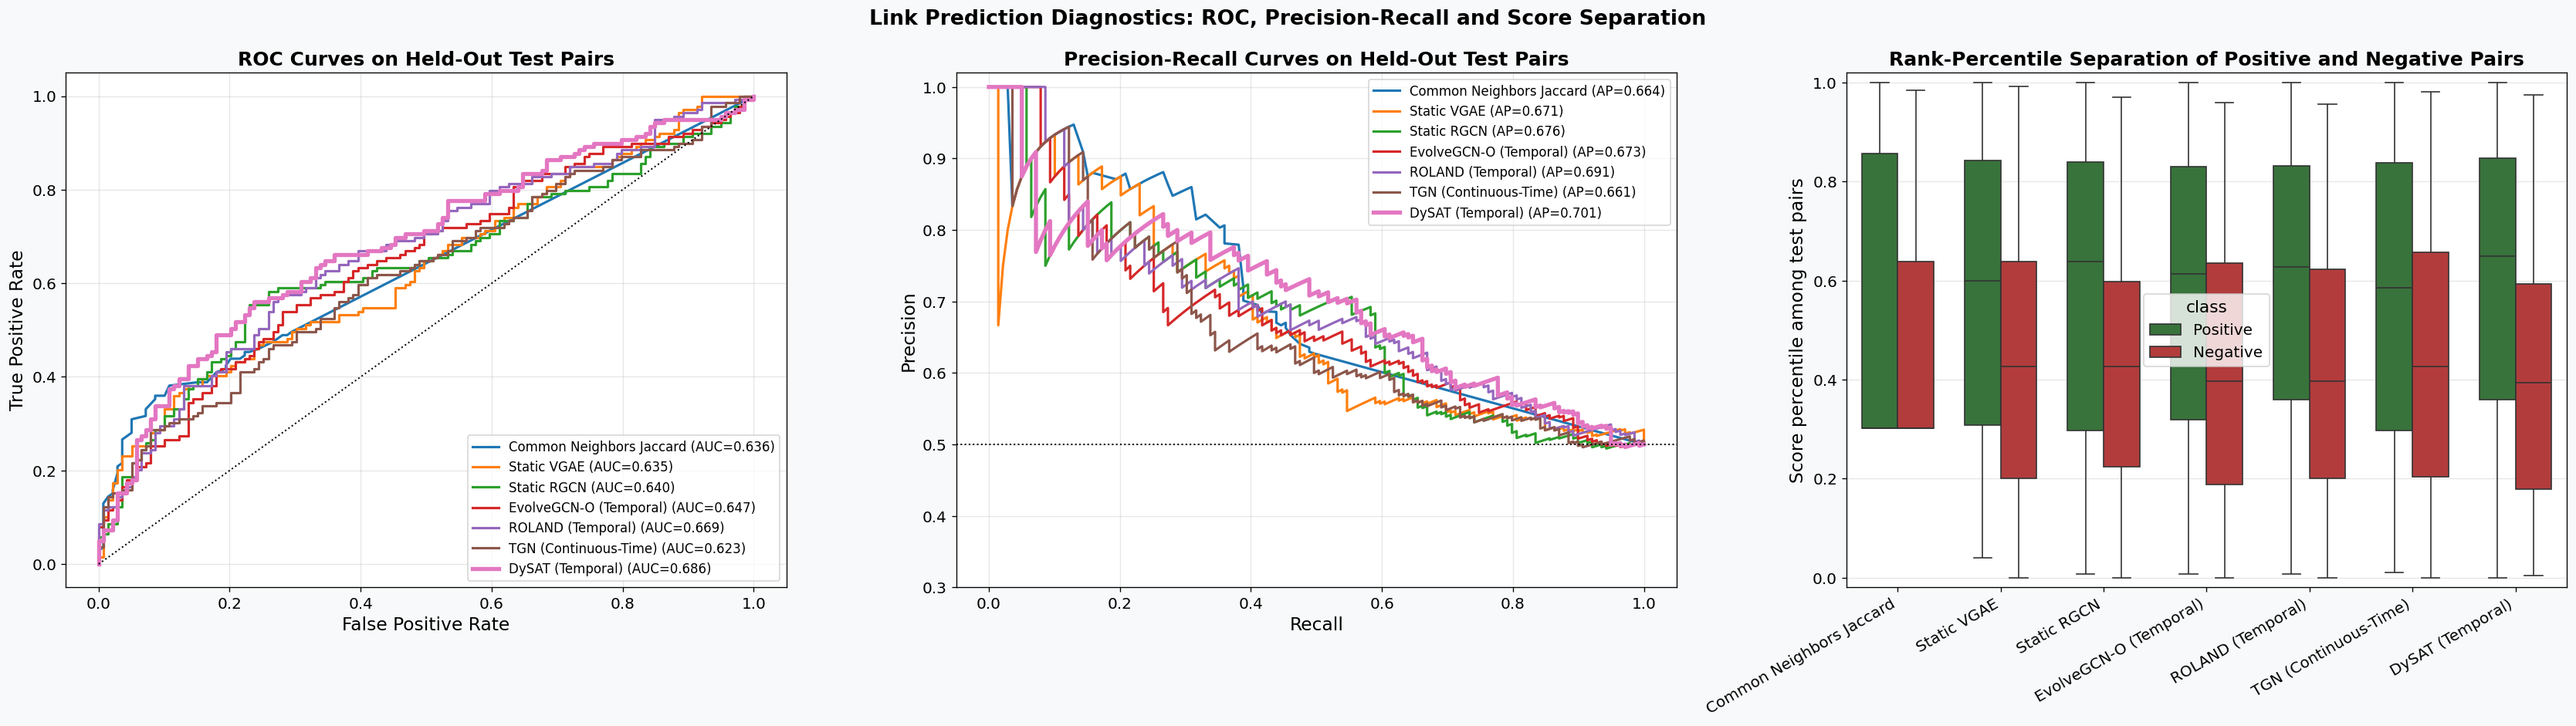

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve
from scipy.stats import rankdata

diag_names = list(score_lookup.keys())
diag_colors = dict(zip(diag_names, plt.cm.tab10(np.linspace(0, 1, 10))[:len(diag_names)]))

fig, axes = plt.subplots(1, 3, figsize=(28, 8))
fig.patch.set_facecolor("#F8F9FA")
rank_frames = []
for name in diag_names:
    pos_s, neg_s = score_lookup[name]
    y_true = np.array([1] * len(pos_s) + [0] * len(neg_s))
    y_score = np.concatenate([np.asarray(pos_s, dtype=float), np.asarray(neg_s, dtype=float)])
    fpr, tpr, _ = roc_curve(y_true, y_score)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    auc_v = roc_auc_score(y_true, y_score)
    ap_v = average_precision_score(y_true, y_score)
    lw = 3.2 if "DySAT" in name else 1.9
    axes[0].plot(fpr, tpr, color=diag_colors[name], linewidth=lw, label=f"{name} (AUC={auc_v:.3f})")
    axes[1].plot(rec, prec, color=diag_colors[name], linewidth=lw, label=f"{name} (AP={ap_v:.3f})")
    pct = (rankdata(y_score, method="average") - 1) / (len(y_score) - 1)
    rank_frames.append(pd.DataFrame({
        "model": name,
        "class": np.where(y_true == 1, "Positive", "Negative"),
        "rank_pct": pct,
    }))

axes[0].plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1.2)
axes[0].set_title("ROC Curves on Held-Out Test Pairs", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=10, loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].axhline(0.5, color="black", linestyle=":", linewidth=1.2)
axes[1].set_title("Precision-Recall Curves on Held-Out Test Pairs", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_ylim(0.3, 1.02)
axes[1].legend(fontsize=10, loc="upper right")
axes[1].grid(alpha=0.3)

rank_df = pd.concat(rank_frames, ignore_index=True)
sns.boxplot(data=rank_df, x="model", y="rank_pct", hue="class",
            palette={"Positive": "#2E7D32", "Negative": "#C62828"}, ax=axes[2], width=0.7, fliersize=2)
axes[2].set_title("Rank-Percentile Separation of Positive and Negative Pairs", fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Score percentile among test pairs")
axes[2].set_ylim(-0.02, 1.02)
axes[2].tick_params(axis="x", rotation=30)
for tick_label in axes[2].get_xticklabels():
    tick_label.set_ha("right")
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("Link Prediction Diagnostics: ROC, Precision-Recall and Score Separation", fontsize=16, fontweight="bold")
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "link_prediction_diagnostics.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "ROC curves, precision-recall curves and rank-percentile separation for all learned models and the best heuristic")
plt.show()
plt.close(fig)
free_memory()

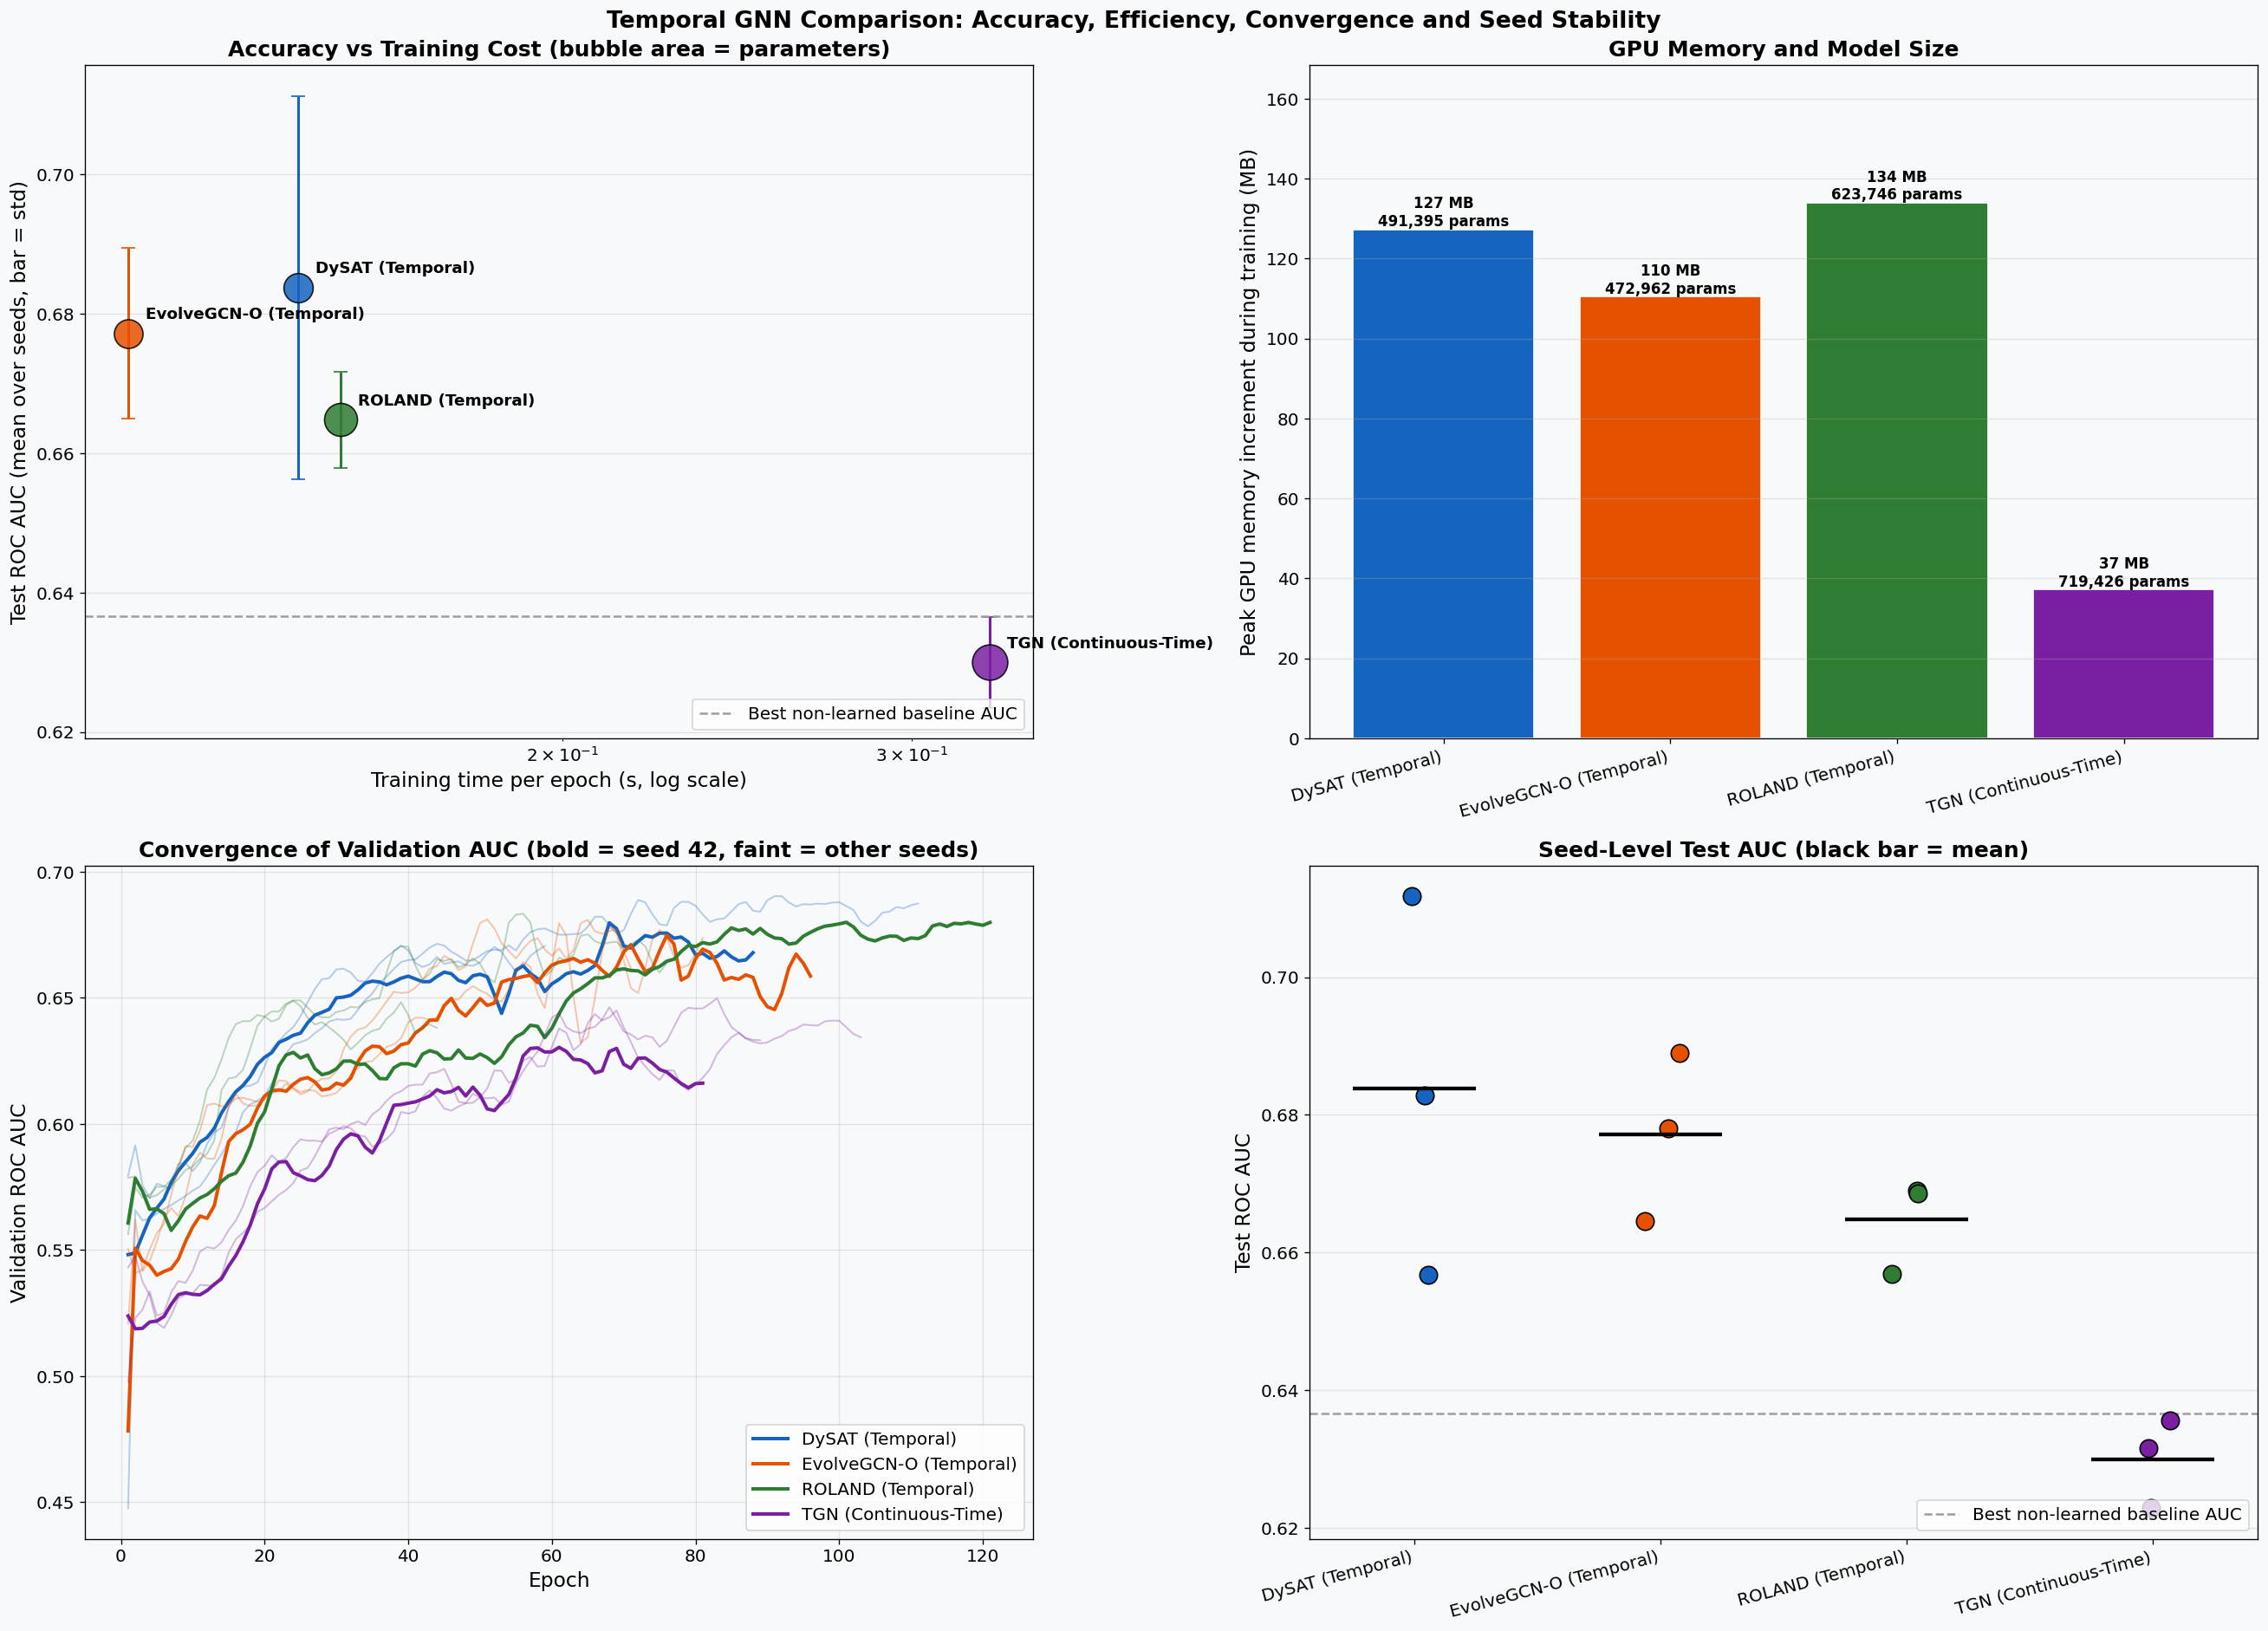

In [ ]:
palette_list = ["#1565C0", "#E65100", "#2E7D32", "#7B1FA2", "#00838F"]
temporal_order = temporal_summary_df["model"].tolist()
temporal_colors = {name: palette_list[i % len(palette_list)] for i, name in enumerate(temporal_order)}
best_heuristic_auc = float(baseline_results_df["auc"].max())

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.patch.set_facecolor("#F8F9FA")

ax = axes[0, 0]
ax.set_facecolor("#F8F9FA")
for _, r in temporal_summary_df.iterrows():
    err = 0.0 if np.isnan(r["auc_std"]) else float(r["auc_std"])
    ax.errorbar(r["sec_per_epoch_mean"], r["auc_mean"], yerr=err, fmt="none", ecolor=temporal_colors[r["model"]], capsize=5, linewidth=1.8)
    ax.scatter(r["sec_per_epoch_mean"], r["auc_mean"], s=float(r["params"]) / 1200.0, color=temporal_colors[r["model"]],
               alpha=0.85, edgecolor="black", linewidth=1.0, zorder=3)
    ax.annotate(r["model"], (r["sec_per_epoch_mean"], r["auc_mean"]), textcoords="offset points", xytext=(12, 10), fontsize=11, fontweight="bold")
ax.axhline(best_heuristic_auc, color="#9E9E9E", linestyle="--", linewidth=1.5, label="Best non-learned baseline AUC")
ax.set_xscale("log")
ax.set_xlabel("Training time per epoch (s, log scale)")
ax.set_ylabel("Test ROC AUC (mean over seeds, bar = std)")
ax.set_title("Accuracy vs Training Cost (bubble area = parameters)", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.set_facecolor("#F8F9FA")
x_b = np.arange(len(temporal_order))
bars = ax.bar(x_b, temporal_summary_df["peak_mem_mb_mean"], color=[temporal_colors[n] for n in temporal_order], edgecolor="white")
for b, params_val in zip(bars, temporal_summary_df["params"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.0f} MB\n{int(params_val):,} params",
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x_b)
ax.set_xticklabels(temporal_order, rotation=15, ha="right")
ax.set_ylabel("Peak GPU memory increment during training (MB)")
ax.set_title("GPU Memory and Model Size", fontweight="bold")
ax.set_ylim(0, float(temporal_summary_df["peak_mem_mb_mean"].max()) * 1.25 + 1)
ax.grid(axis="y", alpha=0.3)

ax = axes[1, 0]
ax.set_facecolor("#F8F9FA")
for name in temporal_order:
    for seed_val in TEMPORAL_SEEDS:
        curve = multiseed_curves[(name, seed_val)]
        is_main = seed_val == RANDOM_SEED
        ax.plot(np.arange(1, len(curve) + 1), curve, color=temporal_colors[name],
                alpha=1.0 if is_main else 0.3, linewidth=2.4 if is_main else 1.2, label=name if is_main else None)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation ROC AUC")
ax.set_title("Convergence of Validation AUC (bold = seed 42, faint = other seeds)", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.set_facecolor("#F8F9FA")
jitter_rng = np.random.default_rng(RANDOM_SEED)
for i, name in enumerate(temporal_order):
    vals = multiseed_df[multiseed_df["model"] == name]["auc"].values
    ax.scatter(i + jitter_rng.uniform(-0.08, 0.08, len(vals)), vals, s=150, color=temporal_colors[name], edgecolor="black", zorder=3)
    ax.hlines(vals.mean(), i - 0.25, i + 0.25, color="black", linewidth=2.6, zorder=4)
ax.axhline(best_heuristic_auc, color="#9E9E9E", linestyle="--", linewidth=1.5, label="Best non-learned baseline AUC")
ax.set_xticks(np.arange(len(temporal_order)))
ax.set_xticklabels(temporal_order, rotation=15, ha="right")
ax.set_ylabel("Test ROC AUC")
ax.set_title("Seed-Level Test AUC (black bar = mean)", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Temporal GNN Comparison: Accuracy, Efficiency, Convergence and Seed Stability", fontsize=16, fontweight="bold")
plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "temporal_efficiency_convergence.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "accuracy versus training cost, GPU memory, convergence and seed stability of the four temporal GNNs")
plt.show()
plt.close(fig)
free_memory()

## Ablation Study Tri-Feature Fusion

Each feature configuration is trained across the same three seeds used in the DySAT Seed
Stability Analysis (42, 123, 2024), with identical architecture, optimizer, and epoch budget.
Reporting mean ± std across seeds, rather than a single run, lets us distinguish a real effect
of removing/adding a feature component from ordinary training-noise variation. A paired
comparison against the full tri-feature configuration (same seeds, so paired by initialization)
is also reported to flag which differences are unlikely to be due to chance alone.

In [ ]:
from scipy import stats

FEATURE_SLICES = {
    "semantic_only (384D)": slice(0, 384),
    "node2vec_only (64D)": slice(384, 448),
    "tstpr_only (2D)": slice(448, 450),
    "semantic+node2vec (448D)": slice(0, 448),
    "full_tri_feature (450D, default)": slice(0, 450),
}
ABLATION_SEEDS = STABILITY_SEEDS
ABLATION_EPOCHS = 60

def zero_out_features(features_tensor, keep_slice):
    masked = torch.zeros_like(features_tensor)
    masked[:, keep_slice] = features_tensor[:, keep_slice]
    return masked

def train_eval_ablation_variant(feat_slice, seed_val, describe=False, variant_name=""):
    torch.manual_seed(seed_val); np.random.seed(seed_val)
    ablation_snapshots = [
        (zero_out_features(wd["x_hetero"], feat_slice), wd["edge_index_hetero"], wd["edge_type_hetero"], wd["edge_index"], wd["edge_attr"], N_AUTHORS)
        for wd in window_data_list
    ]
    abl_model = DySATModel(in_dim=IN_DIM, hidden_dim=128, num_relations=NUM_HETERO_RELATIONS,
                            n_spatial_layers=2, n_temporal_heads=4, dropout=0.15).to(DEVICE)
    if describe:
        describe_model(abl_model, "DySAT (Ablation Variant, identical architecture for every variant)")
    abl_opt = torch.optim.AdamW(abl_model.parameters(), lr=LEARNED_MODEL_LR, weight_decay=LEARNED_MODEL_WEIGHT_DECAY)
    abl_rng = np.random.default_rng(seed_val)

    for ep in range(ABLATION_EPOCHS):
        abl_model.train()
        embs_all = abl_model(ablation_snapshots)
        loss_a = torch.tensor(0.0, device=DEVICE, requires_grad=True)
        n_used = 0
        for t, wd in enumerate(window_data_list[:-1]):
            if not wd["target_pair_dict"]:
                continue
            pi, lt, it = prepare_supervision(wd, wd["target_pair_dict"], abl_rng)
            if pi.shape[0] == 0:
                continue
            lp, ip = abl_model.predict_pairs(embs_all[:, t, :], pi.to(DEVICE), wd["nx_coauthor"], wd["author_features"].numpy())
            loss_a = loss_a + F.binary_cross_entropy(lp.clamp(1e-7, 1-1e-7), lt.to(DEVICE)) + LAMBDA_REG * F.mse_loss(ip, it.to(DEVICE))
            n_used += 1
            del pi, lt, it, lp, ip
        if n_used > 0:
            abl_opt.zero_grad(); loss_a.backward()
            torch.nn.utils.clip_grad_norm_(abl_model.parameters(), 1.0)
            abl_opt.step()
        del embs_all, loss_a

    abl_model.eval()
    with torch.no_grad():
        abl_embs = abl_model(ablation_snapshots)[:, -1, :]
        abl_scores, _ = abl_model.predict_pairs(abl_embs, test_pair_idx.to(DEVICE), nx_train_graph, last_wd["author_features"].numpy())
    abl_scores_np = abl_scores.cpu().numpy()
    metrics = evaluate_link_prediction(abl_scores_np[:len(test_pos_list)], abl_scores_np[len(test_pos_list):])

    del abl_model, abl_opt, ablation_snapshots, abl_embs, abl_scores, abl_scores_np
    free_memory()
    return metrics

ablation_seed_rows = []
for i, (variant_name, feat_slice) in enumerate(FEATURE_SLICES.items()):
    for seed_val in ABLATION_SEEDS:
        m = train_eval_ablation_variant(feat_slice, seed_val, describe=(i == 0 and seed_val == ABLATION_SEEDS[0]), variant_name=variant_name)
        ablation_seed_rows.append({"feature_variant": variant_name, "seed": seed_val, **m})
        print(f"  {variant_name:35s} seed={seed_val:<5d} AUC={m['auc']:.4f} AP={m['average_precision']:.4f}")

ablation_seed_df = pd.DataFrame(ablation_seed_rows)
p_raw = os.path.join(OUTPUT_ROOT, "tri_feature_ablation_per_seed.csv")
ablation_seed_df.to_csv(p_raw, index=False)
register_artifact(p_raw, "ablation study raw per-seed results, 3 seeds per feature variant")

metric_cols = ["auc", "average_precision", "hits_at_10", "mrr"]
agg_funcs = {c: ["mean", "std"] for c in metric_cols}
ablation_df = ablation_seed_df.groupby("feature_variant", sort=False)[metric_cols].agg(["mean", "std"])
ablation_df.columns = [f"{col}_{stat}" for col, stat in ablation_df.columns]
ablation_df = ablation_df.reindex(FEATURE_SLICES.keys()).reset_index()
ablation_df = ablation_df.rename(columns={"index": "feature_variant"})
ablation_df = ablation_df.fillna(0.0)

p = os.path.join(OUTPUT_ROOT, "tri_feature_ablation.csv")
ablation_df.to_csv(p, index=False)
register_artifact(p, "ablation study: mean and std across 3 seeds per feature variant, per classification metric")
print("\nAblation study (mean ± std across seeds):")
print(ablation_df.to_string(index=False))

Arsitektur Model: DySAT (Ablation Variant, identical architecture for every variant)

DySATModel(
  (input_proj): Linear(in_features=452, out_features=128, bias=True)
  (hetero_block): HeteroRelationalBlock(
    (conv): RGCNConv(128, 128, num_relations=3)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.15, inplace=False)
    (proj): Identity()
  )
  (spatial_layers): ModuleList(
    (0-1): 2 x EdgeWeightedGATBlock(
      (conv): GATv2Conv(128, 32, heads=4)
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (proj): Identity()
    )
  )
  (temporal_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (norm_temp): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (norm_final): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): DeepTopoHead(
    (link_mlp): Sequential(
      (0): Linear(in_features=519, out_features=256, bias=True)

### Paired Significance Test vs Full Tri-Feature

For each metric, a paired t-test (paired by seed, since every variant was trained with the same
three seeds) compares each ablated variant against the full tri-feature configuration. This
tells us whether an observed difference is larger than what training-seed noise alone would
produce, rather than relying on a single-run point estimate.

In [ ]:
REFERENCE_VARIANT = "full_tri_feature (450D, default)"
sig_rows = []
for variant_name in FEATURE_SLICES.keys():
    if variant_name == REFERENCE_VARIANT:
        continue
    for col in metric_cols:
        ref_vals = ablation_seed_df[ablation_seed_df["feature_variant"] == REFERENCE_VARIANT].sort_values("seed")[col].values
        var_vals = ablation_seed_df[ablation_seed_df["feature_variant"] == variant_name].sort_values("seed")[col].values
        if len(ref_vals) == len(var_vals) and len(ref_vals) > 1:
            t_stat, p_val = stats.ttest_rel(ref_vals, var_vals)
            mean_diff = float(np.mean(ref_vals - var_vals))
        else:
            t_stat, p_val, mean_diff = float("nan"), float("nan"), float("nan")
        sig_rows.append({
            "variant": variant_name, "metric": col, "mean_diff_vs_full": mean_diff,
            "t_stat": float(t_stat), "p_value": float(p_val),
            "significant_at_0.05": bool(p_val < 0.05) if not np.isnan(p_val) else False,
        })

sig_df = pd.DataFrame(sig_rows)
p_sig = os.path.join(OUTPUT_ROOT, "tri_feature_ablation_significance.csv")
sig_df.to_csv(p_sig, index=False)
register_artifact(p_sig, "paired t-test of each ablated variant against full tri-feature, per metric, paired by seed")
print("Paired significance test vs full_tri_feature (n=3 seeds, indicative only given small n):")
print(sig_df.to_string(index=False))

Paired significance test vs full_tri_feature (n=3 seeds, indicative only given small n):
                 variant            metric  mean_diff_vs_full    t_stat  p_value  significant_at_0.05
    semantic_only (384D)               auc           0.013871  7.561054 0.017046                 True
    semantic_only (384D) average_precision           0.010391  3.198125 0.085429                False
    semantic_only (384D)        hits_at_10          -0.026379 -0.953821 0.440839                False
    semantic_only (384D)               mrr           0.003201  0.325321 0.775819                False
     node2vec_only (64D)               auc           0.147180 17.337139 0.003310                 True
     node2vec_only (64D) average_precision           0.115809 21.796008 0.002098                 True
     node2vec_only (64D)        hits_at_10           0.043165  1.708484 0.229671                False
     node2vec_only (64D)               mrr           0.040923  3.502750 0.072725               

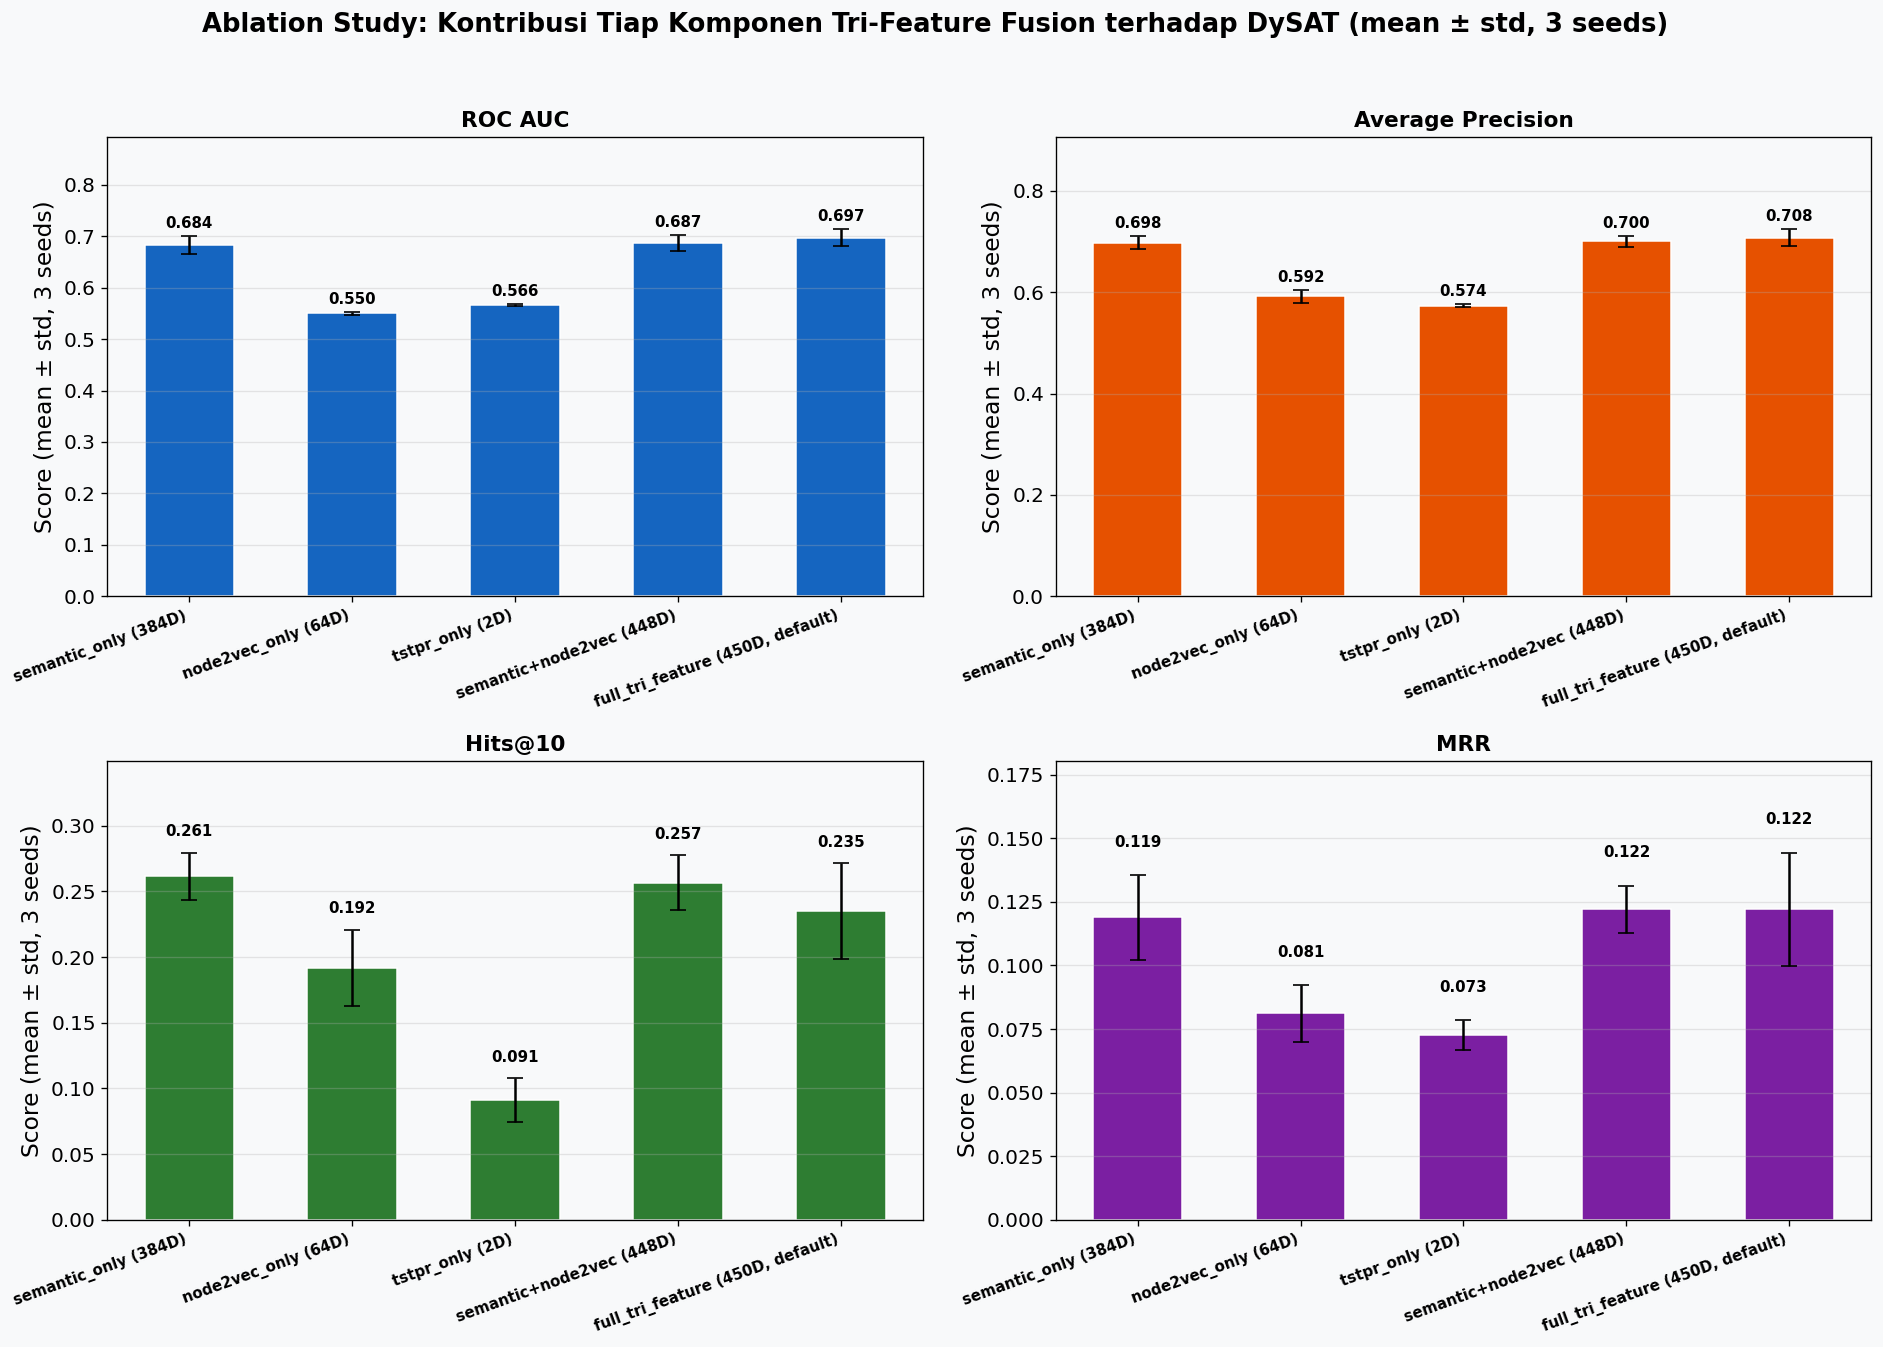

In [ ]:
variants_ordered = ablation_df["feature_variant"].tolist()
x_a = np.arange(len(variants_ordered))

metric_specs = [
    ("auc", "ROC AUC", "#1565C0"), ("average_precision", "Average Precision", "#E65100"),
    ("hits_at_10", "Hits@10", "#2E7D32"), ("mrr", "MRR", "#7B1FA2"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor("#F8F9FA")
for ax, (col, label, color) in zip(axes.flat, metric_specs):
    means = ablation_df[f"{col}_mean"].tolist()
    stds = ablation_df[f"{col}_std"].tolist()
    ax.set_facecolor("#F8F9FA")
    bars = ax.bar(x_a, means, 0.55, yerr=stds, capsize=5, color=color, edgecolor="white", linewidth=0.9,
                   error_kw={"linewidth": 1.5, "ecolor": "black"})
    for bar, s in zip(bars, stds):
        h = bar.get_height()
        if not np.isnan(h) and h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + s + 0.01, f"{h:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xticks(x_a)
    ax.set_xticklabels(variants_ordered, rotation=20, ha="right", fontsize=9, fontweight="bold")
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_ylabel("Score (mean ± std, 3 seeds)")
    top = max(m + s for m, s in zip(means, stds)) if means else 1.0
    ax.set_ylim(0.0, top * 1.25 if top > 0 else 1.0)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Ablation Study: Kontribusi Tiap Komponen Tri-Feature Fusion terhadap DySAT (mean ± std, 3 seeds)",
             fontsize=15.5, fontweight="bold", y=1.02)
plt.tight_layout()
p_abl = os.path.join(OUTPUT_VIZ, "tri_feature_ablation_bar.png")
plt.savefig(p_abl, dpi=300, bbox_inches="tight")
register_artifact(p_abl, "2x2 grid ablation study tri-feature fusion dengan error bar mean±std 3 seeds")
plt.show()
plt.close(fig)

## Results and Interpretation

### Top Models Ranked by Average Rank Across All Metrics

In [ ]:
high_is_better_cols = ["auc", "average_precision", "hits_at_10", "mrr"]
low_is_better_cols = ["rmse", "mae"]

ranked_df = model_comparison_df.copy()
rank_col_names = []

for col in high_is_better_cols:
    if col in ranked_df.columns:
        r_name = col + "_rank"
        ranked_df[r_name] = ranked_df[col].rank(ascending=False)
        rank_col_names.append(r_name)

for col in low_is_better_cols:
    if col in ranked_df.columns:
        r_name = col + "_rank"
        ranked_df[r_name] = ranked_df[col].rank(ascending=True)
        rank_col_names.append(r_name)

ranked_df["average_rank"] = ranked_df[rank_col_names].mean(axis=1)
top_ranked = ranked_df.sort_values("average_rank").reset_index(drop=True)

print("Models Ranked by Average Rank Across All Evaluation Metrics:")
for i, row in top_ranked.iterrows():
    print(f"  Rank {i+1}: {row['model']} (Avg Rank: {row['average_rank']:.2f})")
    print(f"    AUC={row['auc']:.4f} | AP={row['average_precision']:.4f} | Hits@10={row['hits_at_10']:.4f} | MRR={row['mrr']:.4f} | RMSE={row['rmse']:.4f} | MAE={row['mae']:.4f}")

p = os.path.join(OUTPUT_ROOT, "model_rankings_all.csv")
top_ranked.to_csv(p, index=False)
register_artifact(p, "all models ranked by average rank across all evaluation metrics")

Models Ranked by Average Rank Across All Evaluation Metrics:
  Rank 1: ROLAND (Temporal) (Avg Rank: 2.83)
    AUC=0.6690 | AP=0.6912 | Hits@10=0.2374 | MRR=0.1394 | RMSE=0.2225 | MAE=0.1761
  Rank 2: DySAT (Temporal) (Avg Rank: 3.17)
    AUC=0.6860 | AP=0.7008 | Hits@10=0.2734 | MRR=0.1135 | RMSE=0.2292 | MAE=0.1815
  Rank 3: EvolveGCN-O (Temporal) (Avg Rank: 3.33)
    AUC=0.6473 | AP=0.6731 | Hits@10=0.2086 | MRR=0.1291 | RMSE=0.1940 | MAE=0.1382
  Rank 4: Static RGCN (Avg Rank: 4.92)
    AUC=0.6397 | AP=0.6756 | Hits@10=0.2446 | MRR=0.1132 | RMSE=0.2462 | MAE=0.2002
  Rank 5: Common Neighbors Jaccard (Avg Rank: 5.50)
    AUC=0.6365 | AP=0.6639 | Hits@10=0.3094 | MRR=0.1256 | RMSE=0.6639 | MAE=0.4775
  Rank 6: Adamic Adar (Avg Rank: 5.92)
    AUC=0.6367 | AP=0.6610 | Hits@10=0.3022 | MRR=0.1193 | RMSE=0.6940 | MAE=0.4737
  Rank 7: Resource Allocation (Avg Rank: 6.42)
    AUC=0.6363 | AP=0.6574 | Hits@10=0.3022 | MRR=0.1138 | RMSE=0.6493 | MAE=0.4682
  Rank 8: TGN (Continuous-Time) (Av

## Full One-Year-Ahead Collaboration Forecasting

The trained DySAT model generates predictions for all possible author pairs in the target year 2025. Pairs are ranked by predicted link probability to surface the most likely new collaborations and renewed partnerships. Predicted intensity quantifies the expected joint publication count.

In [ ]:
import heapq

model.eval()
with torch.no_grad():
    forecast_embs = model(snapshot_list)[:, -1, :]

n_authors_total = len(all_author_ids_sorted)
total_pairs = n_authors_total * (n_authors_total - 1) // 2
chunk_size = 1000
print(f"scoring {total_pairs:,} author pairs...")

TOP_K_NEW = 200
TOP_K_RENEWED = 100

heap_new = []
heap_renewed = []

pair_generator = itertools.combinations(range(n_authors_total), 2)
pos = 0
while pos < total_pairs:
    batch_idx_pairs = list(itertools.islice(pair_generator, chunk_size))
    if not batch_idx_pairs:
        break
    batch_idx = torch.tensor(batch_idx_pairs, dtype=torch.long)
    with torch.no_grad():
        probs_b, intens_b = model.predict_pairs(forecast_embs, batch_idx.to(DEVICE), nx_train_graph, last_wd["author_features"].numpy())
    probs_np = probs_b.cpu().numpy()
    intens_np = intens_b.cpu().numpy()

    for k, (i_a, i_b) in enumerate(batch_idx_pairs):
        a = all_author_ids_sorted[i_a]
        b = all_author_ids_sorted[i_b]
        prob = float(probs_np[k])
        inten = float(intens_np[k])
        is_existing = (a, b) in train_pair_set
        entry = (prob, a, b, inten, is_existing)
        if is_existing:
            if len(heap_renewed) < TOP_K_RENEWED:
                heapq.heappush(heap_renewed, entry)
            elif prob > heap_renewed[0][0]:
                heapq.heapreplace(heap_renewed, entry)
        else:
            if len(heap_new) < TOP_K_NEW:
                heapq.heappush(heap_new, entry)
            elif prob > heap_new[0][0]:
                heapq.heapreplace(heap_new, entry)

    pos += len(batch_idx_pairs)
    del batch_idx, probs_b, intens_b, probs_np, intens_np
    if pos % (chunk_size * 10) == 0:
        free_memory()

name_map = dict(zip(id_name_lookup_df["author_id"], id_name_lookup_df["display_name"]))

def heap_to_df(heap):
    rows = sorted(heap, key=lambda x: -x[0])
    return pd.DataFrame([{
        "author_a": a, "author_b": b,
        "predicted_probability": prob, "predicted_intensity": inten,
        "is_existing": is_existing,
        "author_a_name": name_map.get(a, a), "author_b_name": name_map.get(b, b),
    } for prob, a, b, inten, is_existing in rows])

new_collab_preds_full = heap_to_df(heap_new)
renewed_preds_full = heap_to_df(heap_renewed)

p = os.path.join(OUTPUT_ROOT, "predicted_collaborations_2025.csv")
pd.concat([new_collab_preds_full, renewed_preds_full], ignore_index=True).to_csv(p, index=False)
register_artifact(p, "top predicted new and renewed collaborations for 2025 (top-k only, memory safe)")
free_memory()

scoring 7,875 author pairs...


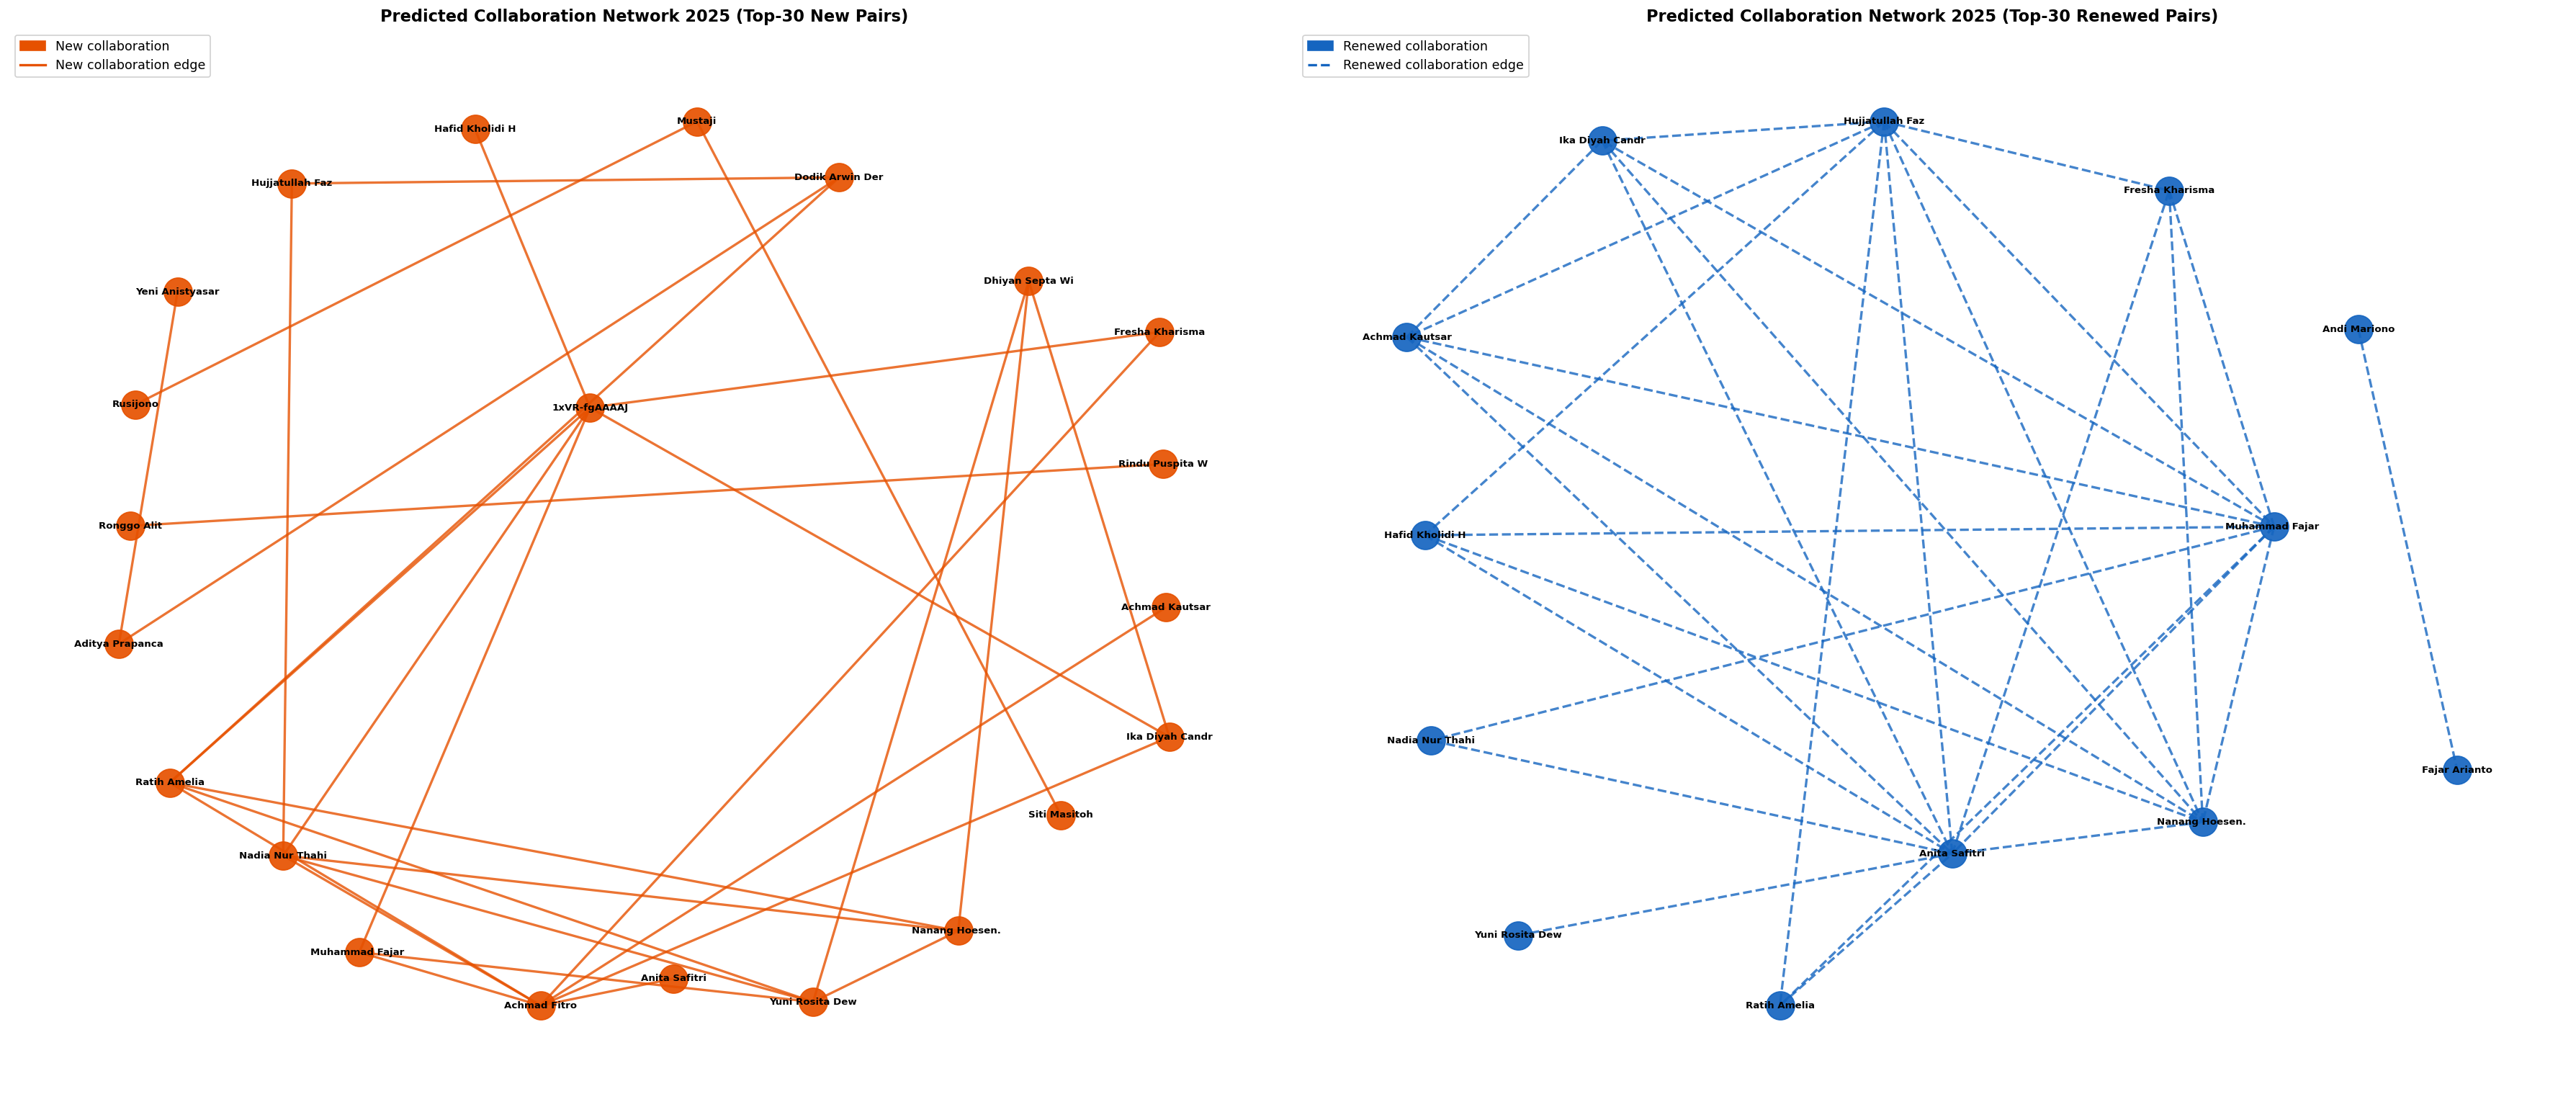

In [ ]:
from plotly.subplots import make_subplots

new_collab_preds = new_collab_preds_full.head(30)
renewed_collab_preds = renewed_preds_full.head(30)

def build_pred_subgraph(preds_df):
    nodes = set()
    for _, r in preds_df.iterrows():
        nodes.add(r["author_a"]); nodes.add(r["author_b"])
    g = nx.Graph()
    g.add_nodes_from(nodes)
    for _, r in preds_df.iterrows():
        val = r["predicted_probability"]
        prob_val = float(val[0]) if isinstance(val, (list, np.ndarray)) else float(val)
        g.add_edge(r["author_a"], r["author_b"], weight=prob_val)
    return g

pred_subgraph_new = build_pred_subgraph(new_collab_preds)
pred_subgraph_renewed = build_pred_subgraph(renewed_collab_preds)

fig, axes = plt.subplots(1, 2, figsize=(30, 13))

panel_specs = [
    (axes[0], pred_subgraph_new, "#E65100", "solid", "New collaboration",
     "Predicted Collaboration Network 2025 (Top-30 New Pairs)"),
    (axes[1], pred_subgraph_renewed, "#1565C0", "dashed", "Renewed collaboration",
     "Predicted Collaboration Network 2025 (Top-30 Renewed Pairs)"),
]

for ax, subgraph, color, style, node_label, title in panel_specs:
    pos_p = nx.spring_layout(subgraph, seed=RANDOM_SEED, k=3.0)
    nx.draw_networkx_edges(subgraph, pos_p, ax=ax, edge_color=color, width=2.0, alpha=0.8, style=style)
    nx.draw_networkx_nodes(subgraph, pos_p, node_color=color, node_size=550, ax=ax, alpha=0.92)
    labels_p = {n: name_map.get(n, n)[:15] for n in subgraph.nodes()}
    nx.draw_networkx_labels(subgraph, pos_p, labels=labels_p, ax=ax, font_size=8, font_weight="bold")
    legend_handles_p = [
        mpatches.Patch(color=color, label=node_label),
        plt.Line2D([0], [0], color=color, lw=2.0, linestyle=style, label=f"{node_label} edge"),
    ]
    ax.legend(handles=legend_handles_p, loc="upper left", fontsize=10.5, framealpha=0.9)
    ax.set_title(title, fontsize=13.5, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
p = os.path.join(OUTPUT_VIZ, "predicted_collaboration_graph_2025.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
register_artifact(p, "predicted collaboration network for 2025, side by side top-30 new pairs and top-30 renewed pairs")
plt.show()
plt.close(fig)

In [ ]:
fig_pred = make_subplots(rows=1, cols=2, subplot_titles=("Top-30 New Pairs", "Top-30 Renewed Pairs"))

interactive_specs = [(pred_subgraph_new, "#E65100", "New collaboration", 1), (pred_subgraph_renewed, "#1565C0", "Renewed collaboration", 2)]
for subgraph, color, label, col_idx in interactive_specs:
    pos_ip = nx.spring_layout(subgraph, seed=RANDOM_SEED, k=3.0)
    edge_x, edge_y = [], []
    for u, v in subgraph.edges():
        x0, y0 = pos_ip[u]; x1, y1 = pos_ip[v]
        edge_x += [x0, x1, None]; edge_y += [y0, y1, None]
    node_x = [pos_ip[n][0] for n in subgraph.nodes()]
    node_y = [pos_ip[n][1] for n in subgraph.nodes()]
    node_names = [name_map.get(n, n) for n in subgraph.nodes()]
    fig_pred.add_trace(go.Scatter(x=edge_x, y=edge_y, mode="lines", line=dict(color="#BDBDBD", width=1.5), hoverinfo="none", name=f"{label} edge", showlegend=False), row=1, col=col_idx)
    fig_pred.add_trace(go.Scatter(x=node_x, y=node_y, mode="markers+text",
        marker=dict(size=16, color=color, opacity=0.9, line=dict(color="white", width=1.5)),
        text=node_names, textposition="top center", textfont=dict(size=9),
        hovertext=[f"{name_map.get(n, n)}<br>{label}" for n in subgraph.nodes()],
        hoverinfo="text", name=label, showlegend=(col_idx == 1)), row=1, col=col_idx)

fig_pred.update_xaxes(showgrid=False, zeroline=False, showticklabels=False)
fig_pred.update_yaxes(showgrid=False, zeroline=False, showticklabels=False)
fig_pred.update_layout(title="Interactive Predicted Collaboration Network 2025: New vs Renewed (hover for details)",
    hovermode="closest", width=1600, height=800)
p = os.path.join(OUTPUT_VIZ, "predicted_collaboration_graph_interactive.html")
fig_pred.write_html(p)
register_artifact(p, "interactive plotly predicted collaboration network 2025, side by side new vs renewed")
fig_pred.show()

### Top Predicted New Collaborations with Author Names

The following table lists the 20 most likely new collaboration pairs that DySAT predicts for 2025, ranked by predicted link probability. Each pair has never co-authored before.

In [ ]:
new_top20 = new_collab_preds_full.head(20)[
    ["author_a_name", "author_b_name", "predicted_probability", "predicted_intensity"]
].reset_index(drop=True)
new_top20.index += 1
new_top20.columns = ["Author A", "Author B", "Link Probability", "Predicted Intensity"]
new_top20["Link Probability"] = new_top20["Link Probability"].round(4)
new_top20["Predicted Intensity"] = new_top20["Predicted Intensity"].round(4)
print("Top 20 Predicted New Collaborations (2025):")
print(new_top20.to_string())
p = os.path.join(OUTPUT_ROOT, "top20_new_collaborations_2025.csv")
new_top20.to_csv(p)
register_artifact(p, "top 20 predicted new collaboration pairs for 2025 with author names and scores")

Top 20 Predicted New Collaborations (2025):
                         Author A                       Author B  Link Probability  Predicted Intensity
1                    Ratih Amelia           Nanang Hoesen. H. A.            0.9806               0.5613
2             Nadia Nur Thahirrah           Nanang Hoesen. H. A.            0.9802               0.5046
3        Hujjatullah Fazlurrahman            Nadia Nur Thahirrah            0.9798               0.5009
4            Nanang Hoesen. H. A.            Dhiyan Septa Wihara            0.9793               0.4910
5            Nanang Hoesen. H. A.               Yuni Rosita Dewi            0.9789               0.4354
6                    Ratih Amelia               Yuni Rosita Dewi            0.9785               0.4643
7         Ika Diyah Candra Arifah            Dhiyan Septa Wihara            0.9783               0.5008
8   Muhammad Fajar Wahyudi Rahman               Yuni Rosita Dewi            0.9780               0.4066
9                   

In [ ]:
renewed_top10 = renewed_preds_full.head(20)[
    ["author_a_name", "author_b_name", "predicted_probability", "predicted_intensity"]
].reset_index(drop=True)
renewed_top10.index += 1
renewed_top10.columns = ["Author A", "Author B", "Link Probability", "Predicted Intensity"]
renewed_top10["Link Probability"] = renewed_top10["Link Probability"].round(4)
renewed_top10["Predicted Intensity"] = renewed_top10["Predicted Intensity"].round(4)
print("Top 10 Predicted Renewals of Existing Collaborations (2025):")
print(renewed_top10.to_string())

Top 10 Predicted Renewals of Existing Collaborations (2025):
                    Author A                       Author B  Link Probability  Predicted Intensity
1   Hujjatullah Fazlurrahman           Nanang Hoesen. H. A.            0.9808               0.5641
2   Hujjatullah Fazlurrahman                  Anita Safitri            0.9808               0.5546
3              Anita Safitri  Muhammad Fajar Wahyudi Rahman            0.9807               0.5926
4               Ratih Amelia                  Anita Safitri            0.9807               0.5863
5    Ika Diyah Candra Arifah                  Anita Safitri            0.9806               0.5856
6               Andi Mariono                  Fajar Arianto            0.9806               0.6931
7            Fresha Kharisma                  Anita Safitri            0.9805               0.5880
8   Hujjatullah Fazlurrahman  Muhammad Fajar Wahyudi Rahman            0.9805               0.5772
9    Ika Diyah Candra Arifah           Nanang Ho

## Final Artifact Export

In [ ]:
model.eval()
with torch.no_grad():
    export_embs_all_windows = model(snapshot_list).cpu().numpy()

embeddings_path = os.path.join(OUTPUT_MODELS, "dysat_author_embeddings_all_windows.npy")
np.save(embeddings_path, export_embs_all_windows)
register_artifact(embeddings_path, "DySAT author embeddings for every sliding window and every author, shape (n_authors, n_windows, hidden_dim), for downstream generative AI use")

rgcn_path = os.path.join(OUTPUT_MODELS, "static_rgcn_model.pt")
torch.save(rgcn.state_dict(), rgcn_path)
register_artifact(rgcn_path, "trained Static Heterogeneous RGCN model state dict")

vgae_path = os.path.join(OUTPUT_MODELS, "static_vgae_model.pt")
torch.save(vgae.state_dict(), vgae_path)
register_artifact(vgae_path, "trained Static VGAE model state dict")

evolvegcn_path = os.path.join(OUTPUT_MODELS, "evolvegcn_model.pt")
torch.save(evolvegcn.state_dict(), evolvegcn_path)
register_artifact(evolvegcn_path, "trained EvolveGCN-O model state dict")

author_index_path = os.path.join(OUTPUT_MODELS, "author_id_to_index.json")
with open(author_index_path, "w") as f:
    json.dump(author_id_to_index, f)
register_artifact(author_index_path, "mapping from author_id to embedding row index, required to align saved embeddings with authors")

author_name_map_path = os.path.join(OUTPUT_MODELS, "author_id_to_name.json")
with open(author_name_map_path, "w") as f:
    json.dump(name_map, f)
register_artifact(author_name_map_path, "mapping from author_id to display name")

model_config = {
    "in_dim": IN_DIM,
    "hidden_dim": 128,
    "num_relations": NUM_HETERO_RELATIONS,
    "n_spatial_layers": 2,
    "n_temporal_heads": 4,
    "dropout": 0.15,
    "lambda_reg": LAMBDA_REG,
    "intensity_cap": int(INTENSITY_CAP),
    "learned_model_epochs": LEARNED_MODEL_EPOCHS,
    "learned_model_lr": LEARNED_MODEL_LR,
    "learned_model_weight_decay": LEARNED_MODEL_WEIGHT_DECAY,
    "sliding_windows": SLIDING_WINDOWS,
    "sentence_transformer_model": "all-MiniLM-L6-v2",
    "n_authors": N_AUTHORS,
    "num_topics": TOPIC_COUNT,
}
model_config_path = os.path.join(OUTPUT_MODELS, "model_config.json")
with open(model_config_path, "w") as f:
    json.dump(model_config, f, indent=2)
register_artifact(model_config_path, "model architecture and training hyperparameters needed to reinstantiate saved models for future generative AI development")

free_memory()

In [ ]:
from google.colab import files
import time

artifact_manifest_df = pd.DataFrame(ARTIFACT_MANIFEST)
manifest_path = os.path.join(OUTPUT_ROOT, "artifact_manifest.csv")
artifact_manifest_df.to_csv(manifest_path, index=False)
print("total artifacts:", len(ARTIFACT_MANIFEST))
print(artifact_manifest_df[["path", "description"]].to_string(index=False))

zip_path = "outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root_dir, dirs, filenames in os.walk(OUTPUT_ROOT):
        for filename in filenames:
            file_path = os.path.join(root_dir, filename)
            arcname = os.path.relpath(file_path, start=os.path.dirname(OUTPUT_ROOT))
            zipf.write(file_path, arcname)

print("compressed archive:", zip_path)

time.sleep(2)
files.download(zip_path)

total artifacts: 48
                                                     path                                                                                                                                   description
                    output/viz/eda_publication_volume.png                                                                                     publication volume per year and document type stacked bar
                         output/viz/eda_top20_authors.png                                                                                       top 20 most prolific authors by total publication count
                  output/viz/eda_edge_volume_temporal.png                                                                                   coauthorship edge volume per year and cumulative edge ratio
                        output/viz/eda_graph_topology.png                                                                 coauthorship graph topology: degree distribution, componen

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>